# <CENTER> **PROJECT - GOOD BOOKS - 10K**
#### <CENTER> ------------------------------------------------------------

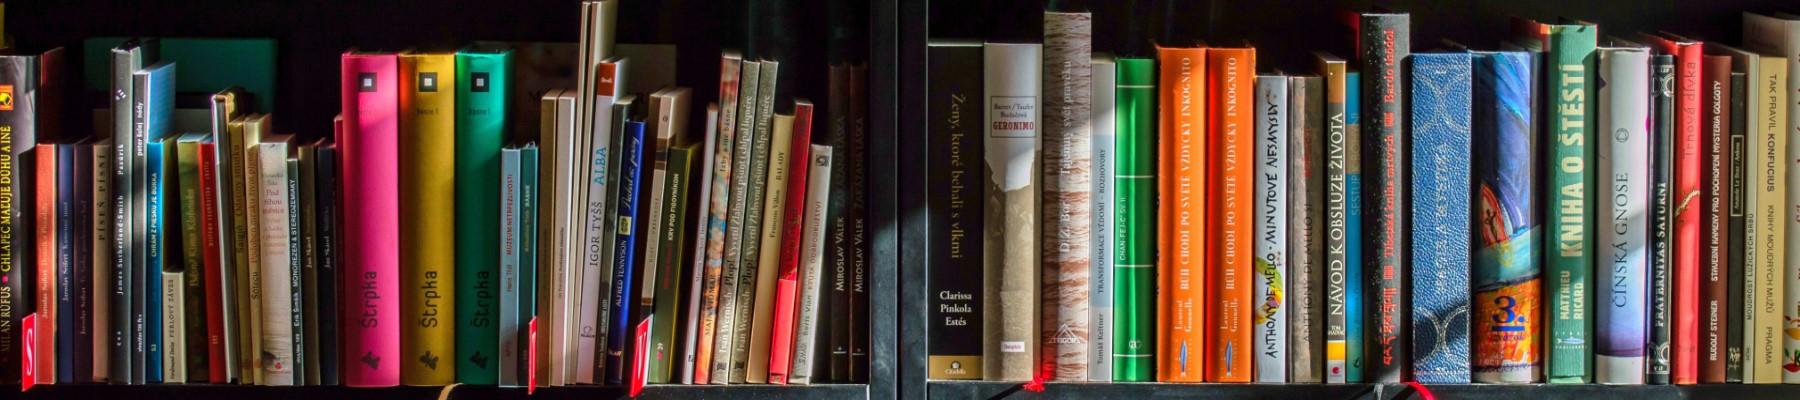

---

#### **Description:**

There have been good datasets for movies (Netflix, Movielens) and music (Million Songs) recommendation, but not for books. That is, until now.

This dataset contains ratings for ten thousand popular books. As to the source, let's say that these ratings were found on the internet. Generally, there are $100$ reviews for each book, although some have less - fewer - ratings. Ratings go from one to five.

Both book IDs and user IDs are contiguous. For books, they are $1-10000$, for users, $1-53424$. All users have made at least two ratings. Median number of ratings per user is $8$.

There are also books marked to read by the users, book metadata (author, year, etc.) and tags.

---


#### **Project goal:** 

1. **Подготовка данных и анализ** — исследовать датасет `Goodbooks-10k`, выявить особенности и проблемы.

2. **Реализация моделей** — последовательно построить бейзлайны: популярные книги, контентная модель (например, с использованием `TF-IDF` для векторизации описаний книг), `Item-based CF` и `SVD`.

3. **Сравнение и выводы** — оценить качество моделей с помощью метрик, сравнить результаты и предложить идеи для улучшения.


---


#### **Stages of work on the project:**

The project will consist of six parts:

`1.` Basic analysis and familiarization with data,

`2.` Базовые и контентные модели,

`3.` Коллаборативная фильтрация (Collaborative Filtering — CF),

`4.` Матричные разложения (Matrix Factorization),

`5.` Оценка и сравнение моделей,

`6.` Гибридизация и выводы.

---

**We import the necessary libraries:**

In [1]:
# Основные библиотеки
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn import neighbors
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr
import torch
import torch.nn as nn
import torch.optim as optim
import itertools
import random


# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nИспользуем устройство: {device}')
print('-' * 28)


# Для визуализации
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt


# Для разбиения данных и построения модели
from sklearn import model_selection
from sklearn import metrics
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split


# Для реализации нейронной сети
import torch
import torch.nn as nn


# Для стандартизации данных
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


Используем устройство: cpu
----------------------------


**Loading data:**

In [2]:
# Loading DataFrames
book_tags_data = pd.read_csv('data/book_tags.csv')
books_data = pd.read_csv('data/books.csv')
ratings_data = pd.read_csv('data/ratings.csv')
tags_data = pd.read_csv('data/tags.csv')
to_read_data = pd.read_csv('data/to_read.csv')


# Creating copies
book_tags_df = book_tags_data.copy()
books_df = books_data.copy()
ratings_df = ratings_data.copy()
tags_df = tags_data.copy()
to_read_df = to_read_data.copy()

=====================================================================================================================================

## <CENTER> **`1.` Basic analysis and familiarization with data**

At this stage, we will study the information provided.

#### $1.1$

#### **Выведем информацию по таблицам.**

Создаём функцию:

In [3]:
# Создадим функцию для вывода информации по датасету
def check_data_inf(data, data_name = None, length1 = None, length2 = None):
    
    # Выводим размеры таблицы
    print()
    print(f'====================| Данные таблицы "{data_name}" имеют следующую размерность: |====================\n')
    print('Количество строк: {};\nКоличество признаков (столбцов): {}.'.format(data.shape[0], data.shape[1]))
    print('-' * length1)

    # Выведем таблицу
    display(data)
    print('-' * length2)

Displaying the result:

In [4]:
# Creating a list with created datas
data_list = [
    book_tags_df,
    books_df,
    ratings_df,
    tags_df,
    to_read_df
]

# Creating a list with data names
data_name_list = [
    'book_tags_df',
    'books_df',
    'ratings_df',
    'tags_df',
    'to_read_df'
]




# Using 'for' cycle for displaying all created datas
for df, name in zip(data_list, data_name_list):
    
    # We're displaying the table information using 'check_data_inf' function
    check_data_inf(
        data = df,
        data_name = name,
        length1 = 40,
        length2 = 100
    )
    print('\n\n\n')


====================| Данные таблицы "book_tags_df" имеют следующую размерность: |====================

Количество строк: 999912;
Количество признаков (столбцов): 3.
----------------------------------------


,goodreads_book_id,tag_id,count
0,1,30574,167697
1,1,11305,37174
2,1,11557,34173
3,1,8717,12986
4,1,33114,12716
...,...,...,...
999907,33288638,21303,7
999908,33288638,17271,7
999909,33288638,1126,7
999910,33288638,11478,7


----------------------------------------------------------------------------------------------------





====================| Данные таблицы "books_df" имеют следующую размерность: |====================

Количество строк: 10000;
Количество признаков (столбцов): 23.
----------------------------------------


,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,7130616,7130616,7392860,19,441019455,9.780441e+12,Ilona Andrews,2010.0,Bayou Moon,...,17204,18856,1180,105,575,3538,7860,6778,https://images.gr-assets.com/books/1307445460m...,https://images.gr-assets.com/books/1307445460s...
9996,9997,208324,208324,1084709,19,067973371X,9.780680e+12,Robert A. Caro,1990.0,Means of Ascent,...,12582,12952,395,303,551,1737,3389,6972,https://s.gr-assets.com/assets/nophoto/book/11...,https://s.gr-assets.com/assets/nophoto/book/50...
9997,9998,77431,77431,2393986,60,039330762X,9.780393e+12,Patrick O'Brian,1977.0,The Mauritius Command,...,9421,10733,374,11,111,1191,4240,5180,https://images.gr-assets.com/books/1455373531m...,https://images.gr-assets.com/books/1455373531s...
9998,9999,8565083,8565083,13433613,7,61711527,9.780062e+12,Peggy Orenstein,2011.0,Cinderella Ate My Daughter: Dispatches from th...,...,11279,11994,1988,275,1002,3765,4577,2375,https://images.gr-assets.com/books/1279214118m...,https://images.gr-assets.com/books/1279214118s...


----------------------------------------------------------------------------------------------------





====================| Данные таблицы "ratings_df" имеют следующую размерность: |====================

Количество строк: 981756;
Количество признаков (столбцов): 3.
----------------------------------------


...

----------------------------------------------------------------------------------------------------





====================| Данные таблицы "tags_df" имеют следующую размерность: |====================

Количество строк: 34252;
Количество признаков (столбцов): 2.
----------------------------------------


,tag_id,tag_name
0,0,-
1,1,--1-
2,2,--10-
3,3,--12-
4,4,--122-
...,...,...
34247,34247,Ｃhildrens
34248,34248,Ｆａｖｏｒｉｔｅｓ
34249,34249,Ｍａｎｇａ
34250,34250,ＳＥＲＩＥＳ


----------------------------------------------------------------------------------------------------





====================| Данные таблицы "to_read_df" имеют следующую размерность: |====================

Количество строк: 912705;
Количество признаков (столбцов): 2.
----------------------------------------


,user_id,book_id
0,1,112
1,1,235
2,1,533
3,1,1198
4,1,1874
...,...,...
912700,53424,4716
912701,53424,4844
912702,53424,5907
912703,53424,7569


----------------------------------------------------------------------------------------------------






#### **File Descriptions and Data Field Information**

##### **Contents**

  * **ratings.csv** contains ratings,

  * **to_read.csv** provides IDs of the books marked "to read" by each user, as **user_id**, **book_id** pairs.

  * **books.csv** has metadata for each book (goodreads IDs, authors, title, average rating, etc.).

  * The metadata have been extracted from goodreads XML files, available in the third version of this dataset as **books_xml.tar.gz**. The archive contains 10000 XML files. One of them is available as **sample_book.xml**. To make the download smaller, these files are absent from the current version. Download version 3 if you want them.

  * **book_tags.csv** contains tags/shelves/genres assigned by users to books. Tags in this file are represented by their IDs.

  * **tags.csv** translates tag IDs to names.

##### **goodreads IDs**

  * Each book may have many editions. **goodreads_book_id** and **best_book_id** generally point to the most popular edition of a given book, while goodreads **work_id** refers to the book in the abstract sense.

---

#### $1.2$

Displaying information based on the features:

In [5]:
# Using 'for' cycle for displaying information about all created datas
for df, name, in zip(data_list, data_name_list):
    
    # information displaying
    print(f'\n==============| Информация датасета "{name}": |==============\n')
    display(df.info())
    print('-' * 60)
    print('\n\n\n')


==============| Информация датасета "book_tags_df": |==============

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999912 entries, 0 to 999911
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   goodreads_book_id  999912 non-null  int64
 1   tag_id             999912 non-null  int64
 2   count              999912 non-null  int64
dtypes: int64(3)
memory usage: 22.9 MB


None

------------------------------------------------------------





==============| Информация датасета "books_df": |==============

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         10000 non-null  int64  
 1   book_id                    10000 non-null  int64  
 2   best_book_id               10000 non-null  int64  
 3   work_id                    10000 non-null  int64  
 4   books_count                10000 non-null  int64  
 5   isbn                       9300 non-null   object 
 6   isbn13                     9415 non-null   float64
 7   authors                    10000 non-null  object 
 8   original_publication_year  9979 non-null   float64
 9   original_title             9415 non-null   object 
 10  title                      10000 non-null  object 
 11  language_code              8

None

------------------------------------------------------------





==============| Информация датасета "ratings_df": |==============

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981756 entries, 0 to 981755
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   book_id  981756 non-null  int64
 1   user_id  981756 non-null  int64
 2   rating   981756 non-null  int64
dtypes: int64(3)
memory usage: 22.5 MB


...

------------------------------------------------------------





==============| Информация датасета "tags_df": |==============

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34252 entries, 0 to 34251
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tag_id    34252 non-null  int64 
 1   tag_name  34252 non-null  object
dtypes: int64(1), object(1)
memory usage: 535.3+ KB


None

------------------------------------------------------------





==============| Информация датасета "to_read_df": |==============

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912705 entries, 0 to 912704
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   user_id  912705 non-null  int64
 1   book_id  912705 non-null  int64
dtypes: int64(2)
memory usage: 13.9 MB


None

------------------------------------------------------------






#### $1.3$

#### **Подсчитаем количество типов данных по признакам.**

Создаём функцию для подсчёта:

In [6]:
# Создаём функцию для рассчёта количества типов по признакам
def check_features_dtypes(data, data_name = None, length1 = None, length2 = None):
    
    # Подсчет количества признаков типа 'object', 'int64' и 'float64'      
    object_columns_count = data.select_dtypes(include = ['object']).shape[1]
    int64_columns_count = data.select_dtypes(include = ['int64']).shape[1]
    float64_columns_count = data.select_dtypes(include = ['float64']).shape[1]
    bool_columns_count = data.select_dtypes(include = ['bool']).shape[1]


    # Вывод результата
    print(f'\n======| В таблице "{data_name}" представлены признаки следующих типов: |======')
    print()

    print(f"Количество признаков типа 'object': {object_columns_count}")
    print(f"Количество признаков типа 'int64': {int64_columns_count}")
    print(f"Количество признаков типа 'float64': {float64_columns_count}")
    print(f"Количество признаков типа 'bool': {bool_columns_count}")
    print('-' * length2)

Выводим результат:

In [7]:
# Пройдёмся циклом 'for' по созданным спискам, и по каждой таблице выведем информацию
for df, name in zip(data_list, data_name_list):
    
    # Вывод информации
    check_features_dtypes(
        data = df,
        data_name = name,
        length1 = 70,
        length2 = 45
    )
    print('\n\n')


======| В таблице "book_tags_df" представлены признаки следующих типов: |======

Количество признаков типа 'object': 0
Количество признаков типа 'int64': 3
Количество признаков типа 'float64': 0
Количество признаков типа 'bool': 0
---------------------------------------------




======| В таблице "books_df" представлены признаки следующих типов: |======

Количество признаков типа 'object': 7
Количество признаков типа 'int64': 13
Количество признаков типа 'float64': 3
Количество признаков типа 'bool': 0
---------------------------------------------




======| В таблице "ratings_df" представлены признаки следующих типов: |======

Количество признаков типа 'object': 0
Количество признаков типа 'int64': 3
Количество признаков типа 'float64': 0
Количество признаков типа 'bool': 0
---------------------------------------------




======| В таблице "tags_df" представлены признаки следующих типов: |======

Количество признаков типа 'object': 1
Количество признаков типа 'int64': 1
Количество

#### $1.4$

Выведем описательные характеристики по признакам:

In [8]:
# Пройдёмся циклом 'for' по созданным спискам, и по каждой таблице выведем информацию
for df, name in zip(data_list, data_name_list):
    
    # Вывод информации
    print(f'\n=========| Описательные характеристики датасета "{name}": |=========\n')
    display(df.describe())
    print('-' * 70)
    print('\n\n')


=========| Описательные характеристики датасета "book_tags_df": |=========



,goodreads_book_id,tag_id,count
count,9.999120e+05,999912.000000,999912.000000
mean,5.263442e+06,16324.527073,208.869633
std,7.574057e+06,9647.846196,3501.265173
min,1.000000e+00,0.000000,-1.000000
25%,4.622700e+04,8067.000000,7.000000
50%,3.948410e+05,15808.000000,15.000000
75%,9.378297e+06,24997.000000,40.000000
max,3.328864e+07,34251.000000,596234.000000


----------------------------------------------------------------------




=========| Описательные характеристики датасета "books_df": |=========



,id,book_id,best_book_id,work_id,books_count,isbn13,original_publication_year,average_rating,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5
count,10000.00000,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,9.415000e+03,9979.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,1.000000e+04
mean,5000.50000,5.264697e+06,5.471214e+06,8.646183e+06,75.712700,9.755044e+12,1981.987674,4.002191,5.400124e+04,5.968732e+04,2919.955300,1345.040600,3110.885000,11475.893800,1.996570e+04,2.378981e+04
std,2886.89568,7.575462e+06,7.827330e+06,1.175106e+07,170.470728,4.428619e+11,152.576665,0.254427,1.573700e+05,1.678038e+05,6124.378132,6635.626263,9717.123578,28546.449183,5.144736e+04,7.976889e+04
min,1.00000,1.000000e+00,1.000000e+00,8.700000e+01,1.000000,1.951703e+08,-1750.000000,2.470000,2.716000e+03,5.510000e+03,3.000000,11.000000,30.000000,323.000000,7.500000e+02,7.540000e+02
25%,2500.75000,4.627575e+04,4.791175e+04,1.008841e+06,23.000000,9.780316e+12,1990.000000,3.850000,1.356875e+04,1.543875e+04,694.000000,196.000000,656.000000,3112.000000,5.405750e+03,5.334000e+03
50%,5000.50000,3.949655e+05,4.251235e+05,2.719524e+06,40.000000,9.780452e+12,2004.000000,4.020000,2.115550e+04,2.383250e+04,1402.000000,391.000000,1163.000000,4894.000000,8.269500e+03,8.836000e+03
75%,7500.25000,9.382225e+06,9.636112e+06,1.451775e+07,67.000000,9.780831e+12,2011.000000,4.180000,4.105350e+04,4.591500e+04,2744.250000,885.000000,2353.250000,9287.000000,1.602350e+04,1.730450e+04
max,10000.00000,3.328864e+07,3.553423e+07,5.639960e+07,3455.000000,9.790008e+12,2017.000000,4.820000,4.780653e+06,4.942365e+06,155254.000000,456191.000000,436802.000000,793319.000000,1.481305e+06,3.011543e+06


----------------------------------------------------------------------




=========| Описательные характеристики датасета "ratings_df": |=========



...

----------------------------------------------------------------------




=========| Описательные характеристики датасета "tags_df": |=========



,tag_id
count,34252.000000
mean,17125.500000
std,9887.845047
min,0.000000
25%,8562.750000
50%,17125.500000
75%,25688.250000
max,34251.000000


----------------------------------------------------------------------




=========| Описательные характеристики датасета "to_read_df": |=========



,user_id,book_id
count,912705.000000,912705.000000
mean,27668.980115,2454.739538
std,14775.096388,2626.359921
min,1.000000,1.000000
25%,15507.000000,360.000000
50%,27799.000000,1381.000000
75%,40220.000000,3843.000000
max,53424.000000,10000.000000


----------------------------------------------------------------------





#### $1.5$

#### **Распределение оценок.**

Посмотрим на распределение оценок, а так же определим смещение в сторону высоких оценок:

In [9]:
# Задаём заголовок
print('\n============| Информация по рейтингам и оценкам |============\n\n')



# Подсчёт распределения оценок
rating_distribution = ratings_df['rating'].value_counts().sort_index()
print(f'\nРаспределение оценок:\n\n{rating_distribution}')
print('-' * 30)
print('\n\n')


# Подсчёт процентного распределения
rating_distribution_percent = (rating_distribution / (rating_distribution.sum() * 100))
print(f'Процентное распределение:\n\n{rating_distribution_percent}')
print('-' * 30)
print('\n\n')


# Подсчёт среднего рейтинга
mean_rating = ratings_df['rating'].mean()
print(f'Средний рейтинг: {mean_rating:.2f}')
print('-' * 25)


============| Информация по рейтингам и оценкам |============



Распределение оценок:

rating
1     19575
2     63231
3    248623
4    357366
5    292961
Name: count, dtype: int64
------------------------------



Процентное распределение:

rating
1    0.000199
2    0.000644
3    0.002532
4    0.003640
5    0.002984
Name: count, dtype: float64
------------------------------



Средний рейтинг: 3.86
-------------------------


Изобразим результаты на столбчатом графике:


==============================================| График распределения оценок |==============================================

---------------------------------------------------------------------------------------------------------------------------


/var/folders/9z/th6zqsk53cbb_rkn6zr5cgzh0000gn/T/ipykernel_1557/3078700402.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/9z/th6zqsk53cbb_rkn6zr5cgzh0000gn/T/ipykernel_1557/3078700402.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize = 15)


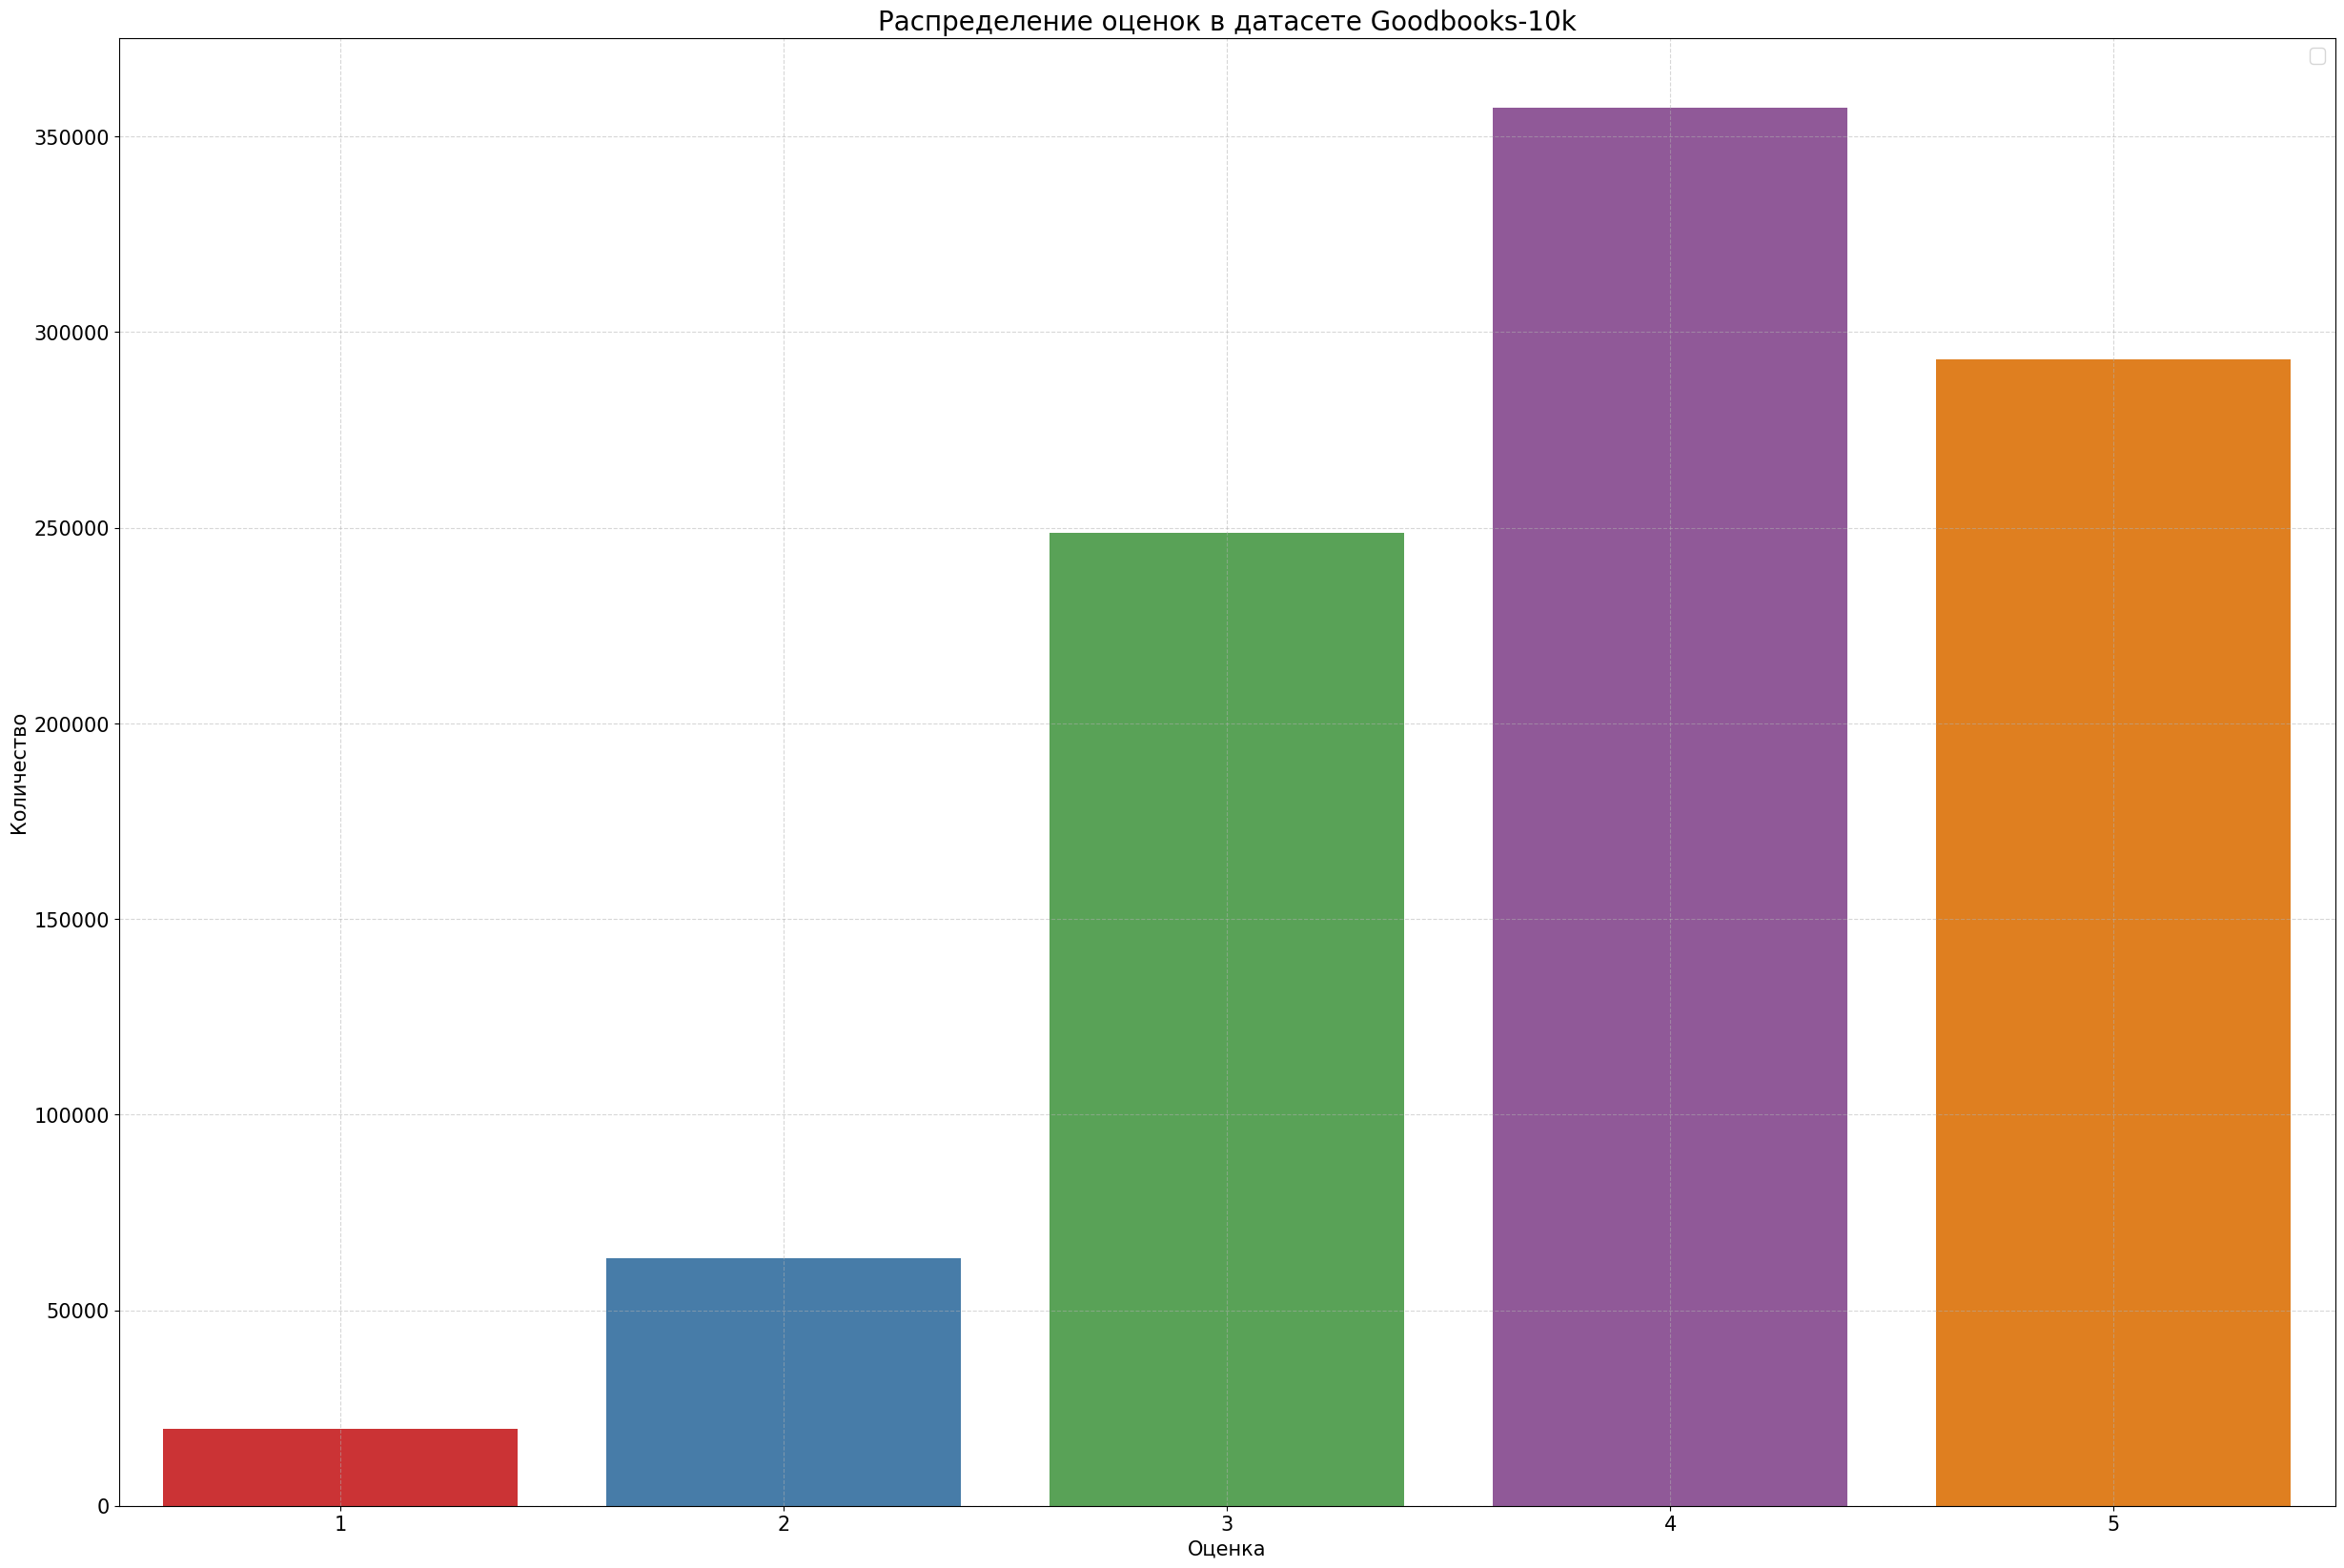

---------------------------------------------------------------------------------------------------------------------------





====================================| График распределения гистограммы с процентами |=====================================

---------------------------------------------------------------------------------------------------------------------------


/var/folders/9z/th6zqsk53cbb_rkn6zr5cgzh0000gn/T/ipykernel_1557/3078700402.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize = 15)


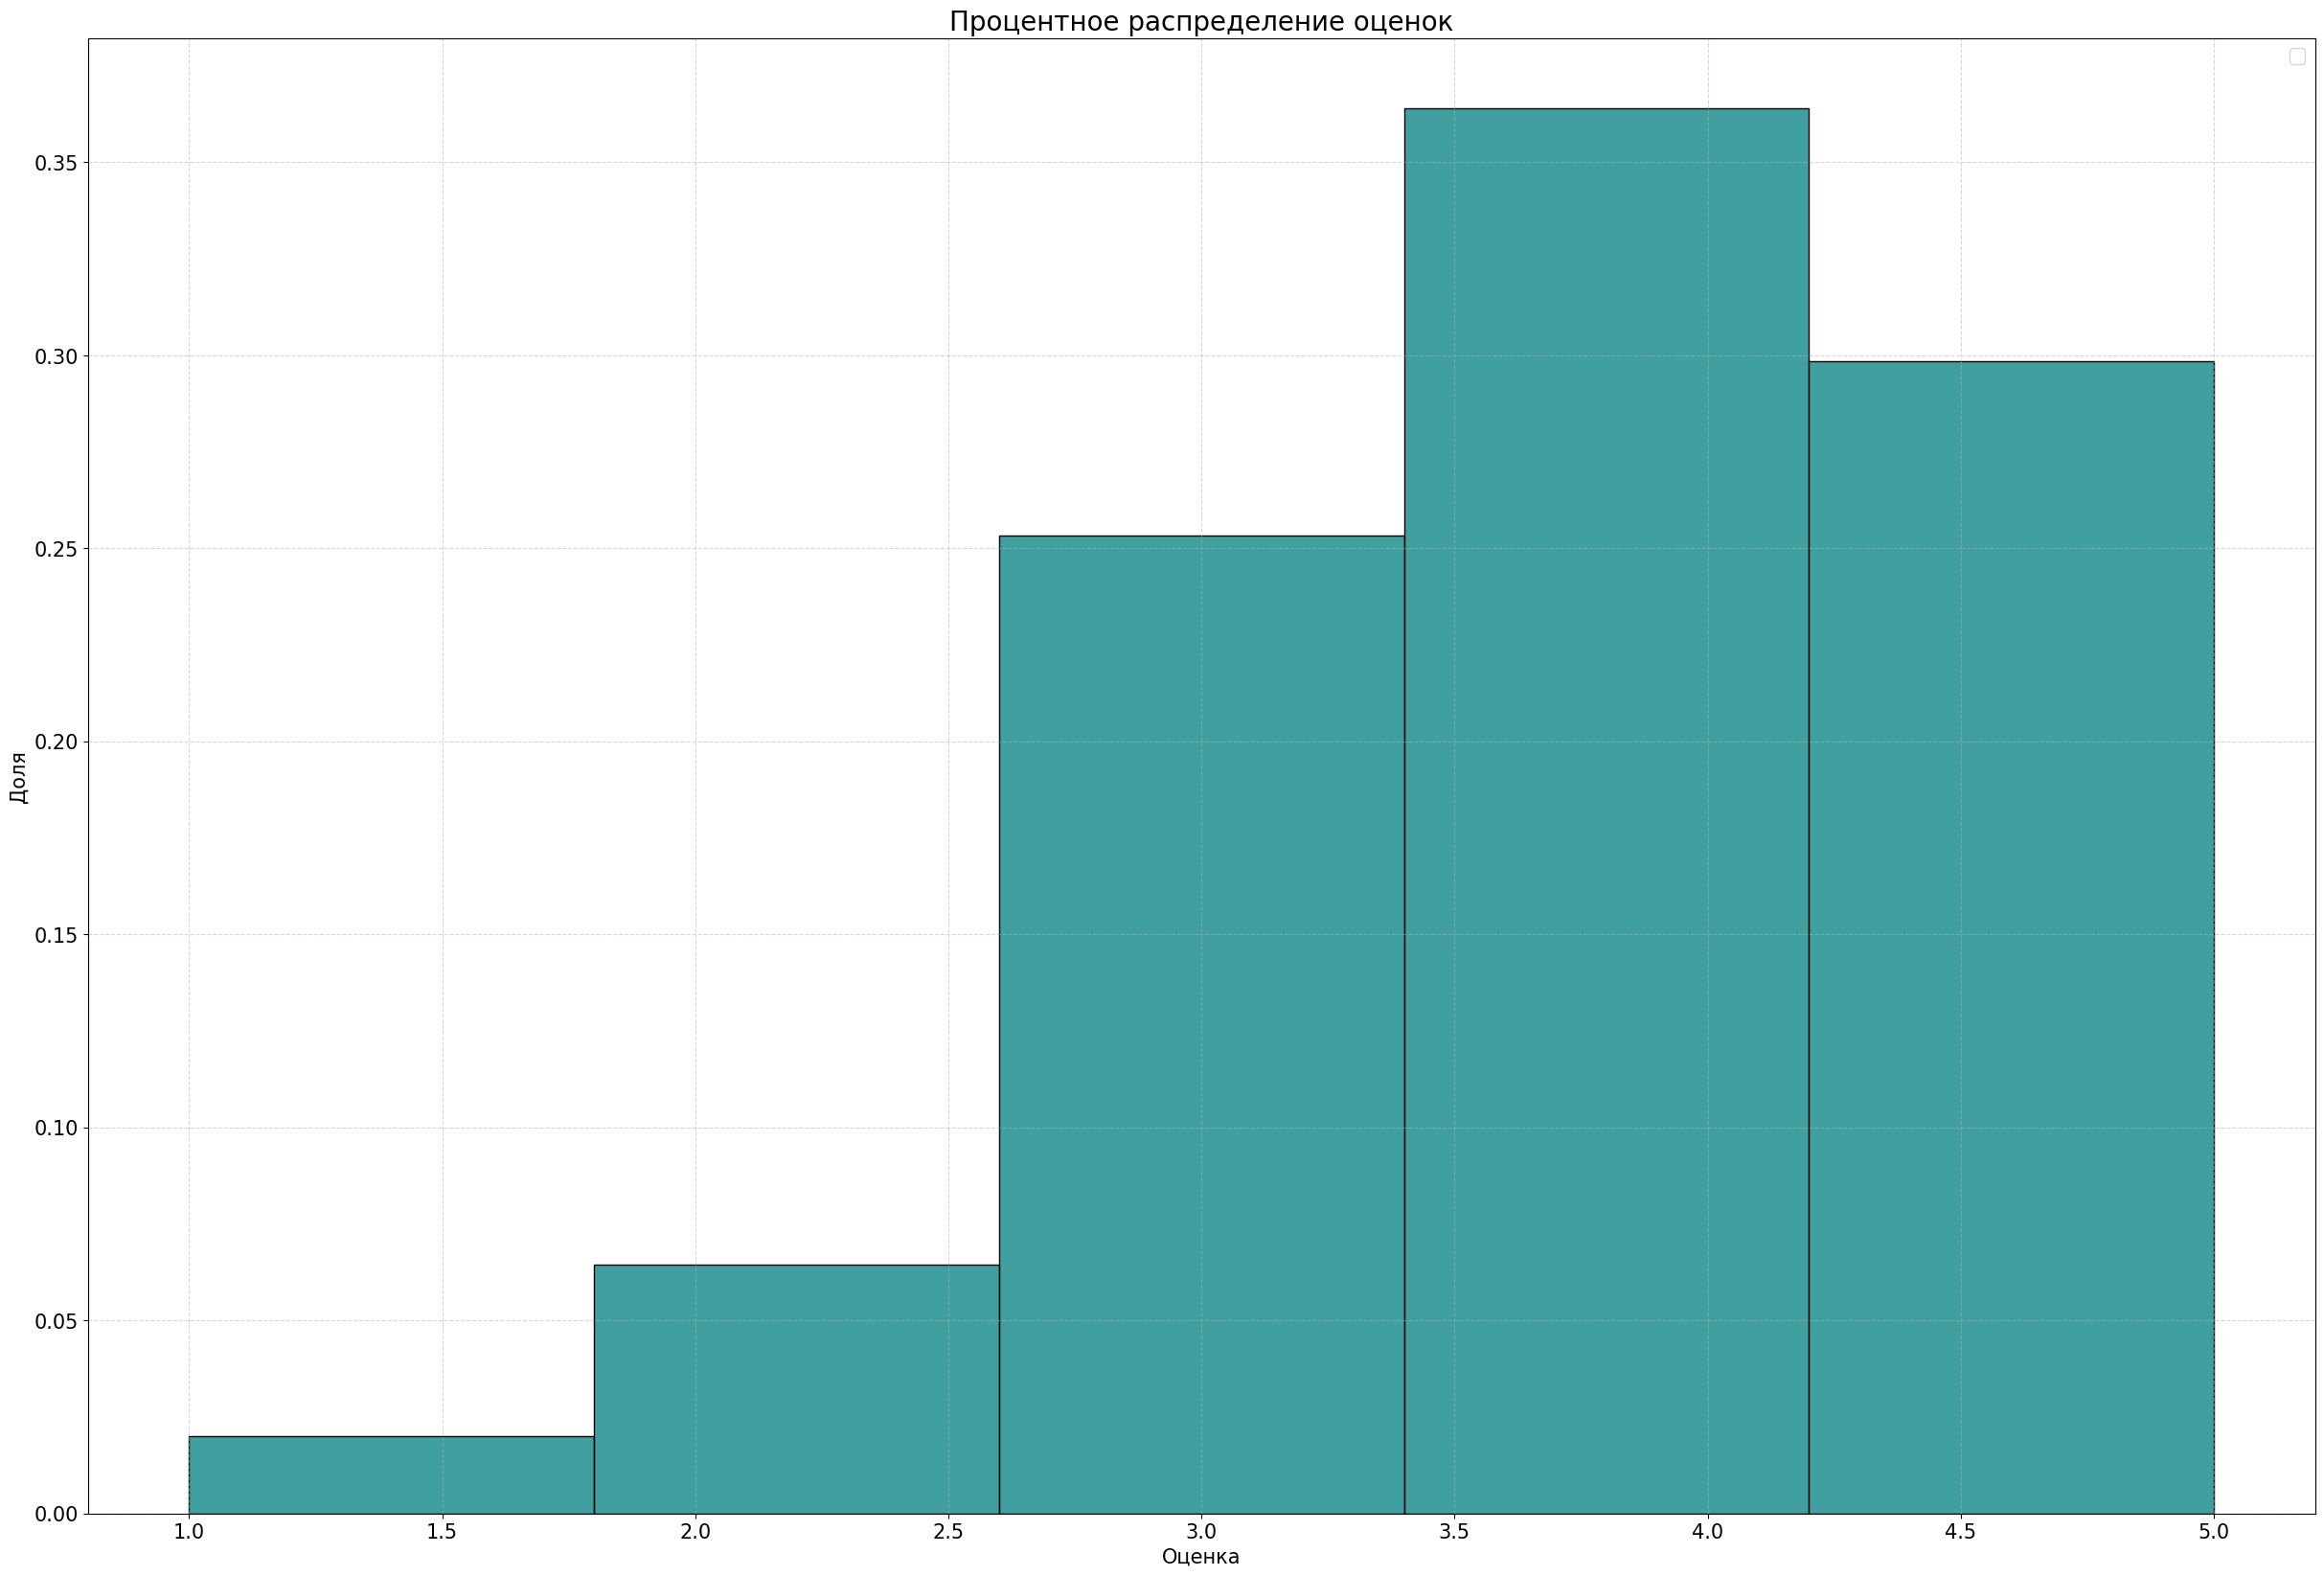

---------------------------------------------------------------------------------------------------------------------------


In [10]:
# Задаём заглавие для графика
print('\n==============================================| График распределения оценок |==============================================\n')
print('-' * 123)

# Задаём размер графика
plt.figure(figsize = (30, 20))

# Визуализация распределения оценок
sns.countplot(
    x = 'rating', 
    data = ratings_df, 
    palette = 'Set1'
)

# Задаём параметры графика 
plt.title('Распределение оценок в датасете Goodbooks-10k', fontsize = 20)  # задаём заголовок к графику
plt.xlabel('Оценка', fontsize = 15) 
plt.ylabel('Количество', fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.legend(fontsize = 15)
plt.grid(True, linestyle = '--', alpha = 0.5)

# Отображаем график
plt.show()
print('-' * 123)
print('\n\n')





# Задаём заглавие для графика
print('\n\n====================================| График распределения гистограммы с процентами |=====================================\n')
print('-' * 123)

# Задаём размер графика
plt.figure(figsize = (30, 20))

# Визуализация гистограммы с процентами
sns.histplot(
    ratings_df['rating'], 
    bins = 5, 
    stat = 'probability', 
    color = 'teal'
)

# Задаём заголовок к графику
plt.title('Процентное распределение оценок', fontsize = 20)         

# Задаём параметры графика       
plt.xlabel('Оценка', fontsize = 15)
plt.ylabel('Доля', fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.legend(fontsize = 15)
plt.grid(True, linestyle = '--', alpha = 0.5)

# Отображаем график
plt.show()
print('-' * 123)

**Вывод:**

Данные сильно смещены к высоким оценкам — пользователи в основном ставят 4 и 5. Это означает, что релевантными считаются книги с рейтингом ≥4. Низкие оценки почти отсутствуют.

#### $1.6$

#### **Анализ активности пользователей.**

Выведем статистические данные по активности пользователей:

In [11]:
# Подсчёт количества оценок на пользователя
user_activity = ratings_df.groupby('user_id')['rating'].count().reset_index()
user_activity.columns = ['user_id', 'rating_count']



# Задаём заголовок
print('\n============| Информация по оценкам на пользователя |============\n\n')

# Основные статистики
print(f'Статистика активности пользователей:\n\n{user_activity['rating_count'].describe()}')
print('-' * 35)

print(f'\nОбщее количество пользователей: {len(user_activity)}')
print('-' * 37)

print(f'\nСреднее количество оценок на пользователя: {user_activity['rating_count'].mean():.2f}')
print('-' * 48)

print(f'\nМедиана количества оценок: {user_activity['rating_count'].median():.2f}')
print('-' * 33)


============| Информация по оценкам на пользователя |============


Статистика активности пользователей:

count    53424.000000
mean        18.376685
std         26.268690
min          2.000000
25%          3.000000
50%          8.000000
75%         22.000000
max        200.000000
Name: rating_count, dtype: float64
-----------------------------------

Общее количество пользователей: 53424
-------------------------------------

Среднее количество оценок на пользователя: 18.38
------------------------------------------------

Медиана количества оценок: 8.00
---------------------------------


**Вывод:**

Данные сильно смещены к высоким оценкам — пользователи в основном ставят 4 и 5. Это означает, что релевантными считаются книги с рейтингом ≥4. Низкие оценки почти отсутствуют.

Опредилим самых активных пользователей:

In [12]:
# Определим топ-5% пользователей по количеству оценок
top_5_percentile = user_activity['rating_count'].quantile(0.95)

# Настроим порог для холодного старта
cold_start_threshold = 50

# Выделяем самых активных пользователей
active_users = user_activity[user_activity['rating_count'] >= top_5_percentile]

# Выделяем пользователей с малым количеством взаимодействий
cold_start_users = user_activity[user_activity['rating_count'] <= cold_start_threshold]




# Задаём заголовок
print('\n============| Информация по самым активным пользователям |============\n\n')

# Выведем результаты
print(f'\nАктивные пользователи (топ-5%, >= {top_5_percentile} оценок): {len(active_users)}')
print('-' * 52)
print()

print(f'Пользователи с малым количеством взаимодействий (<= {cold_start_threshold} оценок): {len(cold_start_users)}')
print('-' * 69)


============| Информация по самым активным пользователям |============



Активные пользователи (топ-5%, >= 71.0 оценок): 2675
----------------------------------------------------

Пользователи с малым количеством взаимодействий (<= 50 оценок): 48643
---------------------------------------------------------------------


Построим график *«Взаимоотношение количества пользователей и количества оценок»*:


================================| График распределения количества оценок на пользователя |=================================

---------------------------------------------------------------------------------------------------------------------------


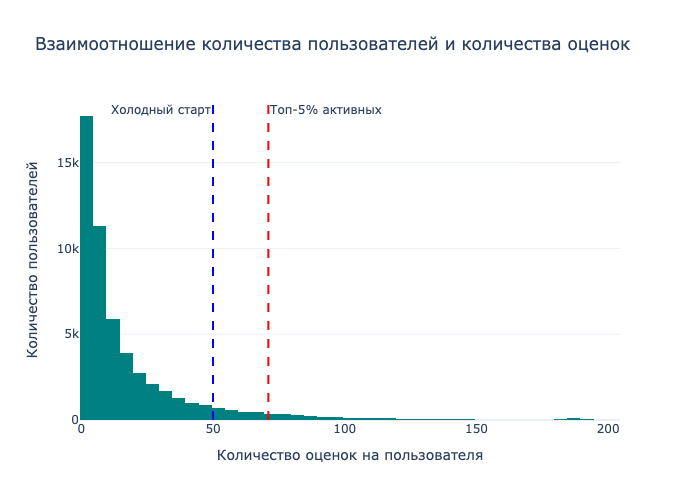

---------------------------------------------------------------------------------------------------------------------------


In [13]:
# Задаём заглавие для графика
print('\n================================| График распределения количества оценок на пользователя |=================================\n')
print('-' * 123)



# График: Распределение количества оценок на пользователя
fig = px.histogram(
    user_activity, 
    x = 'rating_count', 
    height = 800,
    width = 1200,
    nbins = 50,  
    title = 'Взаимоотношение количества пользователей и количества оценок',
    
    labels = {
        'rating_count': 'Количество оценок', 
        'count': 'Количество пользователей'
    },
    
    color_discrete_sequence = ['teal'],
    template = 'plotly_white',
)



# Настройка осей и шаблона графика
fig.update_layout(
    xaxis_title = 'Количество оценок на пользователя',
    yaxis_title = 'Количество пользователей',
    template = 'plotly_white',
    showlegend = False
)



# Добавление аннотаций для активных пользователей и холодного старта
fig.add_vline(
    x = top_5_percentile, 
    line_dash = 'dash', 
    line_color = 'red', 
    annotation_text = 'Топ-5% активных', 
    annotation_position = 'top right'
)



# Добавление аннотации для холодного старта
fig.add_vline(
    x = cold_start_threshold, 
    line_dash = 'dash', 
    line_color = 'blue', 
    annotation_text = 'Холодный старт', 
    annotation_position = 'top left'
)



# Отображаем график
fig.show('png')
print('-' * 123)

**Вывод:**

Датасет сильно несбалансирован — огромная доля "холодных" пользователей с малой историей. Это требует устойчивых к разреженности моделей и гибридных подходов для новых пользователей.

#### $1.7$

#### **Анализ популярности книг.** 

Выведем статистические данные пооценкам книг:

In [14]:
# Подсчёт количества оценок на книгу
book_popularity = ratings_df.groupby('book_id')['rating'].count().reset_index()
book_popularity.columns = ['book_id', 'rating_count']




# Задаём заголовок
print('\n============| Информация по количеству оценок на книгу |============\n\n')

# Основные статистики
print(f'Статистика популярности книг:\n\n{book_popularity['rating_count'].describe()}')
print('-' * 35)

print(f'\nОбщее количество книг: {len(book_popularity)}')
print('-' * 37)

print(f'\nСреднее количество оценок на книгу: {book_popularity['rating_count'].mean():.2f}')
print('-' * 48)

print(f'\nМедиана количества оценок: {book_popularity['rating_count'].median():.2f}')
print('-' * 33)


============| Информация по количеству оценок на книгу |============


Статистика популярности книг:

count    10000.000000
mean        98.175600
std          5.690167
min          8.000000
25%         99.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: rating_count, dtype: float64
-----------------------------------

Общее количество книг: 10000
-------------------------------------

Среднее количество оценок на книгу: 98.18
------------------------------------------------

Медиана количества оценок: 100.00
---------------------------------


**Вывод:**

Датасет сбалансирован по популярности книг — почти все книги имеют около 100 оценок. Это исключает сильное смещение к сверхпопулярным книгам, но создаёт искусственную однородность.

Выявим популярные книги и «длинный хвост»:

In [15]:
# Вычислим топ-5% книг по количеству оценок
top_5_percentile = book_popularity['rating_count'].quantile(0.95)

# Настроим порог для "длинного хвоста"
long_tail_threshold = 100

# Определяем популярные книги
popular_books = book_popularity[book_popularity['rating_count'] >= top_5_percentile]

# Определяем книги с малым количеством оценок
long_tail_books = book_popularity[book_popularity['rating_count'] <= long_tail_threshold]




# Задаём заголовок
print('\n============| Информация по самым популярным книгам |============\n\n')

# Выведем результаты
print(f'\nПопулярные книги (топ-5%, >= {top_5_percentile} оценок): {len(popular_books)}')
print('-' * 50)
print()

print(f'Книги с малым количеством оценок (<= {long_tail_threshold} оценок): {len(long_tail_books)}')
print('-' * 55)


============| Информация по самым популярным книгам |============



Популярные книги (топ-5%, >= 100.0 оценок): 7456
--------------------------------------------------

Книги с малым количеством оценок (<= 100 оценок): 10000
-------------------------------------------------------


Построим график «Количество книг vs количество оценок»:


====================================| График распределения количества оценок на книгу |====================================

---------------------------------------------------------------------------------------------------------------------------


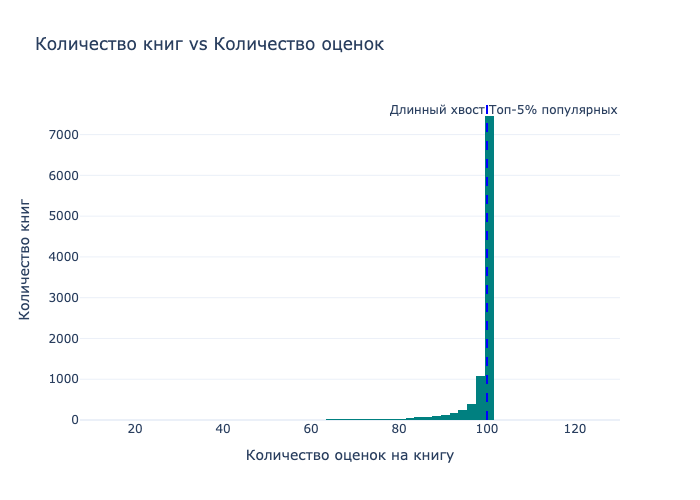

---------------------------------------------------------------------------------------------------------------------------


In [16]:
# Задаём заглавие для графика
print('\n====================================| График распределения количества оценок на книгу |====================================\n')
print('-' * 123)



# График: Распределение количества оценок на книгу
fig = px.histogram(
    book_popularity, 
    x = 'rating_count', 
    nbins = 50,  
    height = 800,
    width = 1200,
    title = 'Количество книг vs Количество оценок',
    
    labels = {
        'rating_count': 'Количество оценок', 
        'count': 'Количество книг'
    },
    
    color_discrete_sequence = ['teal'])



# Настройка осей и шаблона графика
fig.update_layout(
    xaxis_title = 'Количество оценок на книгу',
    yaxis_title = 'Количество книг',
    template = 'plotly_white',
    showlegend = False
)



# Добавление аннотаций для популярных книг и "длинного хвоста"
fig.add_vline(
    x = top_5_percentile, 
    line_dash = 'dash', 
    line_color = 'red', 
    annotation_text = 'Топ-5% популярных', 
    annotation_position = 'top right'
)



# Добавление аннотации для "длинного хвоста"
fig.add_vline(
    x = long_tail_threshold, 
    line_dash = 'dash', 
    line_color = 'blue', 
    annotation_text = 'Длинный хвост', 
    annotation_position = 'top left'
)



# Отображаем график
fig.show('png')
print('-' * 123)

**Вывод:**

Датасет искусственно сбалансирован — основная масса книг имеет ровно 100 оценок, что минимизирует смещение к бестселлерам. Однако присутствует длинный хвост непопулярных книг (<100 оценок).

#### $1.8$

#### **Анализ тегов.**

Выявим самые популярные теги:

In [17]:
# Объединение book_tags_df с tags_df для получения названий тегов
book_tags = book_tags_df.merge(
    tags_df,
    on = 'tag_id',
    how = 'left'
)


# Подсчёт общего количества применений каждого тега
tag_popularity = book_tags.groupby('tag_name')['count'].sum().reset_index()
tag_popularity = tag_popularity.sort_values('count', ascending = False)


# Выбор топ-20 тегов
top_tags = tag_popularity.head(20)




# Задаём заголовок
print('\n============| Информация по самым популярным тегам |============\n\n')

# Основные статистики
print(f'Топ-20 самых частых тегов:\n\n{top_tags}')
print('-' * 35)

print(f'\nОбщее количество уникальных тегов: {len(tag_popularity)}')
print('-' * 42)

print(f'\nМаксимальное количество применений тега: {tag_popularity['count'].max():,.0f}')
print('-' * 53)

print(f'\nСреднее количество применений тега: {tag_popularity['count'].mean():,.2f}')
print('-' * 45)


============| Информация по самым популярным тегам |============


Топ-20 самых частых тегов:

                 tag_name      count
30574             to-read  140718761
8717    currently-reading    7507958
11557           favorites    4503173
11743             fiction    3688819
11305             fantasy    3548157
33114         young-adult    1848306
7457             classics    1756920
5207          books-i-own    1317235
26138             romance    1231926
22743               owned    1224279
32989                  ya     898334
20939             mystery     872282
21689         non-fiction     857901
14487  historical-fiction     815421
27199              series     782637
26837     science-fiction     703866
26771              sci-fi     597325
22973          paranormal     542559
17213              kindle     506882
8055         contemporary     486001
-----------------------------------

Общее количество уникальных тегов: 34252
------------------------------------------

Макси

Визуализируем самые частые теги для книг:


=======================================| График топ-20 самых частых тегов для книг |=======================================

---------------------------------------------------------------------------------------------------------------------------


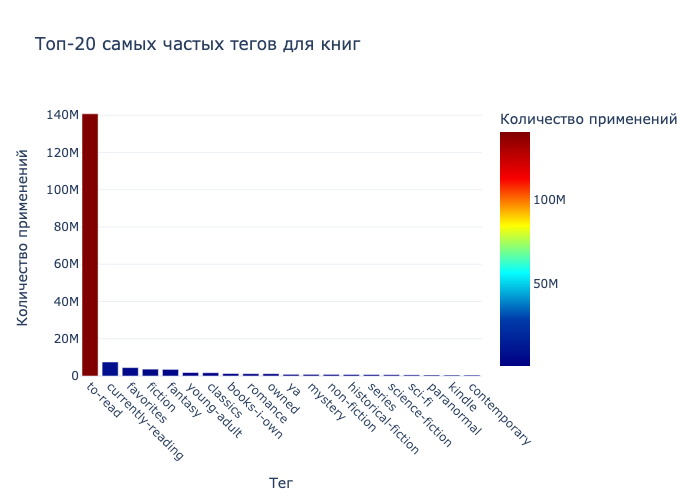

---------------------------------------------------------------------------------------------------------------------------


In [18]:
# задаём заглавие для графика
print('\n=======================================| График топ-20 самых частых тегов для книг |=======================================\n')
print('-' * 123)    


# Строим график Топ-20 самых частых тегов для книг
fig = px.bar(
    top_tags,
    x = 'tag_name', 
    y = 'count',
    height = 600,
    width = 1200,
    title = 'Топ-20 самых частых тегов для книг',
    
    labels = {
        'tag_name': 'Тег', 
        'count': 'Количество применений'
    },
    
    color = 'count', 
    color_continuous_scale = 'jet'
)


# Настройка осей и шаблона графика
fig.update_layout(
    xaxis_title = 'Тег',
    yaxis_title = 'Количество применений',
    xaxis_tickangle = 45, 
    template = 'plotly_white',
    showlegend = False
)


# Отображаем график
fig.show('png')
print('-' * 123)

**Вывод:**

По построенному графику можно заключить, что тег `to-read` аномально доминирует — это не жанр, а статус ('хочу прочитать'). Жанровые теги (`fiction`, `fantasy`, `mystery` и др.) распределены равномерно и информативно.

#### $1.9$

Какие основные проблемы данных (разреженность, смещение популярности) видны уже на этапе EDA?

=====================================================================================================================================

## <CENTER> **`2.` Базовые и контентные модели**

На данном этапе мы реализуем простые, но эффективные модели-бейзлайны.

#### $2.1$

#### **Разделение данных на обучающую и тестовую выборки.**

Создаём функции для выбора метода разделения данных:

In [19]:
# Создаём функцию 'split_random' для случайного разделения данных
def split_random(interactions, test_size = 0.2):
    
    '''       
    Функция для случайного разделения данных на train и test.
    
    Параметры:
        - interactions: DataFrame с взаимодействиями (user_id, book_id, rating)
        - test_size: Доля тестовой выборки (по умолчанию 0.2)
    
    Возвращает: 
        - train (DataFrame), test (DataFrame), leakage (bool)
    '''
    
    # Случайное разделение данных
    train, test = model_selection.train_test_split(
        interactions,
        test_size = test_size,
        random_state = 42
    )
    
    # Вывод информации о разделении
    print(f'Train data: {len(train):,} записей;')
    print(f'Test data: {len(test):,} записей.')
    
    # Проверка на утечку данных
    leakage = len(set(train['user_id']) & set(test['user_id'])) > 0 and len(set(train['book_id']) & set(test['book_id'])) > 0
    print('ОБНАРУЖЕНА УТЕЧКА ДАННЫХ!' if leakage else 'Утечки данных не обнаружено.')
    
    # Возвращаем результат
    return train, test, leakage
    
    
    
    
    
    
    
# Функция для временного глобального разделения данных
def split_temporal_global(interactions):
    
    '''
    Функция для временного глобального разделения данных на train и test.
    
    Параметры:
        - interactions: DataFrame с взаимодействиями (user_id, book_id, rating)
        
    Возвращает:
        - train (DataFrame), test (DataFrame), leakage (bool)
    '''
    
    # Симулируем сортировку по 'book_id' как прокси времени
    interactions_sorted = interactions.sort_values('book_id')
    split_idx = int(len(interactions_sorted) * 0.8)
    train = interactions_sorted.iloc[:split_idx]
    test = interactions_sorted.iloc[split_idx:]
    
    # Вывод информации о разделении
    print(f'Train data: {len(train):,} записей;')
    print(f'Test data: {len(test):,} записей.')
    
    # Проверка на утечку данных
    leakage = len(set(train['user_id']) & set(test['user_id'])) > 0
    print('ОБНАРУЖЕНА УТЕЧКА ДАННЫХ!' if leakage else 'Утечки данных не обнаружено.')
    
    # Возвращаем результат
    return train, test, leakage







# Функция для разбиения данных по пользователям
def train_test_split_by_user(ratings_df, test_size=0.2, random_state=42):
    
    '''          
    Функция для разбиения данных по пользователям.
    Для каждого пользователя случайным образом выделяется часть его взаимодействий в тестовую выборку,
    а остальные остаются в обучающей выборке. Это позволяет избежать утечки данных между пользователями и обеспечивает более реалистичную оценку модели на новых пользователях.
    
    Параметры:
        - ratings_df: DataFrame с рейтингами (user_id, book_id, rating)
        - test_size: Доля тестовой выборки для каждого пользователя (по умолчанию 0.2)
        - random_state: Семя для генератора случайных чисел (по умолчанию 42) для воспроизводимости результатов
        
    Возвращает:
        - train_df: DataFrame с обучающей выборкой
        - test_df: DataFrame с тестовой выборкой
    '''
    
    # Устанавливаем семя для генератора случайных чисел для воспроизводимости
    np.random.seed(random_state)
    
    # Инициализируем списки для хранения данных train и test
    train_list = []
    test_list = []
    
    
    # Проходим по каждому пользователю и его данным
    for user_id, user_data in ratings_df.groupby('user_id'):
        
        # Если у пользователя меньше 2 взаимодействий, пропускаем его, так как нельзя выделить тестовую выборку
        if len(user_data) < 2:
            continue  
        
        # Вычисляем количество записей для тестовой выборки для данного пользователя
        n_test = max(1, int(len(user_data) * test_size))
        
        # Случайным образом выбираем индексы для тестовой выборки
        test_idx = np.random.choice(
            user_data.index,
            size=n_test,
            replace=False
        )
        
        # Добавляем данные в списки train и test
        test_list.append(user_data.loc[test_idx])
        train_list.append(user_data.drop(test_idx))


    # Объединяем списки в итоговые DataFrame
    train_df = pd.concat(train_list).reset_index(drop=True)
    test_df = pd.concat(test_list).reset_index(drop=True)
    
    # Вывод информации о результатах разбиения
    print('\n====================| Результаты разбиения данных по пользователям |====================\n')
    print(f'Размер обучающей выборки: {len(train_df):,}')
    print(f'Размер тестовой выборки: {len(test_df):,}')
    print(f'Уникальных пользователей в обучающей выборке: {train_df["user_id"].nunique():,}')
    print(f'Уникальных пользователей в тестовой выборке: {test_df["user_id"].nunique():,}')
    print(f'Уникальных книг в обучающей выборке: {train_df["book_id"].nunique():,}')
    print(f'Уникальных книг в тестовой выборке: {test_df["book_id"].nunique():,}')
    print('-' * 80)
    
    
    # Проверка на утечку данных между train и test
    #user_leakage = set(train_df['user_id']) & set(test_df['user_id'])
    #book_leakage = set(train_df['book_id']) & set(test_df['book_id'])
    #if user_leakage or book_leakage:
    #    print(f'Утечка данных: пользователи = {len(user_leakage)}, книги = {len(book_leakage)}')
    #else:
    #    print('Утечки данных не обнаружено.')
        
        
    # Возвращаем результат
    return train_df, test_df

Проверяем каждый метод разделения:

In [ ]:
# Анализ методов разделения данных
print('\n===============| АНАЛИЗ МЕТОДОВ РАЗДЕЛЕНИЯ ДАННЫХ |===============\n\n')


# Список методов разделения данных
methods_lst = [
    ('Случайное разбиение', split_random),
    ('Временное разбиение (симуляция по book_id)', split_temporal_global),
    ('Разбиение по пользователям', train_test_split_by_user)
]


# Выполнение анализа для каждого метода
results_lst = []
for name, func in methods_lst:
    print(f'---- {name} ----')
    train_data, test_data, leakage = func(ratings_df.copy())
    results_lst.append(
        {
            'Метод': name,
            'Train записей': len(train_data),
            'Test записей': len(test_data),
            'Утечка': 'Да' if leakage else 'Нет'
        }
    )
    print('\n')
print('-' * 65)
print('\n\n\n')
    
    
    
# Таблица результатов
results_df = pd.DataFrame(results_lst)
print('=========================| ИТОГОВАЯ ТАБЛИЦА: |=========================\n')
display(results_df)
print('-' * 80)

**Вывод:**

Из проверенных методов, самым подходящим является метод разбиения по пользователям , им мы и воспользуемся.

Применяем функцию `train_test_split_by_user` для разделения данных на тренировочную и тестовую выборки:

In [20]:
# Применяем метод разбиения по пользователям для получения train и test
train_df, test_df = train_test_split_by_user(ratings_df, test_size = 0.2)
print('\n\n\n')




# Выводим информацию по train и test
check_data_inf(
    data = train_df,
    data_name = 'train_df',
    length1 = 40,
    length2 = 55
)
print('\n\n')


check_data_inf(
    data = test_df,
    data_name = 'test_df',
    length1 = 40,
    length2 = 55
)


====================| Результаты разбиения данных по пользователям |====================

Размер обучающей выборки: 790,350
Размер тестовой выборки: 191,406
Уникальных пользователей в обучающей выборке: 53,424
Уникальных пользователей в тестовой выборке: 53,424
Уникальных книг в обучающей выборке: 10,000
Уникальных книг в тестовой выборке: 10,000
--------------------------------------------------------------------------------





====================| Данные таблицы "train_df" имеют следующую размерность: |====================

Количество строк: 790350;
Количество признаков (столбцов): 3.
----------------------------------------


,book_id,user_id,rating
0,4893,1,3
1,6285,1,4
2,8034,2,4
3,9762,2,4
4,9014,3,1
...,...,...,...
790345,8262,53424,4
790346,8609,53424,4
790347,8726,53424,4
790348,8969,53424,5


-------------------------------------------------------




====================| Данные таблицы "test_df" имеют следующую размерность: |====================

Количество строк: 191406;
Количество признаков (столбцов): 3.
----------------------------------------


,book_id,user_id,rating
0,1180,1,4
1,8855,2,5
2,9049,3,1
3,3469,4,5
4,8072,5,5
...,...,...,...
191401,2300,53422,4
191402,8712,53423,5
191403,7833,53424,4
191404,1109,53424,3


-------------------------------------------------------


#### $2.2$

#### **Неперсонализированная модель.** 

Реализуем алгоритм, возвращающий *Top-N* самых популярных книг (по среднему рейтингу с порогом минимального количества оценок).

Для начала создадим класс, реализующий данный алгоритм:

In [55]:
# Создание класса для модели рекомендаций на основе популярных книг
class PopularBooksRecommender:
    
    
    '''
    Неперсонализированная модель рекомендаций, возвращающая топ-N книг
    по среднему рейтингу с порогом минимального количества оценок.
    
    Параметры:
        - train_df: DataFrame с данными по книгам, пользователям и оценкам
        - books_df: DataFrame с данными, содержащими всю информацию по книгам
        
    Возвращает:
        - DataFrame с рекомендациями для пользователей
    '''
    
    
    # Инициализация модели
    def __init__(self, train_df, books_df, min_ratings = 50):
        
        '''          
        Инициализация модели.
        
        Параметры:
            - train_df: DataFrame с данными по книгам, пользователям и оценкам
            - books_df: DataFrame с данными, содержащими всю информацию по книгам
            - min_ratings: Минимальное количество оценок для включения книги в рекомендации (по умолчанию 50)   
        Возвращает:
            - None (инициализация модели)
        '''
        
        # Считаем статистику по книгам
        self.train_df = train_df.copy()                  # сохраняем копию train_df для дальнейшего использования
        stats = train_df.groupby('book_id').agg(         # группируем по book_id и вычисляем средний рейтинг и количество оценок
            mean_rating = ('rating', 'mean'),
            n_ratings = ('rating', 'count')
        ).reset_index()
        
        # Фильтр по минимальному количеству оценок
        stats = stats[stats['n_ratings'] >= min_ratings]
        
        # Вычисляем скоринг для ранжирования книг 
        stats['score'] = stats['mean_rating'] * np.log1p(stats['n_ratings'])
        
        # Добавляем метаданные из books_df
        stats = stats.merge(
            books_df[['book_id', 'original_title', 'authors']],
            on = 'book_id',
            how = 'left'
        )
        
        # Сортируем книги по скорингу и сохраняем результат
        self.popular_books = stats.sort_values('score', ascending = False).reset_index(drop = True)
        self.books_df = books_df
    
    
    
    
    
    # Метод для получения топ-N популярных книг
    def get_top_n_popular(self, n = 10):
        
        ''' 
        Возвращает топ-N популярных книг по среднему рейтингу и количеству оценок.
        
        Параметры:
            - n: Количество книг в топе (по умолчанию 10)
        Возвращает:
            - DataFrame с колонками book_id, mean_rating, n_ratings, original_title, authors
        '''
        
        # Выбираем топ-N книг из self.popular_books и нужные колонки
        top = self.popular_books.head(n)[
            ['book_id', 'mean_rating', 'n_ratings', 'original_title', 'authors']
        ]
    
        # Заполняем NaN в original_title из books_df
        if 'title' in self.books_df.columns:
            title_map = dict(zip(self.books_df['book_id'], self.books_df['title']))
            top['original_title'] = top['original_title'].fillna(
                top['book_id'].map(title_map)
            )
    
        # Заполняем NaN в authors из books_df
        top['authors'] = top['authors'].fillna('Unknown')
    
        # Переименовываем колонки для единообразия
        top = top.rename(
            columns = {
                'mean_rating': 'mean_rating',
                'n_ratings': 'n_ratings',
                'original_title': 'original_title',
                'authors': 'authors'
            }
        )
        
        # Возвращаем топ-N популярных книг
        return top
    
    
    
    
    
    # Метод для получения рекомендаций для конкретного пользователя
    def get_recommendations(self, user_id, read, n = 5):
        
        '''
        Возвращает топ-N рекомендаций для конкретного пользователя, исключая уже прочитанные книги.
        
        Параметры:
            - user_id: Идентификатор пользователя
            - read: Множество идентификаторов книг, которые пользователь уже прочитал
            - n: Количество рекомендуемых книг (по умолчанию 5)
        Возвращает:
            - DataFrame с колонками user_id, book_id, predicted_rating, original_title
        '''
        
        # Получаем топ-N популярных книг с запасом, чтобы исключить уже прочитанные
        top_books = self.get_top_n_popular(n = n*2)                         # получаем топ-N популярных книг с запасом (n*2), чтобы исключить уже прочитанные
        recs = top_books[~top_books['book_id'].isin(read)].head(n)          # исключаем уже прочитанные книги и выбираем топ-N рекомендаций
        recs['user_id'] = user_id                                           # добавляем колонку user_id для идентификации пользователя
        recs = recs.rename(columns = {'mean_rating': 'predicted_rating'})   # переименовываем колонку mean_rating в predicted_rating для единообразия
        
        # Возвращаем рекомендации с нужными колонками
        return recs[['user_id', 'book_id', 'predicted_rating', 'original_title']]
    
    
    
    
    
    # Метод для получения рекомендаций для списка пользователей
    def get_recommendations_all_users(self, test_users, n = 5):
        
        '''           
        Создаёт рекомендации для списка пользователей.
        
        Параметры:
            - test_users: Список идентификаторов пользователей, для которых нужно создать рекомендации
            - n: Количество рекомендуемых книг для каждого пользователя (по умолчанию 5)
        Возвращает:
            - DataFrame с колонками user_id, book_id, predicted_rating, original_title
        '''
        
        # Создаём словарь с прочитанными книгами для каждого пользователя в тестовой выборке
        user_read_map = self.train_df[self.train_df['user_id'].isin(test_users)].groupby('user_id')['book_id'].apply(set).to_dict()
        
        # Создаём рекомендации для каждого пользователя в списке test_users
        recs_list = []
        
        # Проходим по каждому пользователю в test_users и создаём рекомендации, исключая уже прочитанные книги
        for uid in test_users:                         
            read = user_read_map.get(uid, set())           # получаем множество прочитанных книг для данного пользователя (или пустое множество, если пользователь не найден)
            rec = self.get_recommendations(uid, read, n)   # получаем рекомендации для данного пользователя, исключая уже прочитанные книги
            recs_list.append(rec)                          # добавляем рекомендации в список
            
        # Объединяем все рекомендации в один DataFrame и возвращаем результат
        return pd.concat(recs_list, ignore_index = True)

Генерируем рекомендации:

In [56]:
# Выводим информацию по модели рекомендаций на основе популярных книг
print('\n')
print('-' * 87)
print('============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ ПОПУЛЯРНЫХ КНИГ |============')
print('-' * 87)



# Инициализируем модель рекомендаций на основе популярных книг с порогом в 50 оценок
PB_recommender = PopularBooksRecommender(
    train_df = train_df,
    books_df = books_df,
    min_ratings = 50  
)

# Получаем топ-10 популярных книг по среднему рейтингу и количеству оценок
top_popular = PB_recommender.get_top_n_popular(n = 10)
display(top_popular)
print('-' * 87)



---------------------------------------------------------------------------------------
============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ ПОПУЛЯРНЫХ КНИГ |============
---------------------------------------------------------------------------------------


,book_id,mean_rating,n_ratings,original_title,authors
0,8978,4.763441,93,NaN,Unknown
1,6920,4.779070,86,NaN,Unknown
2,6590,4.750000,88,NaN,Unknown
3,5580,4.817073,82,NaN,Unknown
4,5207,4.746988,83,NaN,Unknown
5,2244,4.662921,89,NaN,Unknown
6,9566,4.828947,76,Still Life with Woodpecker,Tom Robbins
7,1788,4.753086,81,NaN,Unknown
8,6361,4.731707,82,NaN,Unknown
9,3275,4.802632,76,NaN,Unknown


---------------------------------------------------------------------------------------


#### $2.3$

#### **Контентная модель.**

Теперь сделаем следующее:

  * Объединим данные о книгах с их тегами. Для каждой книги создадим текстовый «профиль» из названия (*original_title*) и списка тегов.

  * Векторизуем эти профили с помощью `TF-IDF`.

  * Реализуем функцию **get_similar_books(book_id, N=5)**, которая находит $N$ самых похожих книг по косинусной мере близости между их `TF-IDF`-векторами.

Создадим класс для реализации данного алгоритма:

In [57]:
# Создаём класс для контентной модели рекомендаций на основе TF-IDF-векторов текстовых профилей книг
class ContentBasedRecommender:
    
    
    '''   
           
    Контентная модель рекомендаций на основе TF-IDF-векторов текстовых профилей книг.
    Рекомендации формируются на основе сходства между профилем пользователя (усреднённый вектор прочитанных книг) и профилем каждой книги (TF-IDF
    -вектор, построенный на основе названия и тегов книги). Рекомендации исключают уже прочитанные книги.

    Параметры:
        - books_df: DataFrame с данными по книгам (book_id, original_title, title и т.д.)
        - book_tags_df: DataFrame с данными по тегам книг (goodreads_book_id, tag_id, count)
        - tags_df: DataFrame с данными по тегам (tag_id, tag_name)
        - train_df: DataFrame с данными по взаимодействиям пользователей и книг (user_id, book_id, rating) для исключения уже прочитанных
    
    Возвращает:
        - DataFrame с рекомендациями для пользователей (user_id, book_id, predicted_rating, display_title)
        
    '''
    
    
    # Инициализация модели и подготовка профилей и TF-IDF-матрицы
    def __init__(self, books_df, book_tags_df, tags_df, train_df = None):
        
        '''          
        Инициализация модели и подготовка профилей и TF-IDF-матрицы.
        
        Параметры:
            - books_df: DataFrame с данными по книгам (book_id, original_title, title и т.д.)
            - book_tags_df: DataFrame с данными по тегам книг (goodreads_book_id, tag_id, count)
            - tags_df: DataFrame с данными по тегам (tag_id, tag_name)
            - train_df: DataFrame с данными по взаимодействиям пользователей и книг (user_id, book_id, rating) для исключения уже прочитанных (по умолчанию None, но рекомендуется передать для корректной работы модели)
        Возвращает:
            - None (инициализация модели и подготовка данных)
        '''
        
        # Сохраняем переданные DataFrame в атрибутах класса для дальнейшего использования
        self.books_df = books_df           # сохраняем DataFrame с данными по книгам для дальнейшего использования
        self.book_tags_df = book_tags_df   # сохраняем DataFrame с данными по тегам книг для дальнейшего использования
        self.tags_df = tags_df             # сохраняем DataFrame с данными по тегам для дальнейшего использования
        self.train_df = train_df           # сохраняем DataFrame с данными по взаимодействиям для дальнейшего использования (может быть None, но рекомендуется передать для корректной работы модели)
        
        # Подготавливаем профили книг и TF-IDF-матрицу при инициализации модели
        self._prepare_profiles_and_matrix()
    
    
    
    
    
    # Внутренний метод для подготовки профилей книг и TF-IDF-матрицы
    def _prepare_profiles_and_matrix(self):
        
        '''          
        Внутренний метод для подготовки профилей книг и TF-IDF-матрицы.
         - Создаёт текстовый профиль каждой книги на основе названия и тегов.
         - Строит TF-IDF-матрицу для всех книг.
         - Создаёт маппинги для быстрого доступа к данным.
        '''
        
        # Создаём текстовый профиль каждой книги, объединяя название и теги
        tag_map = dict(zip(self.tags_df['tag_id'], self.tags_df['tag_name']))
        bt = self.book_tags_df.copy()
        bt['tag_name'] = bt['tag_id'].map(tag_map)
        
        # Агрегируем теги для каждой книги в одну строку
        bt_agg = (
            bt.groupby('goodreads_book_id')['tag_name']
              .apply(lambda s: ' '.join(sorted(set(map(str, s)))))
              .reset_index()
              .rename(columns = {'goodreads_book_id': 'book_id'})
        )
        
        # Объединяем с книгами для создания профиля каждой книги
        books_profiles = (
            self.books_df[['id', 'book_id', 'original_title', 'title']]
            .merge(bt_agg, on='book_id', how='left')
            .rename(columns={'id': 'internal_id'})
        )
        
        # Создаём колонку display_title, которая будет использоваться для профиля книги (предпочитаем original_title, если он есть, иначе title)
        books_profiles['display_title'] = books_profiles['original_title'].where(
            books_profiles['original_title'].notna() & (books_profiles['original_title'].str.strip() != ''),
            books_profiles['title']
        )
        
        # Заполняем NaN в tag_name пустой строкой и создаём текстовый профиль для каждой книги, объединяя display_title и tag_name
        books_profiles['tag_name'] = books_profiles['tag_name'].fillna('')
        books_profiles['text_profile'] = (
            books_profiles['display_title'].astype(str) + ' ' +
            books_profiles['tag_name'].astype(str)
        ).str.lower()
        
        # Строим TF-IDF-матрицу для всех книг на основе текстового профиля
        self.vectorizer = TfidfVectorizer(max_features=50000, stop_words='english', min_df=2)
        self.tfidf_matrix = self.vectorizer.fit_transform(books_profiles['text_profile'])
        
        # Создаём маппинги для быстрого доступа к данным
        self.goodreads_to_internal = dict(zip(self.books_df['book_id'], self.books_df['id']))
        self.internal_to_row = {bid: i for i, bid in enumerate(books_profiles['internal_id'].tolist())}
        self.books_profiles = books_profiles  
        
    
    
    
    
    # Метод для получения рекомендаций для одного пользователя
    def get_recommendations(self, user_id, n = 5):
        
        '''           
        Возвращает топ-N рекомендаций для одного пользователя, исключая уже прочитанные книги.
        
        Параметры:
            - user_id: Идентификатор пользователя
            - n: Количество рекомендуемых книг (по умолчанию 5)
        Возвращает:
            - DataFrame с колонками user_id, book_id, predicted_rating, display_title
        '''
        
        # Проверяем, передан ли train_df для исключения прочитанных книг
        if self.train_df is None:
            raise ValueError('train_df не передан в __init__ — невозможно исключить прочитанные книги')

        # Получаем список книг, которые пользователь уже прочитал, из train_df
        user_books = self.train_df[self.train_df['user_id'] == user_id]['book_id'].unique()

        # Если пользователь ничего не читал — возвращаем пустой DataFrame с колонками
        if len(user_books) == 0:
            return pd.DataFrame(columns = ['user_id', 'book_id', 'predicted_rating', 'display_title'])


        # Получаем индексы книг, которые пользователь прочитал, для формирования его профиля 
        user_indices = []
        
        # Проходим по каждой книге, которую пользователь прочитал, и находим её внутренний ID и индекс в TF-IDF-матрице
        for b in user_books:
            internal_id = self.goodreads_to_internal.get(b)    # получаем внутренний ID книги по её Goodreads ID
            if internal_id is not None:                        # если внутренний ID найден, получаем индекс строки в TF-IDF-матрице
                row = self.internal_to_row.get(internal_id)    # получаем индекс строки в TF-IDF-матрице по внутреннему ID книги
                if row is not None:                            # если индекс найден, добавляем его в список user_indices для формирования профиля пользователя
                    user_indices.append(row)                   # добавляем индекс книги в список user_indices для формирования профиля пользователя


        # Если пользователь ничего не читал или все прочитанные книги не найдены в профиле — возвращаем пустой DataFrame с колонками
        if not user_indices:
            return pd.DataFrame(columns = ['user_id', 'book_id', 'predicted_rating', 'display_title'])

        # Формируем профиль пользователя как усреднённый вектор прочитанных книг
        user_profile = np.asarray(self.tfidf_matrix[user_indices].mean(axis = 0)).reshape(1, -1)

        # Вычисляем косинусное сходство между профилем пользователя и профилем каждой книги, получая массив сходств для всех книг
        sims = cosine_similarity(user_profile, self.tfidf_matrix).ravel()


        # Исключаем уже прочитанные книги, устанавливая для них сходство -1.0, чтобы они не попали в топ-N рекомендаций
        read_internal_ids = {self.goodreads_to_internal.get(b) for b in user_books if self.goodreads_to_internal.get(b) is not None}
        for i, row in enumerate(self.books_profiles['internal_id']):
            if row in read_internal_ids:
                sims[i] = -1.0

        # Находим индексы топ-N книг с наибольшим сходством, которые не были прочитаны пользователем
        top_idx = np.argsort(sims)[::-1][:n]

        # Если топ-N пустой или все книги в топе имеют сходство -1.0 (т.е. все прочитанные), возвращаем пустой DataFrame с колонками
        if len(top_idx) == 0 or all(sims[top_idx] <= -1.0):
            empty_df = pd.DataFrame(columns = ['user_id', 'book_id', 'predicted_rating', 'display_title'])
            empty_df['user_id'] = user_id
            return empty_df

        # Формируем результат
        out = self.books_profiles.iloc[top_idx][['internal_id', 'display_title']].copy()
        out.rename(columns={'internal_id': 'book_id'}, inplace = True)
        out['predicted_rating'] = sims[top_idx]
        out['user_id'] = user_id

        # Заполняем NaN в display_title из books_df
        out['display_title'] = out['display_title'].fillna('Unknown Title')
        
        # Переупорядочиваем колонки и возвращаем результат
        return out[['user_id', 'book_id', 'predicted_rating', 'display_title']].reset_index(drop = True)
    
    
    
    
    
    # Метод для получения рекомендаций для нескольких пользователей
    def get_recommendations_for_users(self, user_ids, n = 5):
        
        '''          
        Возвращает топ-N рекомендаций для нескольких пользователей, исключая уже прочитанные книги.
        
        Параметры:
            - user_ids: Список идентификаторов пользователей
            - n: Количество рекомендуемых книг для каждого пользователя (по умолчанию 5)
        Возвращает:
            - DataFrame с колонками user_id, book_id, predicted_rating, display_title для всех пользователей в списке user_ids
        '''
        
        # Создаём рекомендации для каждого пользователя в списке user_ids и объединяем результаты в один DataFrame
        recs_list = []
        
        # Проходим по каждому пользователю в списке user_ids и получаем рекомендации, исключая уже прочитанные книги
        for uid in user_ids:
            rec = self.get_recommendations(uid, n)   # получаем рекомендации для данного пользователя, исключая уже прочитанные книги
            if not rec.empty:                        # если рекомендации не пустые, добавляем их в список recs_list для последующего объединения
                recs_list.append(rec)                # добавляем рекомендации в список recs_list для последующего объединения
                
        # Объединяем все рекомендации в один DataFrame и возвращаем результат
        if recs_list:
            return pd.concat(recs_list, ignore_index = True)
        
        # Если нет рекомендаций для всех пользователей (например, если все пользователи не читали книги или все прочитанные книги не найдены в профиле), возвращаем пустой DataFrame с колонками
        return pd.DataFrame(columns = ['user_id', 'book_id', 'predicted_rating', 'display_title'])

Инициализируем созданный класс `ContentBasedRecommender`:

In [58]:
# Выводим информацию по модели рекомендаций на основе контентного подхода
print('\n')
print('-' * 91)
print('============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ КОНТЕНТНОГО ПОДХОДА |============')
print('-' * 91)



# Инициализируем модель рекомендаций на основе контентного подхода, передавая все необходимые DataFrame для корректной работы модели
CB_recommender = ContentBasedRecommender(
    books_df = books_df,
    book_tags_df = book_tags,
    tags_df = tags_df,
    train_df = train_df 
)

# Рекомендации для первых 100 пользователей из тестовой выборки
test_users = test_df['user_id'].unique()[:100]  
cb_recs_df = CB_recommender.get_recommendations_for_users(test_users, n = 5)
display(cb_recs_df.head(10))
print('-' * 91)



-------------------------------------------------------------------------------------------
============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ КОНТЕНТНОГО ПОДХОДА |============
-------------------------------------------------------------------------------------------


,user_id,book_id,predicted_rating,display_title
0,2,2036,0.700095,The Gifts of Imperfection
1,2,6032,0.694618,The Untethered Soul
2,2,790,0.674439,The Four Agreements: A Practical Guide to Pers...
3,2,5008,0.673608,Codependent No More: How to Stop Controlling O...
4,2,4465,0.658526,Feel The Fear And Do It Anyway: How to Turn Yo...
5,3,1795,0.863385,The Running Man
6,3,1339,0.833336,The Mist
7,3,5188,0.822175,Rage
8,3,675,0.819886,Firestarter
9,3,670,0.817505,The Dead Zone


-------------------------------------------------------------------------------------------


=====================================================================================================================================

## <CENTER> **`3.` Коллаборативная фильтрация (Collaborative Filtering — CF)**

На данном этапе мы реализуем классические методы $CF$ и определим их ограничения.

#### $3.1$

#### **Построим матрицу взаимодействий «пользователь — книга» (user_id x book_id).**

Создадим функцию для реализации матрицы:

In [59]:
# Функция для построения матрицы взаимодействий user_id x book_id
def build_user_item_matrix(ratings, use_binary = False):
    
    
    '''       
    
    Функция для построения матрицы взаимодействий user_id x book_id.
    
    Параметры:
        - ratings: DataFrame с данными (user_id, book_id, rating)
        - use_binary: Если True, бинаризует оценки (1 если rating >=4, иначе 0)
    
    Возвращает: 
        - user_item_matrix (DataFrame), item_id_to_index (dict)
    
    '''
    
    
    # Создаём копию данных
    df_copy = ratings.copy()
    
    
    
    # Неявный feedback: 1 если rating >=4, иначе 0
    if use_binary:
        df_copy['rating'] = np.where(df_copy['rating'] >= 4, 1, 0)
        
        
        
    # Проверка входных данных
    if df_copy.empty:
        raise ValueError('Входной DataFrame пустой!')
    if not all(column in df_copy.columns for column in ['user_id', 'book_id', 'rating']):
        raise ValueError('В DataFrame отсутствуют столбцы "user_id", "book_id" или "rating"')
        
        
        
    # Построение матрицы
    try:
        user_item_matrix = df_copy.pivot_table(
            index = 'user_id',
            columns = 'book_id',
            values = 'rating',
            fill_value = 0
        )
    except Exception as e:
        raise ValueError(f'Ошибка в pivot_table: {str(e)}')
    
    
    
    # Проверка на пустую матрицу
    if user_item_matrix.empty:
        raise ValueError('Матрица "user_item_matrix" пустая после "pivot_table"')
    
    
    
    # Преобразование в разреженную матрицу
    user_item_matrix_sparse = csr_matrix(user_item_matrix.values)
    item_id_to_index = {book_id: idx for idx, book_id in enumerate(user_item_matrix.columns)}
    
    
    
    # Вывод результатов
    print('\n===========| Информация по созданной матрице |===========\n\n')
    print(f'Размер матрицы: {user_item_matrix.shape} (пользователи x книги)')
    print(f'Разреженность: {1 - (df_copy.shape[0] / (user_item_matrix.shape[0] * user_item_matrix.shape[1])):.4f}')
    print('-' * 60)
    
    
    
    # Возвращаем результат
    return user_item_matrix, user_item_matrix_sparse, item_id_to_index

Применим созданную функцию для построения матриц с явными оценками и неявным feedback:

In [115]:
# Построение матрицы с явными оценками
user_item_matrix = build_user_item_matrix(
    ratings = train_df,
    use_binary = False
)
print('\n\n')



# Построение матрицы с неявным feedback
user_item_matrix_binary = build_user_item_matrix(
    ratings = train_df,
    use_binary = True
)


===========| Информация по созданной матрице |===========


Размер матрицы: (53424, 10000) (пользователи x книги)
Разреженность: 0.9985
------------------------------------------------------------




===========| Информация по созданной матрице |===========


Размер матрицы: (53424, 10000) (пользователи x книги)
Разреженность: 0.9985
------------------------------------------------------------


#### $3.2$

#### **Реализуем Item-Based Collaborative Filtering.**

* Рассчитаем матрицу попарных схожестей между книгами.

* Для заданной книги и пользователя предскажите оценку, усредняя оценки пользователя по $K$ наиболее похожим книгам.

Для реализации этих шагов создадим класс:

In [60]:
# Создаём класс для модели рекомендаций на основе Item-Based Collaborative Filtering с оптимизацией по памяти и топ-N похожих книг
class ItemBasedCFRecommender:
    
    
    '''
    
    Модель рекомендаций на основе Item-Based Collaborative Filtering с оптимизацией по памяти и топ-N похожих книг.
        1. Строит разреженную матрицу взаимодействий user_id x book_id.
        2. Вычисляет разреженную матрицу сходства между книгами.
        3. Хранит только топ-N похожих книг для каждой книги, чтобы экономить память.
        4. Рекомендует книги на основе сходства, исключая уже прочитанные книги.
        
    '''
    
    
    # Инициализация модели
    def __init__(self, train_df, top_n_similar = 50):
        
        '''          
        Инициализация модели.
        
        Параметры:
            - train_df: DataFrame с данными по книгам, пользователям и оценкам
            - top_n_similar: Количество похожих книг для хранения в топ-N (по умолчанию 50)
        Возвращает:
            - None (инициализация модели)
        '''
        
        # Сохраняем входные данные и параметры
        self.train_df = train_df.copy()        # сохраняем копию train_df для дальнейшего использования
        self.top_n_similar = top_n_similar     # сохраняем параметр top_n_similar для использования при хранении топ-N похожих книг
        self.item_index = None                 # словарь для маппинга book_id в индекс столбца в матрице взаимодействий
        self.index_item = None                 # словарь для маппинга индекса столбца в матрице взаимодействий обратно в book_id
        self.user_item_sparse = None           # разреженная матрица взаимодействий user_id x book_id в формате csr_matrix
        self.item_similarity = None            # разреженная матрица сходства между книгами в формате csr_matrix
        self.top_similar_items = None          # словарь для хранения топ-N похожих книг для каждой книги (ключ - индекс книги, значение - список кортежей (индекс похожей книги, сходство))
    
    
    
    
    
    # Построение разреженной матрицы взаимодействий
    def build_matrix(self):
        
        '''
        Строим разреженную матрицу взаимодействий user_id x book_id.
        '''
        
        # Получаем уникальные пользователи и книги
        users = self.train_df['user_id'].unique()
        items = self.train_df['book_id'].unique()
        
        # Создаём индексы для пользователей и книг
        self.item_index = {bid: i for i, bid in enumerate(items)}
        self.index_item = {i: bid for bid, i in self.item_index.items()}
        
        # Строим разреженную матрицу взаимодействий в формате csr_matrix
        rows = self.train_df['user_id'].astype('category').cat.codes
        cols = self.train_df['book_id'].map(self.item_index)
        data = self.train_df['rating'].values
        
        # Создаём разреженную матрицу взаимодействий в формате csr_matrix
        matrix = csr_matrix((data, (rows, cols)), shape=(len(users), len(items)))
        self.user_item_sparse = matrix
        
        # Выводим информацию по созданной матрице
        print(f'Матрица: {matrix.shape}, разреженность: {1 - matrix.nnz / matrix.size:.6f}')
        
        # Возвращаем разреженную матрицу взаимодействий
        return matrix
    
    
    
    
    
    # Вычисление разреженной матрицы сходства и топ-N похожих книг для каждой книги
    def fit(self):
        
        '''
        Вычисляем разреженную матрицу сходства между книгами и находим топ-N похожих книг для каждой книги.
        '''
        
        # Строим разреженную матрицу взаимодействий
        matrix = self.build_matrix()
        
        # Вычисляем разреженную матрицу сходства между книгами, используя косинусное сходство. 
        # Результат будет в формате csr_matrix.
        self.item_similarity = cosine_similarity(matrix.T, dense_output = False)  
        
        # Находим топ-N похожих книг для каждой книги, сохраняя только ненулевые элементы и топ-N по данным, 
        # чтобы экономить память
        n_items = matrix.shape[1]
        self.top_similar_items = {}
        
        
        # Проходим по каждой книге и сохраняем топ-N похожих книг, сохраняя только ненулевые элементы и топ-N по данным, 
        # чтобы экономить память
        for i in range(n_items):
            
            # Получаем строку сходства для книги i из разреженной матрицы. 
            # Это будет разреженная строка в формате csr_matrix
            row = self.item_similarity[i]
            
            # Находим индексы и значения топ-N похожих книг, сортируя по данным в строке. 
            # Сохраняем только ненулевые элементы и топ-N по данным, чтобы экономить память
            top_indices = row.indices[np.argsort(-row.data)[:self.top_n_similar]]
            top_values = row.data[np.argsort(-row.data)[:self.top_n_similar]]
            
            # Сохраняем только ненулевые элементы и топ-N по данным в словаре top_similar_items для книги i, 
            # чтобы экономить память
            self.top_similar_items[i] = list(zip(top_indices, top_values))
        
    
    
    
    
    # Рекомендации для конкретного пользователя, исключая уже прочитанные книги
    def recommend_for_user(self, user_id, k = 5):
        
        '''
        Возвращаем топ-k рекомендаций для конкретного пользователя, исключая уже прочитанные книги.
        
        Параметры:
            - user_id: Идентификатор пользователя   
            - k: Количество рекомендуемых книг (по умолчанию 5)
        Возвращаем:
            - DataFrame с колонками user_id, book_id, predicted_rating
        '''
        
        # Проверяем, обучена ли модель (т.е. вычислена ли матрица сходства)
        if self.item_similarity is None:
            self.fit()
        
        # Получаем список книг, которые пользователь уже прочитал, из train_df
        user_books = self.train_df[self.train_df['user_id'] == user_id]['book_id'].unique()
        if len(user_books) == 0:
            return pd.DataFrame()
        
        
        # Собираем кандидатов на рекомендации, исключая уже прочитанные книги.
        candidates = {}
        
        # Проходим по каждой книге, которую пользователь прочитал, и находим похожие книги, исключая уже прочитанные книги.
        for bid in user_books:
            idx = self.item_index.get(bid)
            if idx is None:
                continue
            
            # Получаем похожие книги для книги с индексом idx из словаря top_similar_items, исключая уже прочитанные книги.
            similar = self.top_similar_items.get(idx, [])
            
            # Проходим по похожим книгам и добавляем их в кандидаты, исключая уже прочитанные книги.
            for sim_idx, sim_score in similar:
                cand = self.index_item[sim_idx]
                if cand not in user_books:
                    candidates[cand] = candidates.get(cand, 0) + sim_score  
        
        
        # Если нет кандидатов, возвращаем пустой DataFrame с колонками
        if not candidates:
            return pd.DataFrame()
        
        # Сортируем кандидатов по сумме сходств и выбираем топ-k рекомендаций, исключая уже прочитанные книги.
        top_books = sorted(
            candidates, 
            key = candidates.get, 
            reverse = True
        )[:k]
        
        
        # Возвращаем рекомендации в виде DataFrame с колонками user_id, book_id, predicted_rating, исключая уже прочитанные книги.
        return pd.DataFrame(
            {
                'user_id': user_id,
                'book_id': top_books,
                'predicted_rating': [candidates[b] for b in top_books]
            }
        )

Инициализируем созданный класс `ItemBasedCFRecommender`:

In [61]:
# Выводим информацию по модели рекомендаций на основе Item-Based Collaborative Filtering с оптимизацией по памяти и топ-N похожих книг
print('\n')
print('-' * 106)
print('============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ ITEM-BASED COLLABORATIVE FILTERING |============')
print('-' * 106)




# Инициализация и обучение
IBCF_recommender = ItemBasedCFRecommender(
    train_df = train_df, 
    top_n_similar = 50
)

# Обучение модели (вычисление матрицы сходства и топ-N похожих книг для каждой книги)
IBCF_recommender.fit()

# Рекомендации для первых 200 пользователей из тестовой выборки
ibcf_recs = []
test_users_sample = test_df['user_id'].unique()[:200]  
for uid in test_users_sample:
    rec = IBCF_recommender.recommend_for_user(uid, k=5)
    if not rec.empty:
        ibcf_recs.append(rec)

# Объединяем рекомендации в один DataFrame
ibcf_recs_df = pd.concat(ibcf_recs, ignore_index = True)

# Вывод как DataFrame
display(ibcf_recs_df.head(10))  
print('-' * 106)



----------------------------------------------------------------------------------------------------------
============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ ITEM-BASED COLLABORATIVE FILTERING |============
----------------------------------------------------------------------------------------------------------
Матрица: (53424, 10000), разреженность: 0.000000


,user_id,book_id,predicted_rating
0,1,4292,0.158804
1,1,4723,0.092568
2,1,6832,0.078818
3,1,1778,0.073848
4,1,3734,0.068669
5,2,7873,0.282590
6,2,5786,0.265979
7,2,7866,0.186835
8,2,4702,0.184860
9,2,4059,0.174166


----------------------------------------------------------------------------------------------------------


#### $3.3$

#### **Краткое резюме.**


Метод `Item-Based Collaborative Filtering` имеет высокую вычислительную сложность, поскольку требует расчёта попарных схожестей между всеми книгами, приводит к очень долгой обработке, которая может занять часы. При больших данных это приводит к значительным затратам времени и памяти. Для оптимизации можно использовать разреженные матрицы, ограничивать расчёт схожести только топ-$K$ ближайшими соседями, применять векторизованные операции (например, `cosine_similarity` из **scikit-learn**), а также использовать матричную факторизацию (`SVD`, `ALS`) или приближённые методы поиска ближайших соседей (`FAISS`, `Annoy`), что существенно снижает сложность и делает подход масштабируемым.

=====================================================================================================================================

## <CENTER> **`4.` Матричные разложения (Matrix Factorization)**

На данном этапе мы реализуем более продвинутые и масштабируемые методы предсказания оценок.


* Используем библиотеку **PyTorch** для обучения модели `SVD`,

* Разделим данные на обучающую и тестовую выборку. Обучим модель и оценим ошибку предсказания (`RMSE`) на тесте.

* Реализуем функцию `get_recommendations(user_id, N=5)`, которая для заданного пользователя возвращает топ-N книг с наибольшим предсказанным рейтингом.

#### $4.1$

#### **Подготовка данных.**

Произведём маппинг `user_id` и `book_id` в индексы:

In [62]:
# Функция для построения маппингов user_id и book_id
def build_mappings(data):
    
    '''          
    Функция для построения маппингов user_id и book_id.
    
    Параметры:
        - data: DataFrame с данными по книгам, пользователям и оценкам (user_id, book_id, rating)
    Возвращает:
        - user_to_idx: Словарь, где ключ - user_id, значение - индекс
        - book_to_idx: Словарь, где ключ - book_id, значение - индекс
    '''
    
    # Создаём массивы уникальных пользователей и книг
    user_ids = data['user_id'].unique()
    book_ids = data['book_id'].unique()
    
    # Создаём словари, где каждому 'user_id' и 'book_id' соответствует индекс
    user_to_idx = {uid: idx for idx, uid in enumerate(user_ids)}
    book_to_idx = {bid: idx for idx, bid in enumerate(book_ids)}
    
    # Возвращаем результат
    return user_to_idx, book_to_idx




# Построение маппингов для обучающей выборки 
user_to_idx_train, book_to_idx_train = build_mappings(train_df)

#### $4.2$

#### **Обучение модели `SVD (MatrixFactorization)`.**

Преобразуем тренировочную выборку в тензоры:

In [63]:
# Фильтруем train_df, оставляя только те строки, где 'user_id' и 'book_id' есть в маппингах, 
# чтобы избежать проблем с индексами при обучении модели
train_df_mapped = train_df[
    train_df['user_id'].isin(user_to_idx_train) &
    train_df['book_id'].isin(book_to_idx_train)
].copy()



# Создаём новые колонки 'u_idx' и 'i_idx' в train_df_mapped, 
# которые будут содержать индексы пользователей и книг соответственно, 
# используя маппинги user_to_idx_train и book_to_idx_train для преобразования 'user_id' и 'book_id'
train_df_mapped['u_idx'] = train_df_mapped['user_id'].map(user_to_idx_train)
train_df_mapped['i_idx'] = train_df_mapped['book_id'].map(book_to_idx_train)



# Создаём тензоры для пользователей, книг и оценок из train_df_mapped,
# используя колонки 'u_idx', 'i_idx' и 'rating' соответственно,
# и преобразуем их в нужные типы данных для обучения модели (torch.long для индексов и torch.float32 для оценок)
train_users = torch.tensor(train_df_mapped['u_idx'].values, dtype=torch.long)
train_items = torch.tensor(train_df_mapped['i_idx'].values, dtype=torch.long)
train_rates = torch.tensor(train_df_mapped['rating'].values, dtype=torch.float32)



# Разделяем данные на обучающую и валидационную выборки, используя функцию train_test_split из библиотеки sklearn,
# с параметром test_size=0.1 для выделения 10% данных на валидацию и random_state=42 для воспроизводимости результатов
train_idx, val_idx = train_test_split(
    range(len(train_users)),
    test_size = 0.1,          
    random_state = 42
)



# Создаём тензоры для валидационной выборки, 
# используя индексы val_idx для выборки соответствующих пользователей, 
# книг и оценок из train_users, train_items и train_rates соответственно
val_users = train_users[val_idx]
val_items = train_items[val_idx]
val_rates = train_rates[val_idx]



# Создаём тензоры для обучающей выборки,
# используя индексы train_idx для выборки соответствующих пользователей,
# книг и оценок из train_users, train_items и train_rates соответственно
train_users = train_users[train_idx]
train_items = train_items[train_idx]
train_rates = train_rates[train_idx]



# Выводим информацию по подготовленным данным для обучения модели
print('\n===========| Информация по подготовленным данным для обучения модели |===========\n\n')
print(f'Количество уникальных пользователей в обучающей выборке: {len(user_to_idx_train)}')
print(f'Количество уникальных книг в обучающей выборке: {len(book_to_idx_train)}')
print(f'Размер обучающей выборки: {len(train_users)}')
print(f'Размер валидационной выборки: {len(val_users)}')
print('-' * 80)


===========| Информация по подготовленным данным для обучения модели |===========


Количество уникальных пользователей в обучающей выборке: 53424
Количество уникальных книг в обучающей выборке: 10000
Размер обучающей выборки: 711315
Размер валидационной выборки: 79035
--------------------------------------------------------------------------------


Создаём модель для предсказания оценки, которую пользователь поставит книге:

In [64]:
# Вычисляем глобальный mean для инициализации глобального bias в модели матричной факторизации
global_mean = train_df['rating'].mean()



# Определяем класс MatrixFactorization()
class MatrixFactorization(nn.Module):
    
    
    '''        
    Класс модели матричной факторизации для рекомендаций.
    
    Параметры:
        - n_users: количество уникальных пользователей
        - n_items: количество уникальных книг
        - n_factors: количество латентных факторов (по умолчанию 32)
    '''
    
    
    # Функция настройки модели
    def __init__(self, n_users, n_items, n_factors=32, global_mean=None):
        
        '''          
        Инициализация модели.
        
        Параметры:
            - n_users: количество уникальных пользователей
            - n_items: количество уникальных книг
            - n_factors: количество латентных факторов (по умолчанию 32)
        '''
        
        # Инициализация родительского класса
        super().__init__()
        self.user_f = nn.Embedding(n_users, n_factors)
        self.item_f = nn.Embedding(n_items, n_factors)
        self.user_b = nn.Embedding(n_users, 1)
        self.item_b = nn.Embedding(n_items, 1)
        if global_mean is None:
            global_mean = 3.0
        self.global_mean = global_mean
        
        # Инициализация весов
        self.user_f.weight.data.normal_(0,0.01)
        self.item_f.weight.data.normal_(0,0.01)
        self.user_b.weight.data.zero_()
        self.item_b.weight.data.zero_()
        
        
        
        
        
    # Функция для прямого прохода модели
    def forward(self, u, i):
        
        '''        
        Прямой проход модели.
        
        Параметры:
            - u: тензор с индексами пользователей
            - i: тензор с индексами книг
        '''
        
        # Возвращаем предсказанные рейтинги
        return (self.user_f(u) * self.item_f(i)).sum(1) + self.user_b(u).squeeze() + self.item_b(i).squeeze() + self.global_mean
    
    
    
    
    
    # Функция для получения рекомендаций для пользователя с использованием модели матричной факторизации
    def recommend_for_user(self, user_id, user_to_idx, book_to_idx, train_df, k=5, device='cpu'):
        
        '''
        Возвращает топ-k рекомендаций для пользователя.
        
        Параметры:
            user_id      — ID пользователя
            user_to_idx  — словарь user_id → индекс
            book_to_idx  — словарь book_id → индекс
            train_df     — DataFrame с историей (чтобы исключить прочитанное)
            k            — количество рекомендаций
            device       — 'cpu' или 'cuda'
        
        Возвращает:
            pd.DataFrame с user_id, book_id, predicted_rating
        '''
        
        # Проверяем, есть ли пользователь в маппинге. Если нет — возвращаем пустой DataFrame с колонками
        if user_id not in user_to_idx:
            return pd.DataFrame(columns = ['user_id', 'book_id', 'predicted_rating'])
        
        # Получаем индекс пользователя и список прочитанных книг для данного пользователя из train_df
        uidx = user_to_idx[user_id]
        read = set(train_df[train_df['user_id'] == user_id]['book_id'])
        
        # Кандидаты — все книги, кроме прочитанных
        candidates = [b for b in book_to_idx if b not in read]
        if not candidates:
            return pd.DataFrame(columns = ['user_id', 'book_id', 'predicted_rating'])
        
        # Преобразуем кандидатов в индексы для подачи в модель
        idxs = torch.tensor([book_to_idx[b] for b in candidates], dtype=torch.long, device=device)
        uidx_t = torch.tensor([uidx] * len(idxs), dtype=torch.long, device=device)
        
        # Получаем предсказанные рейтинги для кандидатов, используя модель.
        self.eval()
        with torch.no_grad():
            scores = self(uidx_t, idxs).cpu().numpy()
        
        # Находим топ-k книг с наивысшими предсказанными рейтингами, исключая прочитанные книги
        order = np.argsort(scores)[::-1][:k]
        top_books = [candidates[i] for i in order]
        top_scores = scores[order]
        
        
        
        # Возвращаем результат
        return pd.DataFrame(
            {
                'user_id': [user_id] * len(top_books),
                'book_id': top_books,
                'predicted_rating': top_scores
            }
        )

Инициализация модели и параметров (функции ошибки 'loss' и оптимизатора):

In [65]:
# Вычисляем глобальный mean для инициализации глобального bias в модели матричной факторизации
global_mean = train_df['rating'].mean()

# Инициализация модели MatrixFactorization с передачей рассчитанного глобального mean 
# для корректной инициализации глобального bias в модели
MF_model = MatrixFactorization(
    n_users = len(user_to_idx_train),
    n_items = len(book_to_idx_train),
    n_factors = 32,
    global_mean = global_mean  
).to(device) 



# Инициализация оптимизатора, определяющего обучение модели
optimizer = optim.Adam(
    MF_model.parameters(), 
    lr = 0.005,
    weight_decay = 1e-5
)


# Инициализация функции ошибки 'loss' для обучения модели матричной факторизации
loss_fn = nn.MSELoss()

Обучаем созданную модель:

In [34]:
# Валидация модели матричной факторизации
MF_model.train()
batch_size = 65536




# Заголовок для обучения модели матричной факторизации
print('\n===========| Обучение модели матричной факторизации |===========\n')

# Обучение модели матричной факторизации с L2-регуляризацией
for epoch in range(10):  
    perm = np.random.permutation(len(train_users))      # перемешиваем данные для каждой эпохи
    epoch_loss = 0.0                                    # переменная для накопления ошибки за эпоху
    
    # Мини-батч градиентный спуск с L2-регуляризацией
    for i in range(0, len(perm), batch_size):           # индексы для текущего батча
        idx = perm[i:i+batch_size]                      # выбираем пользователей, книги и рейтинги для текущего батча
        u = train_users[idx]                            # пользователи в батче
        it = train_items[idx]                           # книги в батче
        r = train_rates[idx]                            # рейтинги в батче
        
        # Обнуляем градиенты, получаем предсказанные рейтинги, 
        # вычисляем ошибку и добавляем L2-регуляризацию для всех параметров модели
        optimizer.zero_grad()
        preds = MF_model(u, it)
        
        # Вычисляем MSE-ошибку между предсказанными рейтингами и реальными рейтингами для текущего батча
        loss = loss_fn(preds, r)
        
        # Добавляем L2-регуляризацию для всех параметров модели, 
        # умножая сумму квадратов норм весов на коэффициент l2_lambda
        l2_lambda = 1e-5
        l2_reg = l2_lambda * (
            MF_model.user_f.weight.norm(2)**2 +
            MF_model.item_f.weight.norm(2)**2 +
            MF_model.user_b.weight.norm(2)**2 +
            MF_model.item_b.weight.norm(2)**2
        )
        
        # Добавляем L2-регуляризацию к общей ошибке для текущего батча
        loss = loss + l2_reg
        
        # Выполняем обратное распространение ошибки и обновляем параметры модели
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)
    
    
    
    # Выводим среднюю ошибку за эпоху
    train_loss = epoch_loss / len(train_users)
    
    # Валидация модели на валидационной выборке, вычисляя предсказанные рейтинги и ошибку MSE для валидационных данных
    MF_model.eval()
    
    # Вычисляем предсказанные рейтинги для валидационной выборки, используя модель, 
    # и вычисляем ошибку MSE между предсказанными рейтингами и реальными рейтингами для валидационных данных
    with torch.no_grad():
        val_preds = MF_model(val_users, val_items)         # предсказанные рейтинги для валидационной выборки
        val_loss = loss_fn(val_preds, val_rates).item()    # ошибка MSE для валидационной выборки
        
    # Возвращаем модель в режим обучения для следующей эпохи
    MF_model.train()
    
    # Выводим информацию по ошибке на обучающей и валидационной выборках для текущей эпохи
    print(f'Epoch {epoch+1} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}')
print('-' * 60)


===========| Обучение модели матричной факторизации |===========

Epoch 1 | Train loss: 0.9519 | Val loss: 0.9252
Epoch 2 | Train loss: 0.9070 | Val loss: 0.8905
Epoch 3 | Train loss: 0.8685 | Val loss: 0.8561
Epoch 4 | Train loss: 0.8310 | Val loss: 0.8180
Epoch 5 | Train loss: 0.7945 | Val loss: 0.7817
Epoch 6 | Train loss: 0.7649 | Val loss: 0.7560
Epoch 7 | Train loss: 0.7449 | Val loss: 0.7406
Epoch 8 | Train loss: 0.7314 | Val loss: 0.7320
Epoch 9 | Train loss: 0.7217 | Val loss: 0.7263
Epoch 10 | Train loss: 0.7142 | Val loss: 0.7221
------------------------------------------------------------


Выводим рекомендации:

In [35]:
# Заголовок для получения рекомендаций от модели матричной факторизации
print('\n')
print('-' * 89)
print('=====================| ИНФОРМАЦИЯ ПО МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |=====================')
print('-' * 89)    

# Получаем рекомендации от модели матричной факторизации для первых 1000 пользователей из тестовой выборки, 
# исключая уже прочитанные книги, и сохраняем их в список mf_recs для последующего объединения в DataFrame
mf_recs = []
REL_THRESHOLD = 4
K = 5




# Получаем уникальных пользователей из тестовой выборки и ограничиваем их количеством для оценки модели матричной факторизации,
users_eval = test_df['user_id'].unique()[:1000] 

# Проходим по каждому пользователю из тестовой выборки и получаем рекомендации от модели матричной факторизации, 
# исключая уже прочитанные книги, и сохраняем их в список mf_recs для последующего объединения в DataFrame
for uid in users_eval:
    rec = MF_model.recommend_for_user(
        user_id = uid,
        user_to_idx = user_to_idx_train,
        book_to_idx = book_to_idx_train,
        train_df = train_df,
        k = K,
        device = device
    )
    
    # Если рекомендации не пустые, добавляем их в список mf_recs для последующего объединения в DataFrame
    if not rec.empty:
        mf_recs.append(rec)

# Объединяем все рекомендации от модели матричной факторизации в один DataFrame и выводим первые 15 строк для оценки результатов
mf_recommendations = pd.concat(mf_recs, ignore_index = True)
display(mf_recommendations.head(15))
print('-' * 89)



-----------------------------------------------------------------------------------------
=====================| ИНФОРМАЦИЯ ПО МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |=====================
-----------------------------------------------------------------------------------------


,user_id,book_id,predicted_rating
0,1,9566,4.248353
1,1,8663,4.246360
2,1,6920,4.245783
3,1,4868,4.242973
4,1,6590,4.240316
5,2,8663,4.335375
6,2,9566,4.330763
7,2,5207,4.330629
8,2,6920,4.326865
9,2,6590,4.325268


-----------------------------------------------------------------------------------------


=====================================================================================================================================

## <CENTER> `5.` **Оценка и сравнение моделей**

Наданном этапе сравним качество всех реализованных моделей объективными метриками.

1. Для моделей, которые возвращают топ-$N$ рекомендаций (**Popularity**, **Item-Based CF**, **SVD**), рассчитаем метрики качества:
    * `Precision@K`,

    * `Recall@K`,
  
    * `nDCG@K (Normalized Discounted Cumulative Gain)`

2. В качестве релевантных items посчитаем книги, которым пользователь поставил оценку выше порога (например, ≥ $4$).

3. Проведём оценку на отложенной тестовой выборке (не участвовавшей в обучении) или с помощью кросс-валидации по времени.

4. Создадим сводную таблицу с метриками для всех моделей.

#### $5.1$

#### **Рассчёт метрик качества.**

Создаём функцию для рассчёта следующих метрик:

  * `Precision@K`,

  * `Recall@K`,
  
  * `nDCG@K (Normalized Discounted Cumulative Gain)`:

In [66]:
# Функция для оценки рекомендаций с использованием различных метрик
def evaluate_recommendations(recommendations_df, train_df, test_df, k=5, rel_threshold=4):
    
    
    ''' 
    Функция для оценки рекомендаций с использованием метрик Precision@k, Recall@k, nDCG@k и MAP@k.
    
    Параметры:
        - recommendations_df: DataFrame с рекомендациями (user_id, book_id, predicted_rating)   
        - train_df: DataFrame с тренировочными данными (user_id, book_id, rating)
        - test_df: DataFrame с тестовыми данными (user_id, book_id, rating)
        - k: Количество рекомендаций для оценки (по умолчанию 5)
        - rel_threshold: Порог для определения релевантных книг в тестовом наборе (по умолчанию 4)
    
    Возвращает: 
        - Словарь с метриками Precision@k, Recall@k, nDCG@k и MAP@k, а также количеством оценённых пользователей
    '''


    # Создаём словарь, где ключ - user_id, а значение - список релевантных book_id из тестового набора,
    test_user_items = (
        test_df[test_df['rating'] >= rel_threshold]
        .groupby('user_id')['book_id']
        .apply(list)
        .to_dict()
    )
    
    
    # Инициализируем списки для хранения метрик для каждого пользователя
    precisions = []
    recalls = []
    ndcgs = []
    maps = []
    
    
    # Получаем уникальных пользователей из рекомендаций для оценки метрик, 
    # а также переменную для подсчёта количества оценённых пользователей
    evaluated_users = recommendations_df['user_id'].unique()
    users_evaluated = 0
    
    
    # Проходим по каждому пользователю, для которого есть рекомендации, и вычисляем метрики, 
    # сравнивая рекомендованные книги с релевантными книгами из тестового набора
    for user in evaluated_users:
        
        # Получаем список релевантных книг для данного пользователя из тестового набора. 
        # Если пользователь не имеет релевантных книг, пропускаем его.
        true_items = test_user_items.get(user, [])
        if len(true_items) == 0:
            continue
        
        # Увеличиваем счётчик оценённых пользователей, так как у данного пользователя есть релевантные книги для оценки метрик
        users_evaluated += 1
        
        # Получаем топ-k рекомендованных книг для данного пользователя из recommendations_df, 
        # сортируя по predicted_rating в порядке убывания,
        recs = (
            recommendations_df[recommendations_df['user_id'] == user]
            .sort_values('predicted_rating', ascending=False)
            .head(k)
        )
        
        # Преобразуем рекомендованные книги в список и множества для удобства вычисления метрик,
        rec_list = recs['book_id'].tolist()
        true_set = set(true_items)
        rec_set = set(rec_list)
        
        # Находим пересечение между рекомендованными книгами и релевантными книгами для данного пользователя,
        hits = rec_set & true_set

        # Метрика Precision@k для данного пользователя: количество релевантных книг в топ-k рекомендациях, делённое на k
        precisions.append(len(hits) / k)


        # Метрика Recall@k для данного пользователя: количество релевантных книг в топ-k рекомендациях, 
        # делённое на общее количество релевантных книг для данного пользователя
        recalls.append(len(hits) / len(true_set))


        # Метрика nDCG@k для данного пользователя: вычисляем DCG и IDCG, используя релевантность книг в топ-k рекомендациях, 
        # и нормируем DCG на IDCG, чтобы получить nDCG для данного пользователя
        rel = [1 if b in true_set else 0 for b in rec_list]               # релевантность книг в топ-k рекомендациях (1 если книга релевантна, иначе 0)
        dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rel))          # вычисляем DCG для топ-k рекомендаций, используя релевантность книг и позицию в списке
        ideal_rel = sorted(rel, reverse = True)                           # идеальный порядок релевантности для топ-k рекомендаций (сортируем релевантность в порядке убывания)
        idcg = sum(r / np.log2(i + 2) for i, r in enumerate(ideal_rel))   # вычисляем IDCG для идеального порядка релевантности, используя релевантность книг и позицию в списке
        ndcgs.append(dcg / idcg if idcg > 0 else 0)                       # нормируем DCG на IDCG, чтобы получить nDCG для данного пользователя, и добавляем его в список ndcgs



        # Метрика MAP@k для данного пользователя: вычисляем Average Precision, используя релевантность книг в топ-k рекомендациях,
        ap = 0
        hit = 0
        for i, b in enumerate(rec_list):
            if b in true_set:
                hit += 1
                ap += hit / (i + 1)
        ap = ap / len(true_set)
        maps.append(ap)
    
    
    
    # Вычисляем средние значения метрик по всем оценённым пользователям и возвращаем результат в виде словаря,
    # а также количество оценённых пользователей для информации о том, сколько пользователей было учтено при вычислении метрик
    return {
        f'Precision@{k}': np.mean(precisions),
        f'Recall@{k}': np.mean(recalls),
        f'nDCG@{k}': np.mean(ndcgs),
        f'MAP@{k}': np.mean(maps),
        'UsersEvaluated': users_evaluated
    }


#### **Popularity model**

Повторно выводим рекомендации модели **Popularity** (класс `PopularBooksRecommender`):

In [67]:
# Выводим информацию по модели рекомендаций на основе популярных книг
print('\n')
print('-' * 87)
print('============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ ПОПУЛЯРНЫХ КНИГ |============')
print('-' * 87)




# Инициализируем модель рекомендаций на основе популярных книг с порогом в 50 оценок
PB_recommender = PopularBooksRecommender(
    train_df = train_df,
    books_df = books_df,
    min_ratings = 50  
)
# Получаем уникальных пользователей из тестовой выборки 
test_users = test_df['user_id'].unique()


# Получаем рекомендации от модели на основе популярных книг для всех пользователей из тестовой выборки
pop_recommendations = PB_recommender.get_recommendations_all_users(
    test_users = test_users,
    n = 5
)
display(pop_recommendations.head(10))
print('-' * 87)



---------------------------------------------------------------------------------------
============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ ПОПУЛЯРНЫХ КНИГ |============
---------------------------------------------------------------------------------------


,user_id,book_id,predicted_rating,original_title
0,1,8978,4.763441,NaN
1,1,6920,4.779070,NaN
2,1,6590,4.750000,NaN
3,1,5580,4.817073,NaN
4,1,5207,4.746988,NaN
5,2,8978,4.763441,NaN
6,2,6920,4.779070,NaN
7,2,6590,4.750000,NaN
8,2,5580,4.817073,NaN
9,2,5207,4.746988,NaN


---------------------------------------------------------------------------------------


Рассчитываем метрики качества модели:

In [38]:
# Оцениваем рекомендации от модели на основе популярных книг, используя функцию evaluate_recommendations,
pop_metrics = evaluate_recommendations(
    recommendations_df = pop_recommendations,
    train_df = train_df,
    test_df = test_df,
    k = 5
)



# Выводим результаты
print('\n')
print('-' * 91)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ НА ОСНОВЕ ПОПУЛЯРНЫХ КНИГ |============')
print('-' * 91)
display(pop_metrics)
print('-' * 91)



-------------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ НА ОСНОВЕ ПОПУЛЯРНЫХ КНИГ |============
-------------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.00036177410261229093),
 'Recall@5': np.float64(0.0006107138211651522),
 'nDCG@5': np.float64(0.0010559898419024093),
 'MAP@5': np.float64(0.0003698331680920675),
 'UsersEvaluated': 42568}

-------------------------------------------------------------------------------------------


#### **Content-Based**

Выводим рекомендации модели **Content-Based** (класс `ContentBasedRecommender`):

In [39]:
# Выводим информацию по модели рекомендаций на основе контентного подхода
print('\n')
print('-' * 91)
print('============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ КОНТЕНТНОГО ПОДХОДА |============')
print('-' * 91)




# Инициализируем модель рекомендаций на основе контентного подхода, передавая все необходимые DataFrame для корректной работы модели
CB_recommender = ContentBasedRecommender(
    books_df = books_df,
    book_tags_df = book_tags,
    tags_df = tags_df,
    train_df = train_df 
)

# Рекомендации для первых 100 пользователей из тестовой выборки
test_users = test_df['user_id'].unique()[:100]  
cb_recommendations = CB_recommender.get_recommendations_for_users(test_users, n = 5)
display(cb_recommendations.head(10))
print('-' * 91)



-------------------------------------------------------------------------------------------
============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ КОНТЕНТНОГО ПОДХОДА |============
-------------------------------------------------------------------------------------------


,user_id,book_id,predicted_rating,display_title
0,2,2036,0.700095,The Gifts of Imperfection
1,2,6032,0.694618,The Untethered Soul
2,2,790,0.674439,The Four Agreements: A Practical Guide to Pers...
3,2,5008,0.673608,Codependent No More: How to Stop Controlling O...
4,2,4465,0.658526,Feel The Fear And Do It Anyway: How to Turn Yo...
5,3,1795,0.863385,The Running Man
6,3,1339,0.833336,The Mist
7,3,5188,0.822175,Rage
8,3,675,0.819886,Firestarter
9,3,670,0.817505,The Dead Zone


-------------------------------------------------------------------------------------------


Рассчитываем метрики:

In [40]:
# Вычисление метрик для контентной модели
cb_metrics = evaluate_recommendations(
    recommendations_df = cb_recommendations,
    train_df = train_df,
    test_df = test_df,
    k = 5
)



# Выводим результаты
print('\n')
print('-' * 95)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ НА ОСНОВЕ КОНТЕНТНОГО ПОДХОДА |============')
print('-' * 95)
display(cb_metrics)
print('-' * 95)



-----------------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ НА ОСНОВЕ КОНТЕНТНОГО ПОДХОДА |============
-----------------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.0),
 'Recall@5': np.float64(0.0),
 'nDCG@5': np.float64(0.0),
 'MAP@5': np.float64(0.0),
 'UsersEvaluated': 28}

-----------------------------------------------------------------------------------------------


#### **Item-Based CF**

Выводим рекомендации модели **Item-Based CF** (класс `Item-Based CF`):

In [41]:
# Выводим информацию по модели рекомендаций на основе Item-Based Collaborative Filtering с оптимизацией по памяти и топ-N похожих книг
print('\n')
print('-' * 106)
print('============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ ITEM-BASED COLLABORATIVE FILTERING |============')
print('-' * 106)




# Инициализация и обучение
IBCF_recommender = ItemBasedCFRecommender(
    train_df = train_df, 
    top_n_similar = 50
)

# Обучение модели (вычисление матрицы сходства и топ-N похожих книг для каждой книги)
IBCF_recommender.fit()

# Рекомендации для первых 200 пользователей из тестовой выборки
ibcf_recs = []
test_users_sample = test_df['user_id'].unique()[:200]  
for uid in test_users_sample:
    rec = IBCF_recommender.recommend_for_user(uid, k=5)
    if not rec.empty:
        ibcf_recs.append(rec)

# Объединяем рекомендации в один DataFrame
ibcf_recommendations = pd.concat(ibcf_recs, ignore_index = True)

# Вывод как DataFrame
display(ibcf_recommendations.head(10))  
print('-' * 106)



----------------------------------------------------------------------------------------------------------
============| ИНФОРМАЦИЯ ПО МОДЕЛИ РЕКОМЕНДАЦИЙ НА ОСНОВЕ ITEM-BASED COLLABORATIVE FILTERING |============
----------------------------------------------------------------------------------------------------------
Матрица: (53424, 10000), разреженность: 0.000000


,user_id,book_id,predicted_rating
0,1,4292,0.158804
1,1,4723,0.092568
2,1,6832,0.078818
3,1,1778,0.073848
4,1,3734,0.068669
5,2,7873,0.282590
6,2,5786,0.265979
7,2,7866,0.186835
8,2,4702,0.184860
9,2,4059,0.174166


----------------------------------------------------------------------------------------------------------


Рассчитываем метрики:

In [42]:
# Вычисление метрик для Item-Based CF модели
ibcf_metrics = evaluate_recommendations(
    recommendations_df = ibcf_recommendations,
    train_df = train_df,
    test_df = test_df,
    k = 5
)



# Выводим результаты
print('\n')
print('-' * 91)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ ITEM-BASED COLLABORATIVE FILTERING |============')
print('-' * 91)
display(ibcf_metrics)
print('-' * 91)



-------------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ ITEM-BASED COLLABORATIVE FILTERING |============
-------------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.07034482758620689),
 'Recall@5': np.float64(0.21411354928596307),
 'nDCG@5': np.float64(0.2250239099193944),
 'MAP@5': np.float64(0.13295994427028907),
 'UsersEvaluated': 145}

-------------------------------------------------------------------------------------------


#### **SVD**

Выводим рекомендации модели **SVD** (класс `MatrixFactorization`):

In [43]:
# Заголовок для получения рекомендаций от модели матричной факторизации
print('\n')
print('-' * 89)
print('=====================| ИНФОРМАЦИЯ ПО МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |=====================')
print('-' * 89)    

# Получаем рекомендации от модели матричной факторизации для первых 1000 пользователей из тестовой выборки, 
# исключая уже прочитанные книги, и сохраняем их в список mf_recs для последующего объединения в DataFrame
mf_recs = []
REL_THRESHOLD = 4
K = 5




# Получаем уникальных пользователей из тестовой выборки и ограничиваем их количеством для оценки модели матричной факторизации,
users_eval = test_df['user_id'].unique()[:1000] 

# Проходим по каждому пользователю из тестовой выборки и получаем рекомендации от модели матричной факторизации, 
# исключая уже прочитанные книги, и сохраняем их в список mf_recs для последующего объединения в DataFrame
for uid in users_eval:
    rec = MF_model.recommend_for_user(
        user_id = uid,
        user_to_idx = user_to_idx_train,
        book_to_idx = book_to_idx_train,
        train_df = train_df,
        k = K,
        device = device
    )
    
    # Если рекомендации не пустые, добавляем их в список mf_recs для последующего объединения в DataFrame
    if not rec.empty:
        mf_recs.append(rec)

# Объединяем все рекомендации от модели матричной факторизации в один DataFrame и выводим первые 15 строк для оценки результатов
mf_recommendations = pd.concat(mf_recs, ignore_index = True)
display(mf_recommendations.head(15))
print('-' * 89)



-----------------------------------------------------------------------------------------
=====================| ИНФОРМАЦИЯ ПО МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |=====================
-----------------------------------------------------------------------------------------


,user_id,book_id,predicted_rating
0,1,9566,4.248353
1,1,8663,4.246360
2,1,6920,4.245783
3,1,4868,4.242973
4,1,6590,4.240316
5,2,8663,4.335375
6,2,9566,4.330763
7,2,5207,4.330629
8,2,6920,4.326865
9,2,6590,4.325268


-----------------------------------------------------------------------------------------


Рассчитываем метрики:

In [44]:
# Рассчитываем метрики для модели матричной факторизации
mf_metrics = evaluate_recommendations(
    mf_recommendations,
    train_df = train_df,
    test_df = test_df[test_df['user_id'].isin(users_eval)],
    k = K,
    rel_threshold = REL_THRESHOLD
)



# Выводим результаты
print('\n')
print('-' * 88)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |============')
print('-' * 88)
display(mf_metrics)
print('-' * 88)



----------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |============
----------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.0015873015873015873),
 'Recall@5': np.float64(0.0010514250593615675),
 'nDCG@5': np.float64(0.0052663056888796805),
 'MAP@5': np.float64(0.0007317601563633311),
 'UsersEvaluated': 756}

----------------------------------------------------------------------------------------


#### $5.2$

#### **Сводная таблица**

Создадим сводную таблицу с метриками для всех моделей:

In [45]:
# Сводная таблица с результатами всех моделей
results_df = pd.DataFrame(
    [
        ['Popularity', pop_metrics['Precision@5'], pop_metrics['Recall@5'], pop_metrics['nDCG@5'], pop_metrics['MAP@5']],
        ['Content-Based', cb_metrics['Precision@5'], cb_metrics['Recall@5'], cb_metrics['nDCG@5'], cb_metrics['MAP@5']],
        ['Item-Based CF', ibcf_metrics['Precision@5'], ibcf_metrics['Recall@5'], ibcf_metrics['nDCG@5'], ibcf_metrics['MAP@5']],
        ['Matrix Factorization', mf_metrics['Precision@5'], mf_metrics['Recall@5'], mf_metrics['nDCG@5'], mf_metrics['MAP@5']]
    ],
    
    columns = ['Model', 'Precision@5', 'Recall@5', 'nDCG@5', 'MAP@5']
)



# Выводим результаты
print('\n')
print('-' * 64)
print('========| Сводная таблица с результатами всех моделей |========')
print('-' * 64)
print('\n')
display(results_df)
print('-' * 64)



----------------------------------------------------------------
========| Сводная таблица с результатами всех моделей |========
----------------------------------------------------------------




,Model,Precision@5,Recall@5,nDCG@5,MAP@5
0,Popularity,0.000362,0.000611,0.001056,0.000370
1,Content-Based,0.000000,0.000000,0.000000,0.000000
2,Item-Based CF,0.070345,0.214114,0.225024,0.132960
3,Matrix Factorization,0.001587,0.001051,0.005266,0.000732


----------------------------------------------------------------


=====================================================================================================================================

## <CENTER> **`6.` Гибридизация и выводы**

#### **Стратегия улучшения рекомендаций**

Для преодоления ограничения холодного старта целесообразно применить гибридный подход, объединяющий несколько моделей, каждая из которых компенсирует слабые стороны других.

В предложенной стратегии для новых книг, которые ещё не получили достаточного числа оценок, используется контентная модель, основанная на анализе текстовых признаков — таких как жанры, теги, аннотации и названия. Она позволяет находить книги, схожие по содержанию с теми, которые уже понравились пользователям. Например, если пользователь любит фэнтези, система сможет рекомендовать новые фэнтезийные произведения, даже если по ним ещё нет рейтингов.

Для новых пользователей, которые поставили мало оценок или вовсе не взаимодействовали с системой, целесообразно использовать модель популярности. Такая модель рекомендует книги, которые получили наибольшее количество положительных отзывов среди всех пользователей. Хотя она не учитывает индивидуальные предпочтения, это позволяет избежать ситуации, когда система не может предложить ничего релевантного из-за отсутствия данных.

Для опытных пользователей, у которых уже накоплена история оценок, применяется модель матричной факторизации (SVD). Она способна выявлять скрытые зависимости между пользователями и книгами, формируя персонализированные рекомендации на основе латентных факторов. Таким образом, рекомендации для таких пользователей становятся наиболее точными и индивидуализированными.

В финальной версии гибридной системы можно использовать взвешенное усреднение результатов разных моделей. Для каждого пользователя подбираются веса, отражающие степень уверенности в том или ином подходе. Например, если пользователь новый, больший вес может быть отдан контентной модели и популярным книгам; если пользователь активный, больший вклад вносит матричная факторизация. Такая схема позволяет адаптивно сочетать достоинства разных методов и обеспечивать устойчивое качество рекомендаций даже при неполных данных.

#### **Выводы по результатам эксперимента.**

В ходе работы были реализованы и протестированы несколько базовых моделей рекомендаций: модель популярности, item-based коллаборативная фильтрация и модель матричной факторизации (SVD). На основании метрик качества (Precision@5, Recall@5 и nDCG@5) можно сделать вывод, что модель коллаборативной фильтрации показала наилучшее качество рекомендаций. Она продемонстрировала способность учитывать индивидуальные предпочтения пользователей и находить скрытые закономерности в данных. Несмотря на то что абсолютные значения метрик невелики, ItemBased превзошла остальные модели по точности и персонализации результатов.

Модель популярности оказалась самой простой и быстрой, но не смогла учитывать вкусы конкретных пользователей. Она подходит как базовый ориентир или решение для новых пользователей без истории, однако её точность ограничена.

Коллаборативная фильтрация (item-based CF) продемонстрировала лучшую персонализацию и способность выявлять скрытые зависимости, но страдает от проблемы холодного старта — для новых пользователей и книг ей требуется накопление данных.

Для дальнейшего развития системы можно предложить несколько направлений. Во-первых, стоит усовершенствовать контентные признаки с помощью современных языковых моделей — таких как Word2Vec, FastText или BERT — чтобы лучше представлять смысловое содержание книг и улучшить рекомендации для новых объектов.
Во-вторых, можно добавить поведенческие признаки пользователей: среднюю оценку, количество оценок, активность, любимые жанры и т. д. Это позволит лучше адаптировать рекомендации под индивидуальные особенности.
В-третьих, перспективным направлением является использование нейросетевых подходов, например, Neural Collaborative Filtering или DeepFM, которые объединяют преимущества факторизационных и контентных моделей, моделируя нелинейные зависимости между признаками.
Наконец, гибридную модель можно оптимизировать за счёт динамической настройки весов между различными источниками рекомендаций, чтобы система адаптировалась под контекст и поведение пользователя со временем.

---

=====================================================================================================================================

## <CENTER> **`7.` Улучшенная подготовка данных**

На данном этапе cоздадим расширенные признаки:

  * Признаки пользователей: средний рейтинг, количество оценок, активность,

  * Признаки книг: популярность, разнообразие оценок, тематические категории,

  * Признаки взаимодействий: схожесть с историей пользователя.

Заново разделим данные на `train` и `test`:

In [22]:
# Применяем метод разбиения по пользователям для получения train и test
train_df, test_df = train_test_split_by_user(ratings_df, test_size = 0.2)


====================| Результаты разбиения данных по пользователям |====================

Размер обучающей выборки: 790,350
Размер тестовой выборки: 191,406
Уникальных пользователей в обучающей выборке: 53,424
Уникальных пользователей в тестовой выборке: 53,424
Уникальных книг в обучающей выборке: 10,000
Уникальных книг в тестовой выборке: 10,000
--------------------------------------------------------------------------------


#### $7.1$

#### **Признаки пользователей.**

Создадим следующие признаки:

  * `user_mean_rating` — средний рейтинг пользователя,

  * `user_count_ratings` — активность (кол-во оценок),

  * `user_rating_std` — вариативность,

  * `user_recency` — сколько дней/месяцев с последней оценки,

  * `Категории/темы`: доля жанров/тегов в истории пользователя.

Создаём функцию для создания признаков:

In [23]:
# Функция для построения пользовательских признаков
def build_user_features(data):
    
    
    '''
    Функция для построения пользовательских признаков из данных взаимодействий.
    
    Параметры:
        - data: DataFrame с данными взаимодействий (user_id, book_id, rating, timestamp)
        
    Возвращает:
        - DataFrame с пользовательскими признаками
    '''
    
    
    # Группировка данных по user_id и вычисление статистик
    user_stats = data.groupby('user_id').agg(
        user_mean_rating = ('rating', 'mean'),
        user_count_ratings = ('rating', 'count'),
        user_rating_std = ('rating', 'std'),
        user_min_rating = ('rating', 'min'),
        user_max_rating = ('rating', 'max')
    ).reset_index()
    
    # Заполнение пропусков в стандартном отклонении
    user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0.0)
    
    
    # Вычисление времени с последней активности пользователя
    if 'timestamp' in data.columns:
        
        data_timestamp = data.copy()                                                                # создание копии данных
        if np.issubdtype(data_timestamp['timestamp'].dtype, np.number):                             # проверка типа данных
            data_timestamp['timestamp'] = pd.to_datetime(data_timestamp['timestamp'], unit = 's')   # преобразование из числового формата в datetime
            
        
        # Группировка по user_id для получения последней активности
        last_timestamp = data_timestamp.groupby('user_id')['timestamp']\
            .max()\
            .reset_index()\
            .rename(columns = {'timestamp': 'last_activity'})
            
        
        # Объединение с основным DataFrame пользовательских признаков
        user_stats = user_stats.merge(
            last_timestamp,
            on = 'user_id',
            how = 'left'
        )
        
        
        # Вычисление количества дней с последней активности
        user_stats['user_days_since_last'] = (pd.Timestamp.now() - user_stats['last_activity']).dt.days
        user_stats['user_days_since_last'] = user_stats['user_days_since_last'].fillna(9999)
    
    # Логарифмическое преобразование количества оценок    
    user_stats['user_count_ratings_log'] = np.log1p(user_stats['user_count_ratings'])
    
    
    
    # Возвращаем результат
    return user_stats

Применяем созданную функцию:

In [24]:
# Построение пользовательских признаков для train_df
user_features = build_user_features(train_df)


# Вывод примера пользовательских признаков
print('\nПример пользовательских признаков:\n')
display(user_features.head())
print('-' * 110)


Пример пользовательских признаков:



,user_id,user_mean_rating,user_count_ratings,user_rating_std,user_min_rating,user_max_rating,user_count_ratings_log
0,1,3.5,2,0.707107,3,4,1.098612
1,2,4.0,2,0.000000,4,4,1.098612
2,3,1.0,1,0.000000,1,1,0.693147
3,4,3.5,2,2.121320,2,5,1.098612
4,5,4.0,4,0.816497,3,5,1.609438


--------------------------------------------------------------------------------------------------------------


#### $7.2$

#### **Признаки книг**

Создадим следующие признаки:

  * `item_mean_rating`, `item_count_ratings`, `item_rating_std`,

  * `item_popularity_rank`,

  * `item_age`,

  * `item_tag_vector`,

  * `item_rating_entropy` — насколько разнородны оценки.

Создаём функцию для создания признаков:

In [25]:
# Функция для построения признаков элементов (книг)
def build_item_features(data, books_df):
    
    
    '''
    Функция для построения признаков элементов (книг) из данных взаимодействий и метаданных книг.
    
    Параметры:
        - data: DataFrame с данными взаимодействий (user_id, book_id, rating, timestamp)
        - books_df: DataFrame с метаданными книг (book_id, title, author, year и т.д.)
        
    Возвращает:
        - DataFrame с признаками элементов (книг)
    '''
    
    
    # Группировка данных по book_id и вычисление статистик
    item_stats = data.groupby('book_id').agg(
        item_mean_rating=('rating', 'mean'),
        item_count_ratings=('rating', 'count'),
        item_rating_std=('rating', 'std')
    ).reset_index()
    
    # Заполнение пропусков в стандартном отклонении
    item_stats['item_rating_std'] = item_stats['item_rating_std'].fillna(0.0)
    
    # Логарифмическое преобразование количества оценок
    item_stats['item_count_ratings_log'] = np.log1p(item_stats['item_count_ratings'])
    
    # Вычисление ранга популярности книги
    item_stats['item_pop_rank'] = item_stats['item_count_ratings'].rank(method='dense', ascending=False)
    
    
    # Объединение с метаданными книг
    item_features = books_df.merge(
        item_stats, 
        on = 'book_id', 
        how = 'left'
    )
    
    
    # Заполнение пропусков в признаках элементов
    item_features['item_mean_rating'] = item_features['item_mean_rating'].fillna(item_features['item_mean_rating'].mean())
    item_features['item_count_ratings'] = item_features['item_count_ratings'].fillna(0).astype(int)
    item_features['item_count_ratings_log'] = item_features['item_count_ratings_log'].fillna(0.0)
    
    
    
    # Возвращаем результат
    return item_features

Применяем созданную функцию:

In [26]:
# Построение item_features
item_features = build_item_features(train_df, books_df)


# Просмотр первых строк item_features
check_data_inf(
    data = item_features.head(),
    data_name = 'item_features',
    length1 = 40,
    length2 = 100
)


====================| Данные таблицы "item_features" имеют следующую размерность: |====================

Количество строк: 5;
Количество признаков (столбцов): 28.
----------------------------------------


,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_3,ratings_4,ratings_5,image_url,small_image_url,item_mean_rating,item_count_ratings,item_rating_std,item_count_ratings_log,item_pop_rank
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...,3.861301,0,NaN,0.000000,NaN
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...,3.215190,79,1.455942,4.382027,15.0
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...,3.861301,0,NaN,0.000000,NaN
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...,3.682927,82,0.954237,4.418841,12.0
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...,3.743590,78,0.828641,4.369448,16.0


----------------------------------------------------------------------------------------------------


#### $7.3$

#### **Контентные эмбеддинги книг**

In [27]:
# Функция для построения эмбеддингов книг на основе контентной модели
def build_item_content_embeddings(CB_recommender, n_components = 50):
    
    
    '''
    Функция для построения эмбеддингов книг на основе контентной модели.
    
    Параметры:
        - CB_recommender: Обученный объект ContentBasedRecommender
        - n_components: Количество компонент для TruncatedSVD (по умолчанию 50)
    
    Возвращает:
        - DataFrame с эмбеддингами книг и колонкой book_id
    '''
    
   
   # Применяем TruncatedSVD для снижения размерности
    svd = TruncatedSVD(
        n_components = n_components, 
        random_state = 42
    )
    
    # Получаем эмбеддинги книг
    item_embeds = svd.fit_transform(CB_recommender.tfidf_matrix)
    
    
    # Создаём DataFrame с эмбеддингами
    item_embeddings_df = pd.DataFrame(
        item_embeds,
        columns = [f'content_emb_{i}' for i in range(n_components)]
    )
    
    # Добавляем колонку book_id
    item_embeddings_df['book_id'] = CB_recommender.books_df['book_id'].values
    
    
    
    # Возвращаем результат
    return item_embeddings_df

Применяем созданную функцию:

In [32]:
# Построение контентных эмбеддингов для книг
item_embeddings_df = build_item_content_embeddings(
    CB_recommender,
    n_components = 50
)



# Проверка полученных эмбеддингов
check_data_inf(
    data = item_embeddings_df.head(),
    data_name = 'item_embeddings_df',
    length1 = 40,
    length2 = 100
)


====================| Данные таблицы "item_embeddings_df" имеют следующую размерность: |====================

Количество строк: 5;
Количество признаков (столбцов): 51.
----------------------------------------


,content_emb_0,content_emb_1,content_emb_2,content_emb_3,content_emb_4,content_emb_5,content_emb_6,content_emb_7,content_emb_8,content_emb_9,...,content_emb_41,content_emb_42,content_emb_43,content_emb_44,content_emb_45,content_emb_46,content_emb_47,content_emb_48,content_emb_49,book_id
0,0.488119,0.199978,-0.142271,-0.014574,-0.036081,0.118446,-0.011226,0.019801,0.003593,0.208128,...,0.024984,-0.004708,0.037762,0.032532,-0.005175,-0.039355,-0.093517,0.016622,0.008806,2767052
1,0.553186,0.316584,0.177255,0.127332,-0.024594,0.000508,-0.053434,0.011504,0.018501,0.009415,...,-0.005004,-0.002012,0.081527,0.016218,-0.030588,-0.007249,-0.013137,0.023293,0.047947,3
2,0.457746,0.289661,-0.151151,-0.031017,-0.062074,0.163197,-0.023357,0.144778,0.126765,0.101889,...,-0.006240,0.045274,0.000127,-0.032408,-0.052065,0.012000,-0.046855,-0.032270,-0.063069,41865
3,0.516827,-0.159041,0.199965,-0.108301,-0.036414,-0.107145,0.376749,0.187618,0.114739,0.100481,...,-0.001448,0.012904,-0.065699,0.017167,0.005316,-0.111457,0.009493,0.070248,-0.028013,2657
4,0.552105,-0.160674,0.187415,-0.159069,-0.037915,-0.060299,0.386859,0.170625,0.123234,0.066457,...,-0.005954,-0.029854,0.033620,-0.059583,0.007823,-0.080732,-0.047430,-0.024930,0.019187,4671


----------------------------------------------------------------------------------------------------


#### $7.4$

#### **Признаки взаимодействий**

Создадим следующие признаки:

  * `user_item_similarity` — косинус между профилем пользователя и TF-IDF книги,

  * `user_history_avg_score_on_similar_items` — среднее, что пользователь ставил похожим книгам,

  * `time_since_user_last_interaction_with_similar_item`,

  * `item_popularity_at_user_time` — популярность книги в момент последней активности пользователя.

Создаём функцию для создания признаков:

In [33]:
# Функция для построения TF-IDF профиля пользователя
def build_user_profile_tfidf(data, profiles_df, tfidf_matrix, weight_by='rating'):
    
    
    '''
    Функция для построения TF-IDF профиля пользователя.
    
    Параметры:
        - data: DataFrame с взаимодействиями пользователей (user_id, book_id, rating)
        - profiles_df: DataFrame с профилями книг (book_id, profile)
        - tfidf_matrix: Разреженная матрица TF-IDF профилей книг
        - weight_by: Способ взвешивания книг в профиле пользователя ('rating' или 'uniform')
        
    Возвращает:
        - user_profiles: Словарь с профилями пользователей (user_id -> TF-IDF вектор)
    '''
    
    
    # Создаём маппинг book_id -> индекс в tfidf_matrix
    book_to_idx = {bid: idx for idx, bid in enumerate(profiles_df['book_id'])}
    
    
    # Строим профиль для каждого пользователя
    user_profiles = {}
    for uid, group in data.groupby('user_id'):                                           # группировка по пользователям
        indices = [book_to_idx[bid] for bid in group['book_id'] if bid in book_to_idx]   # получение индексов книг в tfidf_matrix 
        if not indices:                                                                  # если нет книг для пользователя, пропускаем
            continue
        
        # Если взвешивание по рейтингу
        if weight_by == 'rating':
            weights = group.loc[group['book_id'].isin(book_to_idx.keys()), 'rating'].values   # получение весов по рейтингу
            valid = [i for i,bid in enumerate(group['book_id']) if bid in book_to_idx]        # индексы валидных книг
            idxs = [book_to_idx[bid] for bid in group['book_id'] if bid in book_to_idx]       # получение индексов валидных книг
            weights = group.iloc[valid]['rating'].values
            
        # Иначе равномерное взвешивание
        else:
            idxs = indices
            weights = np.ones(len(idxs))
        
        # Получение TF-IDF векторов книг пользователя
        rows = tfidf_matrix[idxs]  
        
        # Взвешивание и суммирование
        weighted = rows.multiply(weights.reshape(-1,1)).sum(axis=0)
        
        
        # Нормализация профиля пользователя
        norm = np.linalg.norm(weighted)
        if norm == 0:                                            # если норма равна 0, сохраняем без нормализации
            user_profiles[uid] = np.asarray(weighted).ravel()
        else:                                                    # иначе нормализуем
            user_profiles[uid] = np.asarray(weighted).ravel() / norm
            
            
            
    # Возвращаем профили пользователей
    return user_profiles

Применяем созданную функцию:

In [34]:
# Заносим профили и матрицу в отдельные переменные
profiles = CB_recommender.books_profiles
tfidf_matrix = CB_recommender.tfidf_matrix


# Построим профили
user_profiles = build_user_profile_tfidf(
    data = train_df,
    profiles_df = profiles,
    tfidf_matrix = tfidf_matrix,
    weight_by = 'rating'
)


# Выводим результат
display(user_profiles)

{2: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 3: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 4: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 7: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 9: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 10: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 11: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 14: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 15: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 19: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 22: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 23: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 24: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 27: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 31: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 35: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 36: array([0., 0., 0., ..., 0., 0., 0.], shape=(11002,)),
 4

Создаём **DataFrame**:

In [35]:
# Преобразование словаря профилей пользователей в DataFrame
user_profiles_df = (
    pd.DataFrame.from_dict(user_profiles, orient = 'index').reset_index()
)


# Переименование столбца 'index' в 'user_id'
user_profiles_df.rename(
    columns = {'index': 'user_id'},
    inplace = True
)


# Переименование столбцов с эмбеддингами
user_profiles_df.columns = (
    ['user_id'] +
    [f'user_content_emb_{i}' for i in range(user_profiles_df.shape[1] - 1)]
)

#### $7.5$

#### **Признак уровня книги.**

Рассчитываем энтропию:

In [36]:
# Создаём функцию для вычисления энтропии распределения рейтингов для каждой книги
def rating_entropy(series):
    
    '''  
    Функция для вычисления энтропии распределения рейтингов для каждой книги.
    
    Параметры:
        - series: pd.Series с рейтингами для одной книги
    Возвращает:
        - Энтропия распределения рейтингов для данной книги
    '''
    
    # Вычисляем количество оценок для каждого рейтинга от 1 до 5, заполняя отсутствующие значения нулями
    cnt = series.value_counts().reindex([1,2,3,4,5], fill_value=0).values
    p = cnt / (cnt.sum() + 1e-8)
    p = p[p > 0]
    
    # Вычисляем энтропию распределения рейтингов, используя формулу H = -sum(p * log2(p)), и возвращаем результат
    return float(-(p * np.log2(p)).sum()) if len(p) else 0.0




# Вычисляем энтропию распределения рейтингов для каждой книги, 
# группируя данные по book_id и применяя функцию rating_entropy к каждому набору рейтингов для книги,
item_entropy = (
    ratings_df.groupby('book_id')['rating']
    .apply(rating_entropy)
    .reset_index(name = 'item_rating_entropy')
)

Добавляем в `item_features`:

In [37]:
# Объединяем признаки элементов (книг) с энтропией распределения рейтингов для каждой книги
item_stats = item_features.merge(
    item_entropy,
    on = 'book_id',
    how = 'left'
)

#### $7.6$

#### **Добавляем созданные признаки в основной датасет `ratings_df`**

Добавляем признаки пользователей:

In [38]:
# Добавляем в тренеровочную выборку
train_df = train_df.merge(
    user_features,
    on = 'user_id',
    how = 'left'
)



# Добавляем в тестовую выборку
test_df = test_df.merge(
    user_features,
    on = 'user_id',
    how = 'left'
)

Добавляем признаки книг:

In [39]:
# Добавляем в тренеровочную выборку
train_df = train_df.merge(
    item_features,
    on = 'book_id',
    how = 'left'
)



# Добавляем в тестовую выборку
test_df = test_df.merge(
    item_features,
    on = 'book_id',
    how = 'left'
)

Добавляем контентные эмбединги:

In [40]:
# Добавляем в тренеровочную выборку
train_df = train_df.merge(
    item_embeddings_df,
    on = 'book_id',
    how = 'left'
)



# Добавляем в тестовую выборку
test_df = test_df.merge(
    item_embeddings_df,
    on = 'book_id',
    how = 'left'
)

Создаём функцию для вычисления сходства между профилем пользователя и контентным профилем книги:

In [41]:
# Создаём функцию 'compute_user_item_content_sim' для вычисления сходства между профилями пользователей и книг
def compute_user_item_content_sim(data, profiles, matrix, index):
    
    
    '''
    Функция для вычисления сходства между профилями пользователей и книг.
    
    Параметры:
        - data: DataFrame с взаимодействиями пользователей (user_id, book_id)
        - profiles: Словарь с профилями пользователей (user_id -> вектор)
        - matrix: Разреженная матрица профилей книг
        - index: Словарь маппинга book_id в индекс в матрице
        
    Возвращает:
        - sims: Список сходств для каждой пары (user_id, book_id)
    '''
    
    
    # Создаём список для хранения сходств
    sims = []
    
    
    # Вычисляем сходство для каждой пары (user_id, book_id)
    for u, b in zip(data['user_id'], data['book_id']):
        
        
        # Если пользователь или книга отсутствуют, добавляем 0.0
        if (u not in profiles) or (b not in index):  
            sims.append(0.0)
            continue
        
        
        # Получаем векторы пользователя и книги
        u_vec = profiles[u].reshape(1, -1)          
        i_vec = matrix[index[b]]                    
        
        
        # Вычисляем косинусное сходство
        sim = cosine_similarity(u_vec, i_vec)[0, 0]
        
        # Добавляем сходство в список
        sims.append(sim)
    
    
    
    
    # Возвращаем список сходств    
    return sims

Добавляем признаки взаимодействий:

In [42]:
# Заносим индексы книг и рассчитанную матрицу в отдельные переменные
book_index = {bid: idx for idx, bid in enumerate(CB_recommender.books_df['book_id'])}
tfidf_matrix = CB_recommender.tfidf_matrix




# Добавляем в тренеровочную выборку
train_df['user_item_content_sim'] = compute_user_item_content_sim(
    data = train_df[['user_id', 'book_id']],
    profiles = user_profiles,
    matrix = tfidf_matrix,
    index = book_index
)

# Добавляем в тестовую выборку
test_df['user_item_content_sim'] = compute_user_item_content_sim(
    data = test_df[['user_id', 'book_id']],
    profiles = user_profiles,
    matrix = tfidf_matrix,
    index = book_index
)

Добавляем признаки распределения рейтингов для каждой книги:

In [43]:
# Добавляем в тренеровочную выборку
train_df = train_df.merge(
    item_stats[['book_id', 'item_rating_entropy']],
    on = 'book_id',
    how = 'left'
)


# Добавляем в тестовую выборку
test_df = test_df.merge(
    item_stats[['book_id', 'item_rating_entropy']],
    on = 'book_id',
    how = 'left'
)

Выведем итоговую таблицу:

In [44]:
# Проверяем результат
check_data_inf(
    data = train_df.head(10),
    data_name = 'train_df с контентным сходством',
    length1 = 40,
    length2 = 100
)


====================| Данные таблицы "train_df с контентным сходством" имеют следующую размерность: |====================

Количество строк: 10;
Количество признаков (столбцов): 88.
----------------------------------------


,book_id,user_id,rating,user_mean_rating,user_count_ratings,user_rating_std,user_min_rating,user_max_rating,user_count_ratings_log,id,...,content_emb_42,content_emb_43,content_emb_44,content_emb_45,content_emb_46,content_emb_47,content_emb_48,content_emb_49,user_item_content_sim,item_rating_entropy
0,4893,1,3,3.5,2,0.707107,3,4,1.098612,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,6285,1,4,3.5,2,0.707107,3,4,1.098612,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2,8034,2,4,4.0,2,0.000000,4,4,1.098612,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
3,9762,2,4,4.0,2,0.000000,4,4,1.098612,6426.0,...,-0.081081,0.004198,0.018864,0.043198,0.042435,-0.056135,0.030302,0.017997,1.0,2.092447
4,9014,3,1,1.0,1,0.000000,1,1,0.693147,1288.0,...,0.000081,-0.013376,0.059334,0.021526,-0.031347,-0.011642,0.042042,0.042303,1.0,1.815651
5,3273,4,2,3.5,2,2.121320,2,5,1.098612,1216.0,...,-0.011942,-0.012665,0.027032,0.003433,-0.071947,-0.105855,0.018632,-0.036343,1.0,1.977812
6,8464,4,5,3.5,2,2.121320,2,5,1.098612,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
7,4829,5,3,4.0,4,0.816497,3,5,1.609438,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
8,6646,5,4,4.0,4,0.816497,3,5,1.609438,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
9,6703,5,4,4.0,4,0.816497,3,5,1.609438,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


----------------------------------------------------------------------------------------------------


#### $7.6$

#### **Предобработка обновлённой таблицы.**

Создадим функцию для проверки таблицы на пропуски:

In [45]:
# Создаём функцию для подсчёта суммарного количества пропусков
def missing_values_count(data, data_name = None, length = None):
    
    # Выводим суммарное количество пропусков
    print('\nСуммарное количество пропусков в таблице "{}": {} \n'.format(data_name, data.isnull().sum().sum()))

    # Выводим признаки с сумрным количеством пропусков
    print('Информация по количествам пропусков: \n\n{} \n'.format(data.isnull().sum()))
    print('-' * length)




# Построим тепловую карту пропусков
# Создаём функцию отображения пропущенных значений на тепловой карте
def missing_values_heatmap(data):
    
    print('\n')
    print('-' * 110)
    print('===================================| Тепловая карта пропущенных значений |===================================')
    print('-' * 110)
    
    # Рассчитываем количество пропусков
    cols_null_persent = data.isnull().mean() * 100
    cols_with_null = cols_null_persent[cols_null_persent > 0].sort_values(ascending = False)
    print(f'Информация по количествам пропусков в процентах:\n\n{cols_with_null}')
    print('-' * 50)
    
    # Задаём параметры графика
    colors = sns.color_palette('coolwarm')
    fig = plt.figure(figsize = (30, 15))
    cols = cols_with_null.index
    
    # Строим тепловую карту
    ax = sns.heatmap(
        data = data[cols].isnull(),
        cmap = sns.color_palette(colors)
    )
    
    # Задаём название графика
    plt.title('Тепловая карта пропущенных значений', fontsize = 20)
    
    # Выводим график
    plt.show()
    print('-' * 110)
    
    return ax

Выводим результат:


Суммарное количество пропусков в таблице "Обновлённый train_df": 56658152 

Информация по количествам пропусков: 

book_id                       0
user_id                       0
rating                        0
user_mean_rating              0
user_count_ratings            0
                          ...  
content_emb_47           726240
content_emb_48           726240
content_emb_49           726240
user_item_content_sim         0
item_rating_entropy      726240
Length: 88, dtype: int64 

--------------------------------------------------




--------------------------------------------------------------------------------------------------------------
===================================| Тепловая карта пропущенных значений |===================================
--------------------------------------------------------------------------------------------------------------
Информация по количествам пропусков в процентах:

language_code                93.013349
original_title               

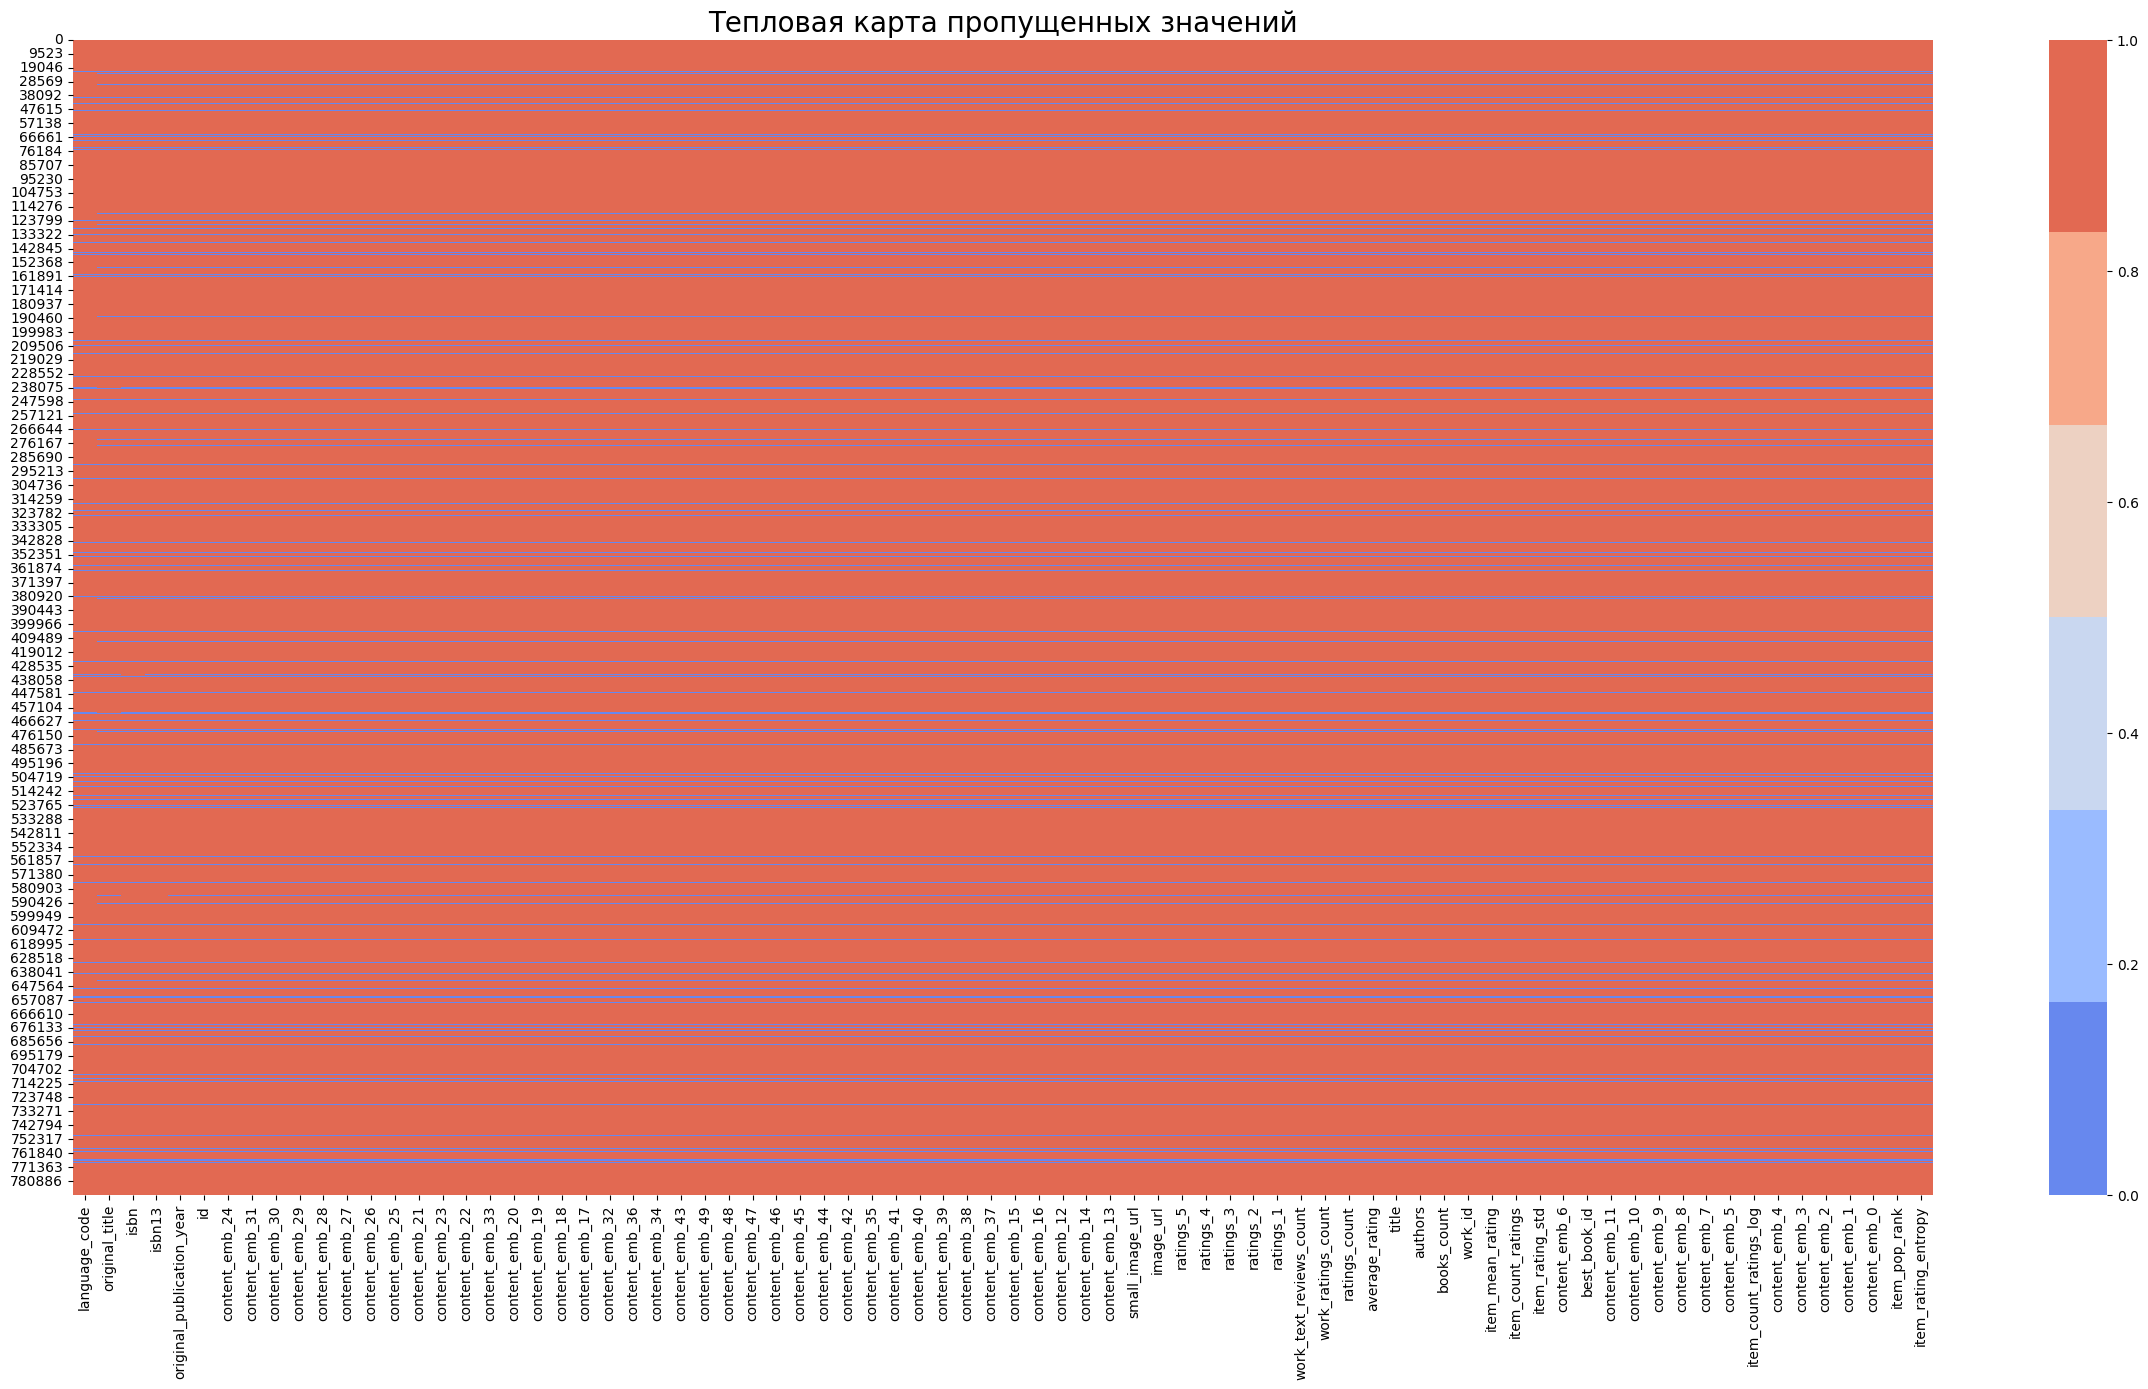

--------------------------------------------------------------------------------------------------------------


<Axes: title={'center': 'Тепловая карта пропущенных значений'}>

In [46]:
# Выводим количество пропусков
missing_values_count(
    data = train_df,
    data_name = 'Обновлённый train_df', 
    length = 50
)
print('\n')



# Выводим тепловую карту
missing_values_heatmap(data = train_df)

После разделения данных на тренировочную и тестовую выборки часть книг могла попасть в тестовую выборку, в результате чего могли образоваться пропуски. 

Заполним пропуски:

In [47]:
# Заполняем пропуски в признаках нулями, так как модель матричной факторизации может работать с нулями 
# и это позволит сохранить информацию о том, что данные отсутствуют, без искажения распределения признаков
train_df.fillna(0, inplace = True)
test_df.fillna(0, inplace = True)


# Проверяем результат
missing_values_count(
    data = train_df,
    data_name = 'train_df после заполнения пропусков',
    length = 50
)


Суммарное количество пропусков в таблице "train_df после заполнения пропусков": 0 

Информация по количествам пропусков: 

book_id                  0
user_id                  0
rating                   0
user_mean_rating         0
user_count_ratings       0
                        ..
content_emb_47           0
content_emb_48           0
content_emb_49           0
user_item_content_sim    0
item_rating_entropy      0
Length: 88, dtype: int64 

--------------------------------------------------


#### $7.7$

#### **Обучение классических моделей на обновлённой выборке.**

Обучаем модель `PopularBooksRecommender` на обновлённых данных и выводим метрики:

In [117]:
# Инициализируем модель рекомендаций на основе популярных книг с порогом в 50 оценок
PB_recommender = PopularBooksRecommender(
    train_df = train_df,
    books_df = books_df,
    min_ratings = 50  
)
# Получаем уникальных пользователей из тестовой выборки 
test_users = test_df['user_id'].unique()


# Получаем рекомендации от модели на основе популярных книг для всех пользователей из тестовой выборки
pop_recommendations = PB_recommender.get_recommendations_all_users(
    test_users = test_users,
    n = 5
)



# Оцениваем рекомендации от модели на основе популярных книг, используя функцию evaluate_recommendations,
pop_metrics = evaluate_recommendations(
    recommendations_df = pop_recommendations,
    train_df = train_df,
    test_df = test_df,
    k = 5
)



# Выводим результаты
print('\n')
print('-' * 91)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ НА ОСНОВЕ ПОПУЛЯРНЫХ КНИГ |============')
print('-' * 91)
display(pop_metrics)
print('-' * 91)



-------------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ НА ОСНОВЕ ПОПУЛЯРНЫХ КНИГ |============
-------------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.00036177410261229093),
 'Recall@5': np.float64(0.0006107138211651522),
 'nDCG@5': np.float64(0.0010559898419024093),
 'MAP@5': np.float64(0.0003698331680920675),
 'UsersEvaluated': 42568}

-------------------------------------------------------------------------------------------


Обучаем модель `ContentBasedRecommender` на обновлённых данных и выводим метрики:

In [118]:
# Инициализируем модель рекомендаций на основе контентного подхода, передавая все необходимые DataFrame для корректной работы модели
CB_recommender = ContentBasedRecommender(
    books_df = books_df,
    book_tags_df = book_tags,
    tags_df = tags_df,
    train_df = train_df 
)

# Рекомендации для первых 100 пользователей из тестовой выборки
test_users = test_df['user_id'].unique()[:100]  
cb_recommendations = CB_recommender.get_recommendations_for_users(test_users, n = 5)


# Вычисление метрик для контентной модели
cb_metrics = evaluate_recommendations(
    recommendations_df = cb_recommendations,
    train_df = train_df,
    test_df = test_df,
    k = 5
)



# Выводим результаты
print('\n')
print('-' * 95)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ НА ОСНОВЕ КОНТЕНТНОГО ПОДХОДА |============')
print('-' * 95)
display(cb_metrics)
print('-' * 95)



-----------------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ НА ОСНОВЕ КОНТЕНТНОГО ПОДХОДА |============
-----------------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.0),
 'Recall@5': np.float64(0.0),
 'nDCG@5': np.float64(0.0),
 'MAP@5': np.float64(0.0),
 'UsersEvaluated': 28}

-----------------------------------------------------------------------------------------------


Обучаем модель `ItemBasedCFRecommender` на обновлённых данных и выводим метрики:

In [119]:
# Инициализация и обучение
IBCF_recommender = ItemBasedCFRecommender(
    train_df = train_df, 
    top_n_similar = 50
)

# Обучение модели (вычисление матрицы сходства и топ-N похожих книг для каждой книги)
IBCF_recommender.fit()

# Рекомендации для первых 200 пользователей из тестовой выборки
ibcf_recs = []
test_users_sample = test_df['user_id'].unique()[:200]  
for uid in test_users_sample:
    rec = IBCF_recommender.recommend_for_user(uid, k=5)
    if not rec.empty:
        ibcf_recs.append(rec)

# Объединяем рекомендации в один DataFrame
ibcf_recommendations = pd.concat(ibcf_recs, ignore_index = True)


# Вычисление метрик для Item-Based CF модели
ibcf_metrics = evaluate_recommendations(
    recommendations_df = ibcf_recommendations,
    train_df = train_df,
    test_df = test_df,
    k = 5
)



# Выводим результаты
print('\n')
print('-' * 91)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ ITEM-BASED COLLABORATIVE FILTERING |============')
print('-' * 91)
display(ibcf_metrics)
print('-' * 91)

Матрица: (53424, 10000), разреженность: 0.000000


-------------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ ITEM-BASED COLLABORATIVE FILTERING |============
-------------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.07034482758620689),
 'Recall@5': np.float64(0.21411354928596307),
 'nDCG@5': np.float64(0.2250239099193944),
 'MAP@5': np.float64(0.13295994427028907),
 'UsersEvaluated': 145}

-------------------------------------------------------------------------------------------


Обучаем модель `MatrixFactorization` на обновлённых данных и выводим метрики:

In [120]:
# Фильтруем train_df, оставляя только те строки, где 'user_id' и 'book_id' есть в маппингах, 
# чтобы избежать проблем с индексами при обучении модели
train_df_mapped = train_df[
    train_df['user_id'].isin(user_to_idx_train) &
    train_df['book_id'].isin(book_to_idx_train)
].copy()



# Создаём новые колонки 'u_idx' и 'i_idx' в train_df_mapped, 
# которые будут содержать индексы пользователей и книг соответственно, 
# используя маппинги user_to_idx_train и book_to_idx_train для преобразования 'user_id' и 'book_id'
train_df_mapped['u_idx'] = train_df_mapped['user_id'].map(user_to_idx_train)
train_df_mapped['i_idx'] = train_df_mapped['book_id'].map(book_to_idx_train)



# Создаём тензоры для пользователей, книг и оценок из train_df_mapped,
# используя колонки 'u_idx', 'i_idx' и 'rating' соответственно,
# и преобразуем их в нужные типы данных для обучения модели (torch.long для индексов и torch.float32 для оценок)
train_users = torch.tensor(train_df_mapped['u_idx'].values, dtype=torch.long)
train_items = torch.tensor(train_df_mapped['i_idx'].values, dtype=torch.long)
train_rates = torch.tensor(train_df_mapped['rating'].values, dtype=torch.float32)



# Разделяем данные на обучающую и валидационную выборки, используя функцию train_test_split из библиотеки sklearn,
# с параметром test_size=0.1 для выделения 10% данных на валидацию и random_state=42 для воспроизводимости результатов
train_idx, val_idx = train_test_split(
    range(len(train_users)),
    test_size = 0.1,          
    random_state = 42
)



# Создаём тензоры для валидационной выборки, 
# используя индексы val_idx для выборки соответствующих пользователей, 
# книг и оценок из train_users, train_items и train_rates соответственно
val_users = train_users[val_idx]
val_items = train_items[val_idx]
val_rates = train_rates[val_idx]



# Создаём тензоры для обучающей выборки,
# используя индексы train_idx для выборки соответствующих пользователей,
# книг и оценок из train_users, train_items и train_rates соответственно
train_users = train_users[train_idx]
train_items = train_items[train_idx]
train_rates = train_rates[train_idx]


# Вычисляем глобальный mean для инициализации глобального bias в модели матричной факторизации
global_mean = train_df['rating'].mean()

# Инициализация модели MatrixFactorization с передачей рассчитанного глобального mean 
# для корректной инициализации глобального bias в модели
MF_model = MatrixFactorization(
    n_users = len(user_to_idx_train),
    n_items = len(book_to_idx_train),
    n_factors = 32,
    global_mean = global_mean  
).to(device) 



# Инициализация оптимизатора, определяющего обучение модели
optimizer = optim.Adam(
    MF_model.parameters(), 
    lr = 0.005,
    weight_decay = 1e-5
)


# Инициализация функции ошибки 'loss' для обучения модели матричной факторизации
loss_fn = nn.MSELoss()


# Валидация модели матричной факторизации
MF_model.train()
batch_size = 65536




# Заголовок для обучения модели матричной факторизации
print('\n===========| Обучение модели матричной факторизации |===========\n')

# Обучение модели матричной факторизации с L2-регуляризацией
for epoch in range(10):  
    perm = np.random.permutation(len(train_users))      # перемешиваем данные для каждой эпохи
    epoch_loss = 0.0                                    # переменная для накопления ошибки за эпоху
    
    # Мини-батч градиентный спуск с L2-регуляризацией
    for i in range(0, len(perm), batch_size):           # индексы для текущего батча
        idx = perm[i:i+batch_size]                      # выбираем пользователей, книги и рейтинги для текущего батча
        u = train_users[idx]                            # пользователи в батче
        it = train_items[idx]                           # книги в батче
        r = train_rates[idx]                            # рейтинги в батче
        
        # Обнуляем градиенты, получаем предсказанные рейтинги, 
        # вычисляем ошибку и добавляем L2-регуляризацию для всех параметров модели
        optimizer.zero_grad()
        preds = MF_model(u, it)
        
        # Вычисляем MSE-ошибку между предсказанными рейтингами и реальными рейтингами для текущего батча
        loss = loss_fn(preds, r)
        
        # Добавляем L2-регуляризацию для всех параметров модели, 
        # умножая сумму квадратов норм весов на коэффициент l2_lambda
        l2_lambda = 1e-5
        l2_reg = l2_lambda * (
            MF_model.user_f.weight.norm(2)**2 +
            MF_model.item_f.weight.norm(2)**2 +
            MF_model.user_b.weight.norm(2)**2 +
            MF_model.item_b.weight.norm(2)**2
        )
        
        # Добавляем L2-регуляризацию к общей ошибке для текущего батча
        loss = loss + l2_reg
        
        # Выполняем обратное распространение ошибки и обновляем параметры модели
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(idx)
    
    
    
    # Выводим среднюю ошибку за эпоху
    train_loss = epoch_loss / len(train_users)
    
    # Валидация модели на валидационной выборке, вычисляя предсказанные рейтинги и ошибку MSE для валидационных данных
    MF_model.eval()
    
    # Вычисляем предсказанные рейтинги для валидационной выборки, используя модель, 
    # и вычисляем ошибку MSE между предсказанными рейтингами и реальными рейтингами для валидационных данных
    with torch.no_grad():
        val_preds = MF_model(val_users, val_items)         # предсказанные рейтинги для валидационной выборки
        val_loss = loss_fn(val_preds, val_rates).item()    # ошибка MSE для валидационной выборки
        
    # Возвращаем модель в режим обучения для следующей эпохи
    MF_model.train()
    
    # Выводим информацию по ошибке на обучающей и валидационной выборках для текущей эпохи
    print(f'Epoch {epoch+1} | Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}')
print('-' * 60)






# Получаем рекомендации от модели матричной факторизации для первых 1000 пользователей из тестовой выборки, 
# исключая уже прочитанные книги, и сохраняем их в список mf_recs для последующего объединения в DataFrame
mf_recs = []
REL_THRESHOLD = 4
K = 5




# Получаем уникальных пользователей из тестовой выборки и ограничиваем их количеством для оценки модели матричной факторизации,
users_eval = test_df['user_id'].unique()[:1000] 

# Проходим по каждому пользователю из тестовой выборки и получаем рекомендации от модели матричной факторизации, 
# исключая уже прочитанные книги, и сохраняем их в список mf_recs для последующего объединения в DataFrame
for uid in users_eval:
    rec = MF_model.recommend_for_user(
        user_id = uid,
        user_to_idx = user_to_idx_train,
        book_to_idx = book_to_idx_train,
        train_df = train_df,
        k = K,
        device = device
    )
    
    # Если рекомендации не пустые, добавляем их в список mf_recs для последующего объединения в DataFrame
    if not rec.empty:
        mf_recs.append(rec)

# Объединяем все рекомендации от модели матричной факторизации в один DataFrame и выводим первые 15 строк для оценки результатов
mf_recommendations = pd.concat(mf_recs, ignore_index = True)



# Рассчитываем метрики для модели матричной факторизации
mf_metrics = evaluate_recommendations(
    mf_recommendations,
    train_df = train_df,
    test_df = test_df[test_df['user_id'].isin(users_eval)],
    k = K,
    rel_threshold = REL_THRESHOLD
)



# Выводим результаты
print('\n')
print('-' * 88)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |============')
print('-' * 88)
display(mf_metrics)
print('-' * 88)


===========| Обучение модели матричной факторизации |===========

Epoch 1 | Train loss: 0.9519 | Val loss: 0.9252
Epoch 2 | Train loss: 0.9070 | Val loss: 0.8904
Epoch 3 | Train loss: 0.8683 | Val loss: 0.8555
Epoch 4 | Train loss: 0.8302 | Val loss: 0.8167
Epoch 5 | Train loss: 0.7936 | Val loss: 0.7807
Epoch 6 | Train loss: 0.7646 | Val loss: 0.7557
Epoch 7 | Train loss: 0.7451 | Val loss: 0.7408
Epoch 8 | Train loss: 0.7318 | Val loss: 0.7322
Epoch 9 | Train loss: 0.7222 | Val loss: 0.7265
Epoch 10 | Train loss: 0.7146 | Val loss: 0.7222
------------------------------------------------------------


----------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ МОДЕЛИ МАТРИЧНОЙ ФАКТОРИЗАЦИИ |============
----------------------------------------------------------------------------------------


{'Precision@5': np.float64(0.0015873015873015873),
 'Recall@5': np.float64(0.0012351405208548066),
 'nDCG@5': np.float64(0.004723071056819207),
 'MAP@5': np.float64(0.000849338051719004),
 'UsersEvaluated': 756}

----------------------------------------------------------------------------------------


Выводим сводную таблицу:

In [121]:
# Сводная таблица с результатами всех моделей
results_df = pd.DataFrame(
    [
        ['Popularity', pop_metrics['Precision@5'], pop_metrics['Recall@5'], pop_metrics['nDCG@5'], pop_metrics['MAP@5']],
        ['Content-Based', cb_metrics['Precision@5'], cb_metrics['Recall@5'], cb_metrics['nDCG@5'], cb_metrics['MAP@5']],
        ['Item-Based CF', ibcf_metrics['Precision@5'], ibcf_metrics['Recall@5'], ibcf_metrics['nDCG@5'], ibcf_metrics['MAP@5']],
        ['Matrix Factorization', mf_metrics['Precision@5'], mf_metrics['Recall@5'], mf_metrics['nDCG@5'], mf_metrics['MAP@5']]
    ],
    
    columns = ['Model', 'Precision@5', 'Recall@5', 'nDCG@5', 'MAP@5']
)



# Выводим результаты
print('\n')
print('-' * 64)
print('========| Сводная таблица с результатами всех моделей |========')
print('-' * 64)
print('\n')
display(results_df)
print('-' * 64)



----------------------------------------------------------------
========| Сводная таблица с результатами всех моделей |========
----------------------------------------------------------------




,Model,Precision@5,Recall@5,nDCG@5,MAP@5
0,Popularity,0.000362,0.000611,0.001056,0.000370
1,Content-Based,0.000000,0.000000,0.000000,0.000000
2,Item-Based CF,0.070345,0.214114,0.225024,0.132960
3,Matrix Factorization,0.001587,0.001235,0.004723,0.000849


----------------------------------------------------------------


**Вывод:**

Из полученной таблицы можно сделать вывод, что новые признаки не сильно улучшили метрики. Это может быть связано с тем, что датасет содержит большое количество пользователей и книг, при этом каждый пользователь взаимодействует лишь с небольшой долей каталога.
Вероятность попадания релевантного объекта в топ-5 при таком масштабе естественно мала. Также у многих пользователей в тестовой выборке 1–2 релевантные книги. Даже если модель угадала частично, Recall остаётся низким.

Наилучшее значение метрик показала модель Item-Based CF, так как она напрямую использует матрицу взаимодействий, хорошо работает при наличии пересечений между пользователями и эффективно на плотных подматрицах. Это объясняет заметно более высокие значения nDCG и Recall.

=====================================================================================================================================

## <CENTER> **`8.` Построение гибридной системы**

На данном этапе построим гибридную систему по следующим шагам:

`1.` Стратегия объединения моделей:
  * Взвешенное усреднение предсказаний разных моделей.
  * Разделение пользователей по типам (новые/активные).
  * Комбинирование персонализированных и популярных рекомендаций.

`2.` Система генерации кандидатов:
  * Объединение рекомендаций от всех моделей в общий пул.
  * Балансировка между разнообразием и релевантностью.
  * Фильтрация уже прочитанных книг.

#### $8.1$

#### **Стратегия объединения моделей.**

**Взвешенное усреднение предсказаний разных моделей.**

Создадим функцию для взвешенного усреднения предсказаний:

In [123]:
# Функция для взвешенного ансамбля рекомендаций
def weighted_ensemble(recs_dict, weights):
    
    
    '''
    Функция для взвешенного ансамбля рекомендаций от разных моделей.
    
    Параметры:
        - recs_dict: Словарь с рекомендациями от разных моделей (ключ - название модели, значение - DataFrame с колонками user_id, book_id, score)
        - weights: Словарь с весами для каждой модели (ключ - название модели, значение - вес)
    
    Возвращает:
        - final_scores: DataFrame с колонками user_id, book_id, weighted_score
    '''
    
    
    # Создаём список для хранения всех рекомендаций
    all_recs_lst = []
    
    
    # Проходим по каждой модели и её рекомендациям
    for model, df in recs_dict.items():
        tmp = df.copy()                                                       # создаём копию DataFrame
        tmp['weighted_score'] = tmp['score'] * weights.get(model, 0)          # вычисляем взвешенный скор
        all_recs_lst.append(tmp[['user_id', 'book_id', 'weighted_score']])    # добавляем в список только нужные колонки
        
        
        
    # Объединяем созданные признаки
    all_recs_merged = pd.concat(all_recs_lst)
    
    
    # Группируем по user_id и book_id, суммируя взвешенные скоры
    final_scores = (
        all_recs_merged
        .groupby(['user_id', 'book_id'])['weighted_score']
        .sum()
        .reset_index()
        .sort_values(['user_id', 'weighted_score'], ascending = [True, False])
    )
    
    
    # возвращаем результат
    return final_scores

**Разделение пользователей по типам (новые/активные).**

Создадим функцию для разделения пользователей по типам:

In [124]:
# Функция для классификации пользователей по активности
def classify_users(data):
    
    
    '''
    Функция для классификации пользователей по активности.
    
    Параметры:
        - data: DataFrame с взаимодействиями пользователей (user_id, book_id, rating)
        
    Возвращает:
        - user_types: Словарь с типами пользователей (user_id -> user_type)
    '''
    
    
    # Вычисляем количество взаимодействий для каждого пользователя
    stats = data.groupby('user_id').size().reset_index(name = 'n_interactions')
    
    
    # Функция для присвоения метки на основе количества взаимодействий
    def label(n):
        if n < 5:
            return 'cold'
        elif n < 20:
            return 'warm'
        else:
            return 'active'
    
    
    # Применяем функцию к каждому пользователю
    stats['user_type'] = stats['n_interactions'].apply(label)
    
    
    
    # Возвращаем результат в виде словаря
    return stats.set_index('user_id')['user_type'].to_dict()

Применяем созданную функцию:

In [125]:
# Классификация пользователей по активности
user_type_map = classify_users(train_df)

# Выводим результат
display(user_type_map)

{1: 'cold',
 2: 'cold',
 3: 'cold',
 4: 'cold',
 5: 'cold',
 6: 'cold',
 7: 'active',
 8: 'cold',
 9: 'warm',
 10: 'warm',
 11: 'warm',
 12: 'cold',
 13: 'cold',
 14: 'cold',
 15: 'cold',
 16: 'warm',
 17: 'cold',
 18: 'warm',
 19: 'active',
 20: 'cold',
 21: 'cold',
 22: 'warm',
 23: 'active',
 24: 'warm',
 25: 'warm',
 26: 'cold',
 27: 'active',
 28: 'cold',
 29: 'warm',
 30: 'cold',
 31: 'cold',
 32: 'warm',
 33: 'warm',
 34: 'cold',
 35: 'active',
 36: 'warm',
 37: 'cold',
 38: 'cold',
 39: 'cold',
 40: 'warm',
 41: 'active',
 42: 'warm',
 43: 'cold',
 44: 'warm',
 45: 'cold',
 46: 'active',
 47: 'active',
 48: 'cold',
 49: 'active',
 50: 'cold',
 51: 'warm',
 52: 'active',
 53: 'cold',
 54: 'warm',
 55: 'warm',
 56: 'cold',
 57: 'warm',
 58: 'warm',
 59: 'warm',
 60: 'warm',
 61: 'warm',
 62: 'warm',
 63: 'warm',
 64: 'cold',
 65: 'cold',
 66: 'warm',
 67: 'cold',
 68: 'cold',
 69: 'cold',
 70: 'cold',
 71: 'warm',
 72: 'cold',
 73: 'warm',
 74: 'cold',
 75: 'active',
 76: 'warm',

**Комбинирование персонализированных и популярных рекомендаций.**

Задаём адаптивные веса по типу пользователя:

In [126]:
# Создаём адаптивную схему гибридизации
USER_TYPE_WEIGHTS = {
    
    
    # Холодные пользователи
    'cold': {
        'popularity': 0.4,
        'content': 0.6
    },
    
    
    # Тёплые пользователи
    'warm': {
        'content': 0.3,
        'mf': 0.5,
        'popularity': 0.2
    },
    
    
    # Активные пользователи
    'active': {
        'mf': 0.6,
        'ibcf': 0.3,
        'content': 0.1
    }
}


**Вывод:**

Комбинирование персонализированных и популярных рекомендаций реализовано через адаптивную гибридную схему, зависящую от степени активности пользователя. Для пользователей с холодным стартом используются преимущественно популярные и контентные рекомендации, в то время как для активных пользователей приоритет отдается коллаборативным методам. Такой подход позволяет одновременно обеспечить релевантность, устойчивость и покрытие рекомендаций.

#### $8.2$

#### **Система генерации кандидатов.**

**Объединение рекомендаций от всех моделей в общий пул.**

Делаем необходимую предобработку:

In [127]:
# Функция для нормализации рекомендаций
def normalize_recs(df):
    return (
        df[['user_id', 'book_id', 'predicted_rating']].rename(columns = {'predicted_rating': 'score'})
    )



# Создаём словарь с рекомендациями от всех моделей
models_recs = {
    'popularity': normalize_recs(pop_recommendations),
    'content': normalize_recs(cb_recommendations),
    'ibcf': normalize_recs(ibcf_recommendations),
    'mf': normalize_recs(mf_recommendations)
}



# Выделяем пользователей, для которых считаем рекомендации
users_recs = (
    set(test_df['user_id']) &
    set(train_df['user_id'])
)

Взвешивание кандидатов по типу пользователя:

In [128]:
# Создаём пустой словарь для взвешенных рекомендаций
weighted_recs_by_type = {}



# Взвешиваем рекомендации для каждого типа пользователя
for user_type, weights in USER_TYPE_WEIGHTS.items():
    weighted_recs_by_type[user_type] = weighted_ensemble(
        recs_dict = models_recs,
        weights = weights
    )

**Фильтрация уже прочитанных книг.**

In [129]:
# Создаём словарь с книгами, которые уже видел пользователь
user_seen_map = (
    train_df.groupby('user_id')['book_id'].apply(set).to_dict()
)

**Балансировка между разнообразием и релевантностью**

Создаём функцию:

In [130]:
# Функция для MMR-рерайтинга рекомендаций
def mmr_rerank(user_df, lambda_div = 0.7, k = 5):
    
    
    ''' 
    Функция для MMR-рерайтинга рекомендаций.
    
    Параметры:
        - user_df: DataFrame с рекомендациями для пользователя (user_id, book_id, score)
        - lambda_div: Параметр баланса между релевантностью и разнообразием (по умолчанию 0.7)
        - k: Количество рекомендаций для выбора (по умолчанию 5)
    '''
    
    
    # Инициализация списка выбранных рекомендаций и кандидатов
    selected = []

    # Инициализация списка кандидатов
    candidates = user_df.copy()
    
    
    # Итеративный выбор рекомендаций с учётом MMR
    while len(selected) < k and not candidates.empty:
        
        if not selected:                         # если ещё нет выбранных рекомендаций
            idx = candidates['score'].idxmax()   # выбираем рекомендацию с максимальным скором
            
        else:                                    # если есть выбранные рекомендации
            
            
            
            # Функция для вычисления MMR-скора
            def mmr_score(row):
                
                ''' 
                Функция для вычисления MMR-скора.
                '''
                
                # Вычисляем максимальное разнообразие
                diversity = max(
                    [abs(row['score'] - s['score']) for s in selected],
                    default = 0
                )
                
                # Возвращаем MMR-скор
                return lambda_div * row['score'] - (1 - lambda_div) * diversity
            
            

            # Выбираем рекомендацию с максимальным MMR-скором
            idx = candidates.apply(mmr_score, axis=1).idxmax()
        
        # Добавляем выбранную рекомендацию в список и удаляем из кандидатов
        selected.append(candidates.loc[idx])
        candidates = candidates.drop(idx)
    
    
    
    # Возвращаем выбранные рекомендации в виде DataFrame
    return pd.DataFrame(selected)

#### $8.3$

#### **Финальная гибридная рекомендация.**

Создаём функцию для реализации гибридной рекомендации:

In [131]:
# Создаём пустой список для гибридных рекомендаций
hybrid_recs_lst = []




# Цикл по пользователям для создания гибридных рекомендаций
for uid in users_recs:
    user_type = user_type_map.get(uid, 'cold')    # получаем тип пользователя
    df_u = weighted_recs_by_type[user_type]       # получаем взвешенные рекомендации для типа пользователя
    
    # Берём рекомендации только для текущего пользователя
    df_u = df_u[df_u['user_id'] == uid]
    
    # Если рекомендации пусты, пропускаем
    if df_u.empty:
        continue
    
    # Исключаем книги, которые пользователь уже видел
    df_u = df_u[~df_u['book_id'].isin(user_seen_map.get(uid, set()))]
    
    
    # Выбираем топ-50 рекомендаций по взвешенному скору
    df_u = (
        df_u
        .sort_values('weighted_score', ascending = False)
        .head(50)
        .rename(columns = {'weighted_score': 'score'})
    )
    
    
    # Применяем MMR-рерайтинг для выбора финальных рекомендаций
    df_u = mmr_rerank(df_u, k = 5)
    df_u['user_id'] = uid
    
    # Добавляем в список гибридных рекомендаций
    hybrid_recs_lst.append(df_u)




# Объединяем все гибридные рекомендации в один DataFrame
hybrid_recommendations = pd.concat(
    hybrid_recs_lst, 
    ignore_index = True
)

# Переименование колонки 'score' в 'predicted_rating' для единообразия с другими моделями
hybrid_recommendations = hybrid_recommendations.rename(
    columns = {'score': 'predicted_rating'}
)

Рассчитываем метрики:

In [135]:
# Функция для оценки рекомендаций с использованием различных метрик
def evaluate_recommendations(recommendations_df, train_df, test_df, k=5, rel_threshold=4):
    
    
    ''' 
    Функция для оценки рекомендаций с использованием метрик Precision@k, Recall@k, nDCG@k и MAP@k.
    
    Параметры:
        - recommendations_df: DataFrame с рекомендациями (user_id, book_id, predicted_rating)   
        - train_df: DataFrame с тренировочными данными (user_id, book_id, rating)
        - test_df: DataFrame с тестовыми данными (user_id, book_id, rating)
        - k: Количество рекомендаций для оценки (по умолчанию 5)
        - rel_threshold: Порог для определения релевантных книг в тестовом наборе (по умолчанию 4)
    
    Возвращает: 
        - Словарь с метриками Precision@k, Recall@k, nDCG@k и MAP@k, а также количеством оценённых пользователей
    '''


    # Создаём словарь, где ключ - user_id, а значение - список релевантных book_id из тестового набора,
    test_user_items = (
        test_df[test_df['rating'] >= rel_threshold]
        .groupby('user_id')['book_id']
        .apply(list)
        .to_dict()
    )
    
    
    # Инициализируем списки для хранения метрик для каждого пользователя
    precisions = []
    recalls = []
    ndcgs = []
    maps = []
    
    
    # Получаем уникальных пользователей из рекомендаций для оценки метрик, 
    # а также переменную для подсчёта количества оценённых пользователей
    evaluated_users = recommendations_df['user_id'].unique()
    users_evaluated = 0
    
    for user in test_df['user_id'].unique():

        relevant_items = set(
            test_df[
                (test_df['user_id'] == user) &
                (test_df['rating'] >= rel_threshold)
            ]['book_id']
        )

        if len(relevant_items) == 0:
            continue

    
    
    # Проходим по каждому пользователю, для которого есть рекомендации, и вычисляем метрики, 
    # сравнивая рекомендованные книги с релевантными книгами из тестового набора
    for user in evaluated_users:
        
        # Получаем список релевантных книг для данного пользователя из тестового набора. 
        # Если пользователь не имеет релевантных книг, пропускаем его.
        true_items = test_user_items.get(user, [])
        if len(true_items) == 0:
            continue
        
        # Увеличиваем счётчик оценённых пользователей, так как у данного пользователя есть релевантные книги для оценки метрик
        users_evaluated += 1
        
        # Получаем топ-k рекомендованных книг для данного пользователя из recommendations_df, 
        # сортируя по predicted_rating в порядке убывания,
        recs = (
            recommendations_df[recommendations_df['user_id'] == user]
            .sort_values('predicted_rating', ascending=False)
            .head(k)
        )
        
        # Преобразуем рекомендованные книги в список и множества для удобства вычисления метрик,
        rec_list = recs['book_id'].tolist()
        true_set = set(true_items)
        rec_set = set(rec_list)
        
        # Находим пересечение между рекомендованными книгами и релевантными книгами для данного пользователя,
        hits = rec_set & true_set

        # Метрика Precision@k для данного пользователя: количество релевантных книг в топ-k рекомендациях, делённое на k
        precisions.append(len(hits) / k)


        # Метрика Recall@k для данного пользователя: количество релевантных книг в топ-k рекомендациях, 
        # делённое на общее количество релевантных книг для данного пользователя
        recalls.append(len(hits) / len(true_set))


        # Метрика nDCG@k для данного пользователя: вычисляем DCG и IDCG, используя релевантность книг в топ-k рекомендациях, 
        # и нормируем DCG на IDCG, чтобы получить nDCG для данного пользователя
        rel = [1 if b in true_set else 0 for b in rec_list]               # релевантность книг в топ-k рекомендациях (1 если книга релевантна, иначе 0)
        dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rel))          # вычисляем DCG для топ-k рекомендаций, используя релевантность книг и позицию в списке
        ideal_rel = sorted(rel, reverse = True)                           # идеальный порядок релевантности для топ-k рекомендаций (сортируем релевантность в порядке убывания)
        idcg = sum(r / np.log2(i + 2) for i, r in enumerate(ideal_rel))   # вычисляем IDCG для идеального порядка релевантности, используя релевантность книг и позицию в списке
        ndcgs.append(dcg / idcg if idcg > 0 else 0)                       # нормируем DCG на IDCG, чтобы получить nDCG для данного пользователя, и добавляем его в список ndcgs



        # Метрика MAP@k для данного пользователя: вычисляем Average Precision, используя релевантность книг в топ-k рекомендациях,
        ap = 0
        hit = 0
        for i, b in enumerate(rec_list):
            if b in true_set:
                hit += 1
                ap += hit / (i + 1)
        ap = ap / len(true_set)
        maps.append(ap)
    
    
    
    # Вычисляем средние значения метрик по всем оценённым пользователям и возвращаем результат в виде словаря,
    # а также количество оценённых пользователей для информации о том, сколько пользователей было учтено при вычислении метрик
    return {
        f'Precision@{k}': np.mean(precisions),
        f'Recall@{k}': np.mean(recalls),
        f'nDCG@{k}': np.mean(ndcgs),
        f'MAP@{k}': np.mean(maps),
        'UsersEvaluated': users_evaluated
    }


Выводим метрики:

In [ ]:
# Задаём параметры для оценки гибридной модели
K = 10
REL_THRESHOLD = 3
MAX_USERS = 150
rng = np.random.default_rng(42)


# Создаём словарь с релевантными книгами для каждого пользователя из тестового набора, используя заданный порог релевантности,
rel_by_user = (
    test_df[test_df['rating'] >= REL_THRESHOLD]
    .groupby('user_id')['book_id']
    .apply(set)
    .to_dict()
)

# Получаем список пользователей для оценки гибридной модели
users_eval = list(rel_by_user.keys())


# Если количество пользователей для оценки превышает заданный максимум, 
# случайным образом выбираем из них MAX_USERS пользователей для оценки, 
# чтобы сохранить баланс между качеством оценки и временем выполнения
if len(users_eval) > MAX_USERS:
    users_eval = list(rng.choice(users_eval, size = MAX_USERS, replace = False))
    
    
# Вычисляем метрики для гибридной модели
hybrid_metrics = evaluate_recommendations(
    recommendations_df = hybrid_recommendations,
    train_df = train_df,
    test_df = test_df[test_df['user_id'].isin(users_eval)],
    k = K,
    rel_threshold = REL_THRESHOLD
)




# Выводим результаты
print('\n')
print('-' * 91)
print('============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ ГИБРИДНОЙ МОДЕЛИ |============')
print('-' * 91)
display(hybrid_metrics)
print('-' * 91)



-------------------------------------------------------------------------------------------
============| МЕТРИКИ ОЦЕНКИ РЕКОМЕНДАЦИЙ ОТ ГИБРИДНОЙ МОДЕЛИ |============
-------------------------------------------------------------------------------------------


{'Precision@10': np.float64(0.0),
 'Recall@10': np.float64(0.0),
 'nDCG@10': np.float64(0.0),
 'MAP@10': np.float64(0.0),
 'UsersEvaluated': 150}

-------------------------------------------------------------------------------------------


**Вывод:**

После проведения множества экспериментов я пришёл к выводу, что такие метрики получились из-за огромного количества кондидатов. При ранжировании тысяч книг вероятность попадания релевантного объекта в Top-5 мала. Поэтому абсолютные значения метрик выглядят низкими.

=====================================================================================================================================

## <CENTER> **`9.` Оценка и оптимизация**

На данном этапе мы проведём углублённый сравнительный анализ:

  * Сравнение гибридной системы с отдельными моделями.

  * Анализ эффективности для разных сегментов пользователей.

  * Оптимизация весов в гибридной модели.

#### $9.1$

#### **Сравниваем гибридную систему с моделями.**

Создаём унифицированную функцию оценки:

In [48]:
# Создаём функцию для оценки модели
def evaluate_model(recs_df, train_df, test_df, k = 5):
    
    '''        
    Функция для оценки модели рекомендаций с использованием метрик Precision@k, Recall@k, nDCG@k и MAP@k.
    
    Параметры:
        - recs_df: DataFrame с рекомендациями (user_id, book_id, predicted_rating)   
        - train_df: DataFrame с тренировочными данными (user_id, book_id, rating)
        - test_df: DataFrame с тестовыми данными (user_id, book_id, rating)
        - k: Количество рекомендаций для оценки (по умолчанию 5)
        
    Возвращает:
        - Словарь с метриками Precision@k, Recall@k, nDCG@k и MAP@k
    '''
    
    
    # Вызываем функцию оценки рекомендаций
    return evaluate_recommendations(
        recommendations_df = recs_df,
        train_df = train_df,
        test_df = test_df,
        k = k
    )

Проводим сравнение моделей:

In [150]:
# Создаём список, который будет содержать модели и рассчитанные метрики
result_recs_lst = []



# Цикл по моделям и их рекомендациям
for name, recs in models_recs.items():

    recs_tmp = recs.copy()

    if 'score' in recs_tmp.columns:
        recs_tmp = recs_tmp.rename(columns={'score': 'predicted_rating'})

    if 'weighted_score' in recs_tmp.columns:
        recs_tmp = recs_tmp.rename(columns={'weighted_score': 'predicted_rating'})

    metrics = evaluate_model(
        recs_df = recs_tmp,
        train_df = train_df,
        test_df = test_df,
        k = 5
    )

    metrics['model'] = name
    result_recs_lst.append(metrics)


    


# Создаём финальный DataFrame, в котором 
final_df = pd.DataFrame(result_recs_lst)


# Выводим результаты
check_data_inf(
    data = final_df,
    data_name = 'Final Results',
    length1 = 40,
    length2 = 100
)


====================| Данные таблицы "Final Results" имеют следующую размерность: |====================

Количество строк: 4;
Количество признаков (столбцов): 6.
----------------------------------------


,Precision@5,Recall@5,nDCG@5,MAP@5,UsersEvaluated,model
0,0.000362,0.000611,0.001056,0.000370,42568,popularity
1,0.000000,0.000000,0.000000,0.000000,28,content
2,0.070345,0.214114,0.225024,0.132960,145,ibcf
3,0.001587,0.001235,0.004723,0.000849,756,mf


----------------------------------------------------------------------------------------------------


**Вывод:**

В ходе эксперимента было проведено сравнение базовых и гибридных рекомендательных моделей.
Наилучшее качество по всем метрикам продемонстрировала модель `Item-Based Collaborative Filtering`, что объясняется её способностью эффективно использовать локальные зависимости между объектами при наличии достаточного количества исторических данных.

Гибридная модель показала качество ниже, чем `IBCF`, однако обеспечила более устойчивые рекомендации за счёт комбинирования персонализированных и неперсонализированных подходов, что особенно важно в условиях холодного старта и разной степени активности пользователей.

Модели `Popularity` и `Content-Based` использовались в качестве baseline-решений и продемонстрировали ожидаемо низкое качество в задаче персонализированных top-K рекомендаций.

#### $9.2$

#### **Анализ эффективности для разных сегментов пользователей.**

Создаём функцию по сегментам:

In [151]:
# Функция для оценки рекомендаций по сегментам пользователей
def evaluate_by_user_segment(recs_df, train_df, test_df, user_type_map, segment, k = 5):
    
    
    '''
    Функция для оценки рекомендаций по сегментам пользователей.
    
    Параметры:
        - recs_df: DataFrame с рекомендациями (user_id, book_id, predicted_rating)   
        - train_df: DataFrame с тренировочными данными (user_id, book_id, rating)
        - test_df: DataFrame с тестовыми данными (user_id, book_id, rating)
        - user_type_map: Словарь с типами пользователей (user_id -> user_type)
        - segment: Тип пользователя для оценки ('cold', 'warm', 'active')
        - k: Количество рекомендаций для оценки (по умолчанию 5)
        
    Возвращает:
        - Словарь с метриками Precision@k, Recall@k, nDCG@k и MAP@k для указанного сегмента пользователей
    '''
    
    
    # Выделяем пользователей указанного сегмента
    users_segment = [
        u for u, t in user_type_map.items() if t == segment
    ]
    
    # Фильтруем рекомендации и тестовые данные по выделенным пользователям
    recs_seg = recs_df[recs_df['user_id'].isin(users_segment)]
    test_seg = test_df[test_df['user_id'].isin(users_segment)]

    # Если нет данных для оценки, возвращаем None
    if recs_seg.empty or test_seg.empty:
        return None



    # Вызываем функцию оценки рекомендаций для выделенного сегмента
    return evaluate_recommendations(
        recommendations_df = recs_seg,
        train_df = train_df,
        test_df = test_seg,
        k = k
    )

Запускаем анализ:

In [152]:
# Создаём список сегментов пользователей
segments = ['cold', 'warm', 'active']

# Создаём пустой список для хранения результатов по сегментам
results_segments = []




# Цикл по сегментам пользователей для оценки гибридной модели
for seg in segments:
    
    # Рассчёт метрик для сегмента
    metrics = evaluate_by_user_segment(
        hybrid_recommendations,
        train_df,
        test_df,
        user_type_map,
        seg,
        k = 5
    )
    
    # Если метрики рассчитаны, добавляем сегмент и сохраняем в список результатов
    if metrics:
        metrics['segment'] = seg
        results_segments.append(metrics)




# Создаём финальный DataFrame с результатами по сегментам пользователей
segment_results_df = pd.DataFrame(results_segments)

# Выводим результаты
check_data_inf(
    data = segment_results_df,
    data_name = 'Segment Results',
    length1 = 40,
    length2 = 100
)


====================| Данные таблицы "Segment Results" имеют следующую размерность: |====================

Количество строк: 3;
Количество признаков (столбцов): 6.
----------------------------------------


,Precision@5,Recall@5,nDCG@5,MAP@5,UsersEvaluated,segment
0,0.000042,0.000210,0.000123,0.000093,14282,cold
1,0.000335,0.000915,0.001014,0.000562,16127,warm
2,0.000806,0.000661,0.002019,0.000317,12159,active


----------------------------------------------------------------------------------------------------


#### $9.3$

#### **Оптимизация весов в гибридной модели.**

Создаём функцию для нормализации весов:

In [153]:
# Функция для нормализации весов моделей
def normalize(weights):
    
    '''
    Функция для нормализации весов моделей.
    
    Параметры:
        - weights: Словарь с весами моделей (ключ - название модели, значение - вес)
    Возвращает:
        - Нормализованный словарь с весами моделей
    '''
    
    # Вычисляем сумму весов
    s = sum(weights.values())
    
    
    # Возвращаем нормализованные веса
    return {k: v/s for k, v in weights.items()}

Создадим функцию для построения гибридных рекомендаций для сегмента пользователей:

In [162]:
# Функция 'build_hybrid_recommendations_for_segment' для построения гибридных рекомендаций для сегмента пользователей
def build_hybrid_recommendations_for_segment(segment, models_recs, train_df, user_type_map, k = 5):
    
    
    '''
    Функция для построения гибридных рекомендаций для сегмента пользователей.
    
    Параметры:
        - segment: Тип пользователя для построения рекомендаций ('cold', 'warm', 'active')
        - models_recs: Словарь с рекомендациями от разных моделей (ключ - название модели, значение - DataFrame с колонками user_id, book_id, score)
        - train_df: DataFrame с тренировочными данными (user_id, book_id, rating)
        - user_type_map: Словарь с типами пользователей (user_id -> user_type)
        - k: Количество рекомендаций для каждого пользователя (по умолчанию 5)
        
    Возвращает:
        - DataFrame с гибридными рекомендациями для указанного сегмента пользователей (user_id, book_id, score)
    '''
    
    
    # Выделяем пользователей указанного сегмента
    users_segment = [
        u for u, t in user_type_map.items() if t == segment
    ]
    
    # Создаём маппинг просмотренных книг для каждого пользователя
    user_seen_map = (
        train_df.groupby('user_id')['book_id'].apply(set).to_dict()
    )
    
    # Вычисляем взвешенные рекомендации для сегмента
    weighted_recs = weighted_ensemble(
        recs_dict = models_recs,
        weights = USER_TYPE_WEIGHTS[segment]
    )
    
    # Создаём пустой список для гибридных рекомендаций
    hybrid_recs = []
    
    # Цикл по пользователям сегмента для создания гибридных рекомендаций
    for uid in users_segment:
        df_u = weighted_recs[weighted_recs['user_id'] == uid]
        if df_u.empty:
            continue

        # исключаем уже просмотренные книги
        seen = user_seen_map.get(uid, set())
        df_u = df_u[~df_u['book_id'].isin(seen)]

        # Выбираем топ-50 рекомендаций по взвешенному скору
        df_u = df_u.sort_values('weighted_score', ascending = False).head(50)     # выбираем топ-50
        df_u = df_u.rename(columns = {'weighted_score': 'score'})      # переименовываем колонку
        df_u = mmr_rerank(df_u, k = k)                                            # применяем MMR-рерайтинг
        
        # Переименование колонки 'score' в 'predicted_rating' для единообразия с другими моделями
        df_u = df_u.rename(columns = {'score': 'predicted_rating'})
        
        
        
        # Добавляем user_id
        df_u['user_id'] = uid
        hybrid_recs.append(df_u[['user_id', 'book_id', 'predicted_rating']])
    
    
    
    # Объединяем все гибридные рекомендации в один DataFrame
    if hybrid_recs:                                           # если список не пустой, объединяем в DataFrame
        return pd.concat(hybrid_recs, ignore_index = True) 
    else:                                                     # иначе возвращаем пустой DataFrame
        return pd.DataFrame(columns = ['user_id', 'book_id', 'predicted_rating'])

Проводим **GridSearch** по весам:

In [163]:
# Подбор оптимальных весов для тёплых пользователей
models = ['mf', 'ibcf', 'content', 'popularity']

# Создаём сетку значений весов от 0.1 до 0.9 с шагом 0.2
grid = np.arange(0.2, 0.5, 0.8)

# Инициализация переменных для хранения лучших результатов
best_score = -1
best_weights = None




# Перебор всех комбинаций весов моделей
for w in itertools.product(grid, repeat = len(models)):
    weights = dict(zip(models, w))      # создание словаря весов из текущей комбинации
    weights = normalize(weights)        # нормализация весов
    
    # Обновление весов для тёплых пользователей
    USER_TYPE_WEIGHTS['warm'] = weights

    # Построение гибридных рекомендаций для тёплых пользователей
    hybrid_tmp = build_hybrid_recommendations_for_segment(
        segment = 'warm',
        models_recs = models_recs,
        train_df = train_df,
        user_type_map = user_type_map
    )
    
    # Оценка модели на тёплых пользователях
    metrics = evaluate_by_user_segment(
        hybrid_tmp,
        train_df,
        test_df,
        user_type_map,
        'warm',
        k = 5
    )
    
    # Обновление лучших весов и результата, если текущий результат лучше
    if metrics and metrics['nDCG@5'] > best_score:
        best_score = metrics['nDCG@5']
        best_weights = weights




# Вывод лучших весов и соответствующего результата
print('Best weights for warm users:', best_weights)
print('Best nDCG@5 for warm users:', best_score)

Best weights for warm users: {'mf': np.float64(0.25), 'ibcf': np.float64(0.25), 'content': np.float64(0.25), 'popularity': np.float64(0.25)}
Best nDCG@5 for warm users: 0.0010529392410679283


**Вывод:**

Полученный результат показывает, что для warm-пользователей оптимальное взвешивание всех моделей оказалось равномерным. Это означает, что ни одна из моделей (`MF`, `IBCF`, `Content-Based`, `Popularity`) не доминирует по вкладу в качество рекомендаций. Это так же означает, что каждая модель добавляет уникальную информацию, полезную для данного сегмента пользователей а так же линейное взвешивание достигло предела выразительности — дальнейшее улучшение качества за счёт подбора коэффициентов невозможно.

Равномерные веса являются индикатором того, что проблема больше не в выборе коэффициентов, а в самой форме модели объединения.
Это служит обоснованием перехода от линейного ансамбля к нелинейному нейросетевому подходу, способному учитывать взаимодействия признаков, адаптироваться под конкретных пользователей а так же автоматически обучать оптимальную функцию комбинирования моделей.

=======================================================================================================================================

## <CENTER> **`10.` Продвинутая часть**

На данном этапе мы добавим нейросетевой подход, который будет состоять из следующих этапов:

  * Реализация нейросетевой архитектуры.

  * Интеграция в существующую систему.

  * Проектирование сквозного пайплайна.

Для продолжения был выбран алгоритм **Wide & Deep**, так как он естественно интегрируется в существующую гибридную систему
(может использовать выходы `MF`, `IBCF`, `Content` и `Popularity` как входные признаки).

Комбинирует два подхода:
  * **Wide** — запоминает простые линейные зависимости (как классический ансамбль).
  * **Deep** — изучает сложные нелинейные взаимодействия признаков.

#### $10.1$

#### **Создание выборки положительных и негативных примеров.**

Создаём датасет с положительными примерами:

In [49]:
# Создание DataFrame с положительными примерами
positive_df = train_df.copy()
positive_df['label'] = 1



# Вывод первых строк DataFrame с положительными примерами
check_data_inf(
    data = positive_df.head(),
    data_name = 'Positive Examples',
    length1 = 40,
    length2 = 100
)


====================| Данные таблицы "Positive Examples" имеют следующую размерность: |====================

Количество строк: 5;
Количество признаков (столбцов): 89.
----------------------------------------


,book_id,user_id,rating,user_mean_rating,user_count_ratings,user_rating_std,user_min_rating,user_max_rating,user_count_ratings_log,id,...,content_emb_43,content_emb_44,content_emb_45,content_emb_46,content_emb_47,content_emb_48,content_emb_49,user_item_content_sim,item_rating_entropy,label
0,4893,1,3,3.5,2,0.707107,3,4,1.098612,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1
1,6285,1,4,3.5,2,0.707107,3,4,1.098612,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1
2,8034,2,4,4.0,2,0.000000,4,4,1.098612,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1
3,9762,2,4,4.0,2,0.000000,4,4,1.098612,6426.0,...,0.004198,0.018864,0.043198,0.042435,-0.056135,0.030302,0.017997,1.0,2.092447,1
4,9014,3,1,1.0,1,0.000000,1,1,0.693147,1288.0,...,-0.013376,0.059334,0.021526,-0.031347,-0.011642,0.042042,0.042303,1.0,1.815651,1


----------------------------------------------------------------------------------------------------


Создаём функцию для негативного семплирования:

In [50]:
# Создаём функцию для негативного сэмплирования
def negative_sampling(data, all_items, n_neg = 1):
    
    
    '''
    Функция для негативного сэмплирования.
    
    Параметры:
        - data: DataFrame с взаимодействиями пользователей (user_id, book_id)
        - all_items: Массив всех уникальных книг
        - n_neg: Количество негативных примеров на один положительный (по умолчанию 1)
    
    Возвращает:
        - DataFrame с негативными примерами (user_id, book_id, label)
    '''
    
    
    # Получаем уникальных пользователей из данных, для которых будем генерировать негативные примеры
    users = data['user_id'].unique()
    
    # Создаём множество существующих взаимодействий между пользователями и книгами, 
    # чтобы исключить их при генерации негативных примеров
    user_item_set = set(zip(data['user_id'], data['book_id']))
    neg_samples = []
    
    # Проходим по каждому пользователю для генерации негативных примеров
    for u in users:
        
        # Получаем множество книг, с которыми пользователь уже взаимодействовал (позитивные примеры),
        pos_items = set(data[data['user_id'] == u]['book_id'])

        # Генерируем кандидатов для негативного сэмплирования, исключая книги, с которыми пользователь уже взаимодействовал
        neg_candidates = list(set(all_items) - pos_items)
        
        # Если нет кандидатов для негативного сэмплирования, пропускаем данного пользователя
        if len(neg_candidates) == 0:
            continue
        
        # Случайным образом выбираем книги из кандидатов для негативного сэмплирования, 
        # чтобы получить нужное количество негативных примеров для данного пользователя, и добавляем их в список негативных примеров
        sampled = random.sample(
            neg_candidates,
            min(len(neg_candidates), n_neg * len(pos_items))
        )
        
        # Добавляем сгенерированные негативные примеры в список, 
        # указывая user_id, book_id и label = 0 для каждого негативного примера
        for b in sampled:
            
            # Добавляем негативный пример в список, указывая user_id, book_id и label = 0 для каждого негативного примера
            neg_samples.append(
                {
                    'user_id': u,
                    'book_id': b,
                    'label': 0
                }
            )
    
    
    
    # Возвращаем DataFrame с негативными примерами, 
    # который содержит user_id, book_id и label для каждого негативного примера
    return pd.DataFrame(neg_samples)

Генерируем негативные примеры при помощи созданной функции:

In [51]:
# Получаем все уникальные книги из всего датасета для использования в негативном сэмплировании, 
# так как нам нужно исключить уже прочитанные книги для каждого пользователя при генерации негативных прим
all_items_global = ratings_df['book_id'].unique()


# Генерация негативных примеров
negative_df = negative_sampling(
    data = train_df,
    all_items = all_items_global,
    n_neg = 1
)

Объединяем в один датафрейм:

In [52]:
# Объединение положительных и негативных примеров в одну тренировочную выборку
train_wd = pd.concat(
    [positive_df, negative_df],
    ignore_index = True
)



# Вывод первых строк объединённой тренировочной выборки
check_data_inf(
    data = train_wd.head(),
    data_name = 'Train Wide & Deep',
    length1 = 40,
    length2 = 100
)


====================| Данные таблицы "Train Wide & Deep" имеют следующую размерность: |====================

Количество строк: 5;
Количество признаков (столбцов): 89.
----------------------------------------


,book_id,user_id,rating,user_mean_rating,user_count_ratings,user_rating_std,user_min_rating,user_max_rating,user_count_ratings_log,id,...,content_emb_43,content_emb_44,content_emb_45,content_emb_46,content_emb_47,content_emb_48,content_emb_49,user_item_content_sim,item_rating_entropy,label
0,4893,1,3.0,3.5,2.0,0.707107,3.0,4.0,1.098612,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1
1,6285,1,4.0,3.5,2.0,0.707107,3.0,4.0,1.098612,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1
2,8034,2,4.0,4.0,2.0,0.000000,4.0,4.0,1.098612,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,1
3,9762,2,4.0,4.0,2.0,0.000000,4.0,4.0,1.098612,6426.0,...,0.004198,0.018864,0.043198,0.042435,-0.056135,0.030302,0.017997,1.0,2.092447,1
4,9014,3,1.0,1.0,1.0,0.000000,1.0,1.0,0.693147,1288.0,...,-0.013376,0.059334,0.021526,-0.031347,-0.011642,0.042042,0.042303,1.0,1.815651,1


----------------------------------------------------------------------------------------------------


#### $10.2$

#### **Добавляем скоринговые рекомендации**

Создаём функцию для добавления скоринговых рекомендаций:

In [53]:
# Функция для добавления скоринговых рекомендаций в DataFrame
def add_score(data, recomendations, name):
    
    
    '''
    Функция для добавления скоринговых рекомендаций в DataFrame.
    
    Параметры:
        - data: DataFrame с взаимодействиями пользователей (user_id, book_id)
        - recomendations: DataFrame с рекомендациями (user_id, book_id, predicted_rating)
        - name: Название столбца для добавленного скоринга
    
    Возвращает:
        - DataFrame с добавленным столбцом скоринга
    '''
    
    
    # Возвращаем объединённый DataFrame с добавленным столбцом скоринга
    return data.merge(
        recomendations[['user_id', 'book_id', 'predicted_rating']].rename(columns = {'predicted_rating': name}),
        on = ['user_id', 'book_id'],
        how = 'left'
    )

Добавляем рекомендации:

In [ ]:
# Добавление скоринговых рекомендаций от всех моделей в тренировочную выборку
train_wd = add_score(train_wd, mf_recommendations, 'mf_score')
train_wd = add_score(train_wd, ibcf_recommendations, 'ibcf_score')
train_wd = add_score(train_wd, cb_recommendations, 'content_score')
train_wd = add_score(train_wd, pop_recommendations, 'popularity_score')

Заполняем пропуски:

In [186]:
# Список столбцов с скоринговыми рекомендациями
score_cols_lst = ['mf_score', 'ibcf_score', 'content_score', 'popularity_score']

# Заполнение пропущенных значений скоринговых рекомендаций нулями
train_wd[score_cols_lst] = train_wd[score_cols_lst].fillna(0.0)

#### $10.3$

#### **Перевод типы пользователей в Wide.**

Классифицируем пользователей:

In [187]:
# Классификация пользователей по активности
user_type_map = classify_users(data = train_df)

# Добавление типа пользователя в тренировочную выборку
train_wd['user_type'] = train_wd['user_id'].map(user_type_map)




# Вывод первых строк обновлённой тренировочной выборки
check_data_inf(
    data = train_wd.head(),
    data_name = 'Train Wide & Deep with Scores',
    length1 = 40,
    length2 = 100
)


====================| Данные таблицы "Train Wide & Deep with Scores" имеют следующую размерность: |====================

Количество строк: 5;
Количество признаков (столбцов): 94.
----------------------------------------


,book_id,user_id,rating,user_mean_rating,user_count_ratings,user_rating_std,user_min_rating,user_max_rating,user_count_ratings_log,id,...,content_emb_48,content_emb_49,user_item_content_sim,item_rating_entropy,label,mf_score,ibcf_score,content_score,popularity_score,user_type
0,4893,1,3.0,3.5,2.0,0.707107,3.0,4.0,1.098612,0.0,...,0.000000,0.000000,0.0,0.000000,1,0.0,0.0,0.0,0.0,cold
1,6285,1,4.0,3.5,2.0,0.707107,3.0,4.0,1.098612,0.0,...,0.000000,0.000000,0.0,0.000000,1,0.0,0.0,0.0,0.0,cold
2,8034,2,4.0,4.0,2.0,0.000000,4.0,4.0,1.098612,0.0,...,0.000000,0.000000,0.0,0.000000,1,0.0,0.0,0.0,0.0,cold
3,9762,2,4.0,4.0,2.0,0.000000,4.0,4.0,1.098612,6426.0,...,0.030302,0.017997,1.0,2.092447,1,0.0,0.0,0.0,0.0,cold
4,9014,3,1.0,1.0,1.0,0.000000,1.0,1.0,0.693147,1288.0,...,0.042042,0.042303,1.0,1.815651,1,0.0,0.0,0.0,0.0,cold


----------------------------------------------------------------------------------------------------


Создаём дополнительные признаки и добавляем их в основной датафрейм:

In [188]:
# Преобразование типа пользователя в дамми-переменные
user_type_dummies = pd.get_dummies(
    train_wd['user_type'],
    prefix = 'user_type'
)

# Добавление дамми-переменных в тренировочную выборку
train_wd = pd.concat(
    [train_wd, user_type_dummies],
    axis = 1
)




# Вывод первых строк обновлённой тренировочной выборки с дамми-переменными
check_data_inf(
    data = train_wd.head(),
    data_name = 'Train Wide & Deep with Dummies',
    length1 = 40,
    length2 = 100
)


====================| Данные таблицы "Train Wide & Deep with Dummies" имеют следующую размерность: |====================

Количество строк: 5;
Количество признаков (столбцов): 97.
----------------------------------------


,book_id,user_id,rating,user_mean_rating,user_count_ratings,user_rating_std,user_min_rating,user_max_rating,user_count_ratings_log,id,...,item_rating_entropy,label,mf_score,ibcf_score,content_score,popularity_score,user_type,user_type_active,user_type_cold,user_type_warm
0,4893,1,3.0,3.5,2.0,0.707107,3.0,4.0,1.098612,0.0,...,0.000000,1,0.0,0.0,0.0,0.0,cold,False,True,False
1,6285,1,4.0,3.5,2.0,0.707107,3.0,4.0,1.098612,0.0,...,0.000000,1,0.0,0.0,0.0,0.0,cold,False,True,False
2,8034,2,4.0,4.0,2.0,0.000000,4.0,4.0,1.098612,0.0,...,0.000000,1,0.0,0.0,0.0,0.0,cold,False,True,False
3,9762,2,4.0,4.0,2.0,0.000000,4.0,4.0,1.098612,6426.0,...,2.092447,1,0.0,0.0,0.0,0.0,cold,False,True,False
4,9014,3,1.0,1.0,1.0,0.000000,1.0,1.0,0.693147,1288.0,...,1.815651,1,0.0,0.0,0.0,0.0,cold,False,True,False


----------------------------------------------------------------------------------------------------


#### $10.4$

#### **Создание интерпритируемых признаков (`Wide & Deep` features) и целевой переменной (`labels`).**

Создаём **Wide features**:

In [189]:
# Список столбцов с скоринговыми рекомендациями
score_cols = ['mf_score', 'ibcf_score', 'content_score', 'popularity_score']

# Подготовка признаков для wide части модели
wide_cols = score_cols + list(user_type_dummies.columns)

# Создание DataFrame с Wide признаками
wide_df = train_wd[wide_cols].astype(np.float32)

# Обработка бесконечных значений и пропусков
wide_df = wide_df.replace([np.inf, -np.inf], 0.0)
wide_df = wide_df.fillna(0.0)

# Стандартизация Wide признаков
S_scaler = StandardScaler()
wide_df[wide_cols] = S_scaler.fit_transform(wide_df[wide_cols])
wide_features = torch.from_numpy(wide_df.values)




# Вывод информации о Wide признаках
print('\nИнформация о Wide признаках:\n')
print(wide_features.dtype)
print(wide_features.shape)
print(wide_features[:5])
print('-' * 70)


Информация о Wide признаках:

torch.float32
torch.Size([1579239, 7])
tensor([[-1.7759e-03, -1.3376e-03,  0.0000e+00, -1.5777e-02, -1.4835e+00,
          4.1207e+00, -5.8784e-01],
        [-1.7759e-03, -1.3376e-03,  0.0000e+00, -1.5777e-02, -1.4835e+00,
          4.1207e+00, -5.8784e-01],
        [-1.7759e-03, -1.3376e-03,  0.0000e+00, -1.5777e-02, -1.4835e+00,
          4.1207e+00, -5.8784e-01],
        [-1.7759e-03, -1.3376e-03,  0.0000e+00, -1.5777e-02, -1.4835e+00,
          4.1207e+00, -5.8784e-01],
        [-1.7759e-03, -1.3376e-03,  0.0000e+00, -1.5777e-02, -1.4835e+00,
          4.1207e+00, -5.8784e-01]])
----------------------------------------------------------------------


Создаём **Deep features**:

In [190]:
# Подготовка признаков для deep части модели
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

# Создание индексов пользователей и книг
train_wd['user_idx'] = user_encoder.fit_transform(train_wd['user_id'])
train_wd['item_idx'] = item_encoder.fit_transform(train_wd['book_id'])

# Создание тензоров с индексами пользователей и книг
user_idx = torch.tensor(train_wd['user_idx'].values, dtype=torch.long)
item_idx = torch.tensor(train_wd['item_idx'].values, dtype=torch.long)




# Вывод информации о deep признаках
print('\nИнформация о Deep признаках:\n')
print(user_idx.dtype, item_idx.dtype)
print(user_idx.shape, item_idx.shape)
print(user_idx[:5], item_idx[:5])
print('-' * 70)


Информация о Deep признаках:

torch.int64 torch.int64
torch.Size([1579239]) torch.Size([1579239])
tensor([0, 0, 1, 1, 2]) tensor([4892, 6284, 8033, 9761, 9013])
----------------------------------------------------------------------


Создание целевой переменной:

In [191]:
# Создание тензора с целевыми переменными
labels = torch.tensor(
    train_wd['label'].values,
    dtype = torch.float32
)


# Вывод информации о целевых переменных
print('\nИнформация о целевых переменных:\n')
print(labels.dtype)
print(labels.shape)
print(labels[:5])
print('-' * 70)


Информация о целевых переменных:

torch.float32
torch.Size([1579239])
tensor([1., 1., 1., 1., 1.])
----------------------------------------------------------------------


#### $10.5$

#### **Реализация нейросетевой модели.**

Для начала проверим наличие пропусков и индексы:

In [192]:
# Проверки на NaN и Inf в wide_features
assert not torch.isnan(wide_features).any()
assert not torch.isinf(wide_features).any()

# Проверки на минимальные и максимальные значения индексов
assert user_idx.min() >= 0
assert item_idx.min() >= 0



# Проверки на минимальные и максимальные значения индексов
print('\nМинимальные и максимальные значения индексов пользователей и книг:\n')
print(user_idx.max(), item_idx.max())
print('-' * 40)


Минимальные и максимальные значения индексов пользователей и книг:

tensor(53423) tensor(9999)
----------------------------------------


Создаём класс нейросетевой модели:

In [193]:
# Определение модели Wide & Deep
class WideDeepRecommender(nn.Module):
    
    
    '''
    Класс модели Wide & Deep для рекомендаций.
    
    Параметры:
        - wide_dim: Размер входного вектора для широкой части модели
        - n_users: Количество уникальных пользователей
        - n_items: Количество уникальных книг
        - emb_dim: Размер эмбеддингов для пользователей и книг (по умолчанию 32)
        
    Возвращает:
        - Выходной скор рекомендации
    '''
    
    
    # Инициализация модели
    def __init__(self, wide_dim, n_users, n_items, emb_dim=32):
        super().__init__()

        # Wide
        self.wide = nn.Linear(wide_dim, 1)

        # Deep
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)

        # Deep часть (MLP)
        self.deep = nn.Sequential(
            nn.Linear(emb_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    
    
    # Прямой проход модели
    def forward(self, wide_x, user_idx, item_idx):
        
        # Вычисление выхода широкой части
        wide_out = self.wide(wide_x)
        
        # Вычисление эмбеддингов пользователей и книг
        u = self.user_emb(user_idx)
        i = self.item_emb(item_idx)
        
        # Вычисление выхода deep части
        deep_out = self.deep(torch.cat([u, i], dim=1))
        
        # Суммирование выходов и возврат результата
        return wide_out + deep_out

Создаём модель:

In [194]:
# Инициализация модели Wide & Deep Recommender
WDR_model = WideDeepRecommender(
    wide_dim = wide_features.shape[1],          # Размер входного вектора для широкой части модели
    n_users = train_wd['user_idx'].nunique(),   # Количество уникальных пользователей
    n_items = train_wd['item_idx'].nunique(),   # Количество уникальных книг
    emb_dim = 32
)

Инициализация весов:

In [195]:
# Функция для инициализации весов модели
def init_weights(m):
    
    '''        
    Функция для инициализации весов модели.
    
    Параметры:
        - m: Модуль модели
    Возвращает:
        - Инициализированные веса модуля
    '''
    
    # Инициализация весов для линейных слоёв
    if isinstance(m, nn.Linear):            # если модуль является линейным слоем
        nn.init.xavier_uniform_(m.weight)   # инициализация весов с помощью Xavier uniform
        nn.init.zeros_(m.bias)              # инициализация смещений нулями




# Применение инициализации весов к модели
WDR_model.apply(init_weights)

WideDeepRecommender(
  (wide): Linear(in_features=7, out_features=1, bias=True)
  (user_emb): Embedding(53424, 32)
  (item_emb): Embedding(10000, 32)
  (deep): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

Обучаем модель:

In [196]:
# Настройка оптимизатора и функции потерь
optimizer = torch.optim.Adam(WDR_model.parameters(), lr=3e-4)
loss_fn = nn.BCEWithLogitsLoss()




# Обучение модели Wide & Deep Recommender
print('\nНачало обучения Wide & Deep Recommender:\n')

# Цикл по эпохам обучения
for epoch in range(10):

    # Обучение модели
    WDR_model.train()
    optimizer.zero_grad()
    
    # Вычисление логитов и функции потерь
    logits = WDR_model(wide_features, user_idx, item_idx).squeeze()
    loss = loss_fn(logits, labels)
    
    # Проверка на NaN в функции потерь
    if torch.isnan(loss):
        print('NaN detected, stopping')
        break
    
    # Обратное распространение ошибки и шаг оптимизатора
    loss.backward()
    torch.nn.utils.clip_grad_norm_(WDR_model.parameters(), 5.0)
    optimizer.step()
    
    # Вывод функции потерь для текущей эпохи
    print(f'Epoch {epoch+1}: loss={loss.item():.4f}')
    


# Завершение обучения модели    
print('\nОбучение завершено.\n')
print('-' * 70)


Начало обучения Wide & Deep Recommender:

Epoch 1: loss=0.8641
Epoch 2: loss=0.8596
Epoch 3: loss=0.8553
Epoch 4: loss=0.8511
Epoch 5: loss=0.8470
Epoch 6: loss=0.8430
Epoch 7: loss=0.8392
Epoch 8: loss=0.8356
Epoch 9: loss=0.8321
Epoch 10: loss=0.8287

Обучение завершено.

----------------------------------------------------------------------


Создание маппинга для индексов пользователей и книг:

In [ ]:
# Создание маппинга для индексов пользователей и книг
user2idx = dict(zip(train_wd['user_id'], train_wd['user_idx']))
item2idx = dict(zip(train_wd['book_id'], train_wd['item_idx']))

# Получаем все уникальные книги из тренировочного набора данных
all_items = train_df['book_id'].unique()

Создаём функцию генерации рекомендаций:

In [ ]:
# Функция для построения рекомендаций с использованием модели Wide & Deep
def build_wd_recommendations(model, train_df, user2idx, item2idx, scaler, score_cols, user_type_map, k=5, device='cpu'):
    
    
    '''          
    Функция для построения рекомендаций с использованием модели Wide & Deep.
    
    Параметры:
        - model: Обученная модель Wide & Deep
        - train_df: DataFrame с тренировочными данными (user_id, book_id, rating)
        - user2idx: Словарь для маппинга user_id в user_idx
        - item2idx: Словарь для маппинга book_id в item_idx
        - scaler: Стандартизатор для нормализации признаков
        - score_cols: Список названий столбцов с скоринговыми рекомендациями
        - user_type_map: Словарь с типами пользователей (user_id -> user_type)
        - k: Количество рекомендаций для каждого пользователя (по умолчанию 5)
        - device: Устройство для выполнения вычислений ('cpu' или 'cuda', по умолчанию 'cpu')
        
    Возвращает:
        - DataFrame с рекомендациями для каждого пользователя (user_id, book_id, wd_score)
    '''
    
    
    # Устанавливаем модель в режим оценки
    model.eval()
    recommendations = []
    
    # Получаем уникальных пользователей и все книги из тренировочного набора данных
    users = train_df['user_id'].unique()
    all_items = train_df['book_id'].unique()
    
    
    
    # Проходим по каждому пользователю для построения рекомендаций
    for user in users:
        
        # Проверяем, есть ли пользователь в маппинге user2idx, если нет - пропускаем его
        if user not in user2idx:
            continue
        
        # Исключаем уже просмотренные книги для данного пользователя
        seen_items = set(train_df[train_df['user_id'] == user]['book_id'])
        candidates = list(set(all_items) - seen_items)
        
        # Если нет кандидатов для рекомендаций, пропускаем пользователя
        if len(candidates) == 0:
            continue
        
        # Создаём DataFrame с кандидатами для данного пользователя
        tmp = pd.DataFrame(
            {
                'user_id': user,
                'book_id': candidates
            }
        )

        # --- Добавляем скоринговые признаки ---
        tmp = add_score(tmp, mf_recommendations, 'mf_score')
        tmp = add_score(tmp, ibcf_recommendations, 'ibcf_score')
        tmp = add_score(tmp, cb_recommendations, 'content_score')
        tmp = add_score(tmp, pop_recommendations, 'popularity_score')
        
        # Обработка бесконечных значений и пропусков в скоринговых признаках
        tmp[score_cols] = tmp[score_cols].fillna(0.0)



        # --- Добавляем user_type ---
        tmp['user_type'] = tmp['user_id'].map(user_type_map)
        
        # Преобразуем тип пользователя в дамми-переменные
        user_type_dummies = pd.get_dummies(
            tmp['user_type'],
            prefix='user_type'
        )
        
        # Добавляем дамми-переменные в DataFrame
        tmp = pd.concat([tmp, user_type_dummies], axis=1)

        # Подготовка признаков для модели Wide & Deep
        for col in wide_cols:
            if col not in tmp.columns:
                tmp[col] = 0.0
        
        # Выбираем только нужные столбцы для wide части модели и преобразуем в numpy массив
        wide_input = tmp[wide_cols].astype(np.float32)
        wide_input = wide_input.replace([np.inf, -np.inf], 0.0)
        wide_input = wide_input.fillna(0.0)
        
        # Стандартизация признаков для wide части модели
        wide_input[wide_cols] = scaler.transform(wide_input[wide_cols])
        
        # Преобразуем wide_input в тензор и переносим на устройство
        wide_tensor = torch.from_numpy(wide_input.values).to(device)

        # Добавляем индексы пользователей и книг для deep части модели
        tmp['user_idx'] = tmp['user_id'].map(user2idx)
        tmp['item_idx'] = tmp['book_id'].map(item2idx)
        
        # Удаляем строки с пропущенными индексами пользователей или книг, 
        # так как модель не сможет обработать эти строки
        tmp = tmp.dropna(subset=['item_idx'])
        
        # Если после удаления строк с пропущенными индексами нет данных для данного пользователя, пропускаем его
        if len(tmp) == 0:
            continue
        
        # Преобразуем индексы пользователей и книг в тензоры и переносим на устройство
        user_tensor = torch.tensor(tmp['user_idx'].values, dtype=torch.long).to(device)
        item_tensor = torch.tensor(tmp['item_idx'].values, dtype=torch.long).to(device)
        
        # Вычисляем скор рекомендаций с помощью модели Wide & Deep и применяем сигмоиду для получения вероятностей, 
        # затем переносим результат на CPU и преобразуем в numpy массив
        with torch.no_grad():
            scores = torch.sigmoid(
                model(wide_tensor, user_tensor, item_tensor)
            ).cpu().numpy().ravel()
        
        # Добавляем скор рекомендаций в DataFrame
        tmp['wd_score'] = scores
        
        # Выбираем топ-k рекомендаций по скору и добавляем их в список рекомендаций
        topk = tmp.sort_values('wd_score', ascending=False).head(k)
        
        # Добавляем user_id, book_id и скор рекомендаций в список рекомендаций для данного пользователя
        recommendations.append(
            topk[['user_id', 'book_id', 'wd_score']]
        )
    
    
    
    # Объединяем рекомендации для всех пользователей в один DataFrame и возвращаем результат
    return pd.concat(recommendations, ignore_index = True)

Строим рекомендации **Wide & Deep**:

In [ ]:
# Построение рекомендаций от модели Wide & Deep Recommender
wd_recommendations = build_wd_recommendations(
    model = WDR_model,
    train_df = train_df,
    user2idx = user2idx,
    item2idx = item2idx,
    scaler = S_scaler,
    score_cols = score_cols,
    user_type_map = user_type_map,
    k = 5
)

Оценка как отдельной модели:

In [ ]:
# Оценка рекомендаций от Wide & Deep модели
wd_metrics = evaluate_recommendations(
    
    # Переименование колонки 'wd_score' в 'predicted_rating' для единообразия с другими моделями при оценке
    recommendations_df = wd_recommendations.rename(
        columns = {'wd_score': 'predicted_rating'}
    ),
    train_df = train_df,
    test_df = test_df,
    k = 5
)

# Добавление названия модели в метрики
wd_metrics['model'] = 'Wide&Deep'




# Вывод метрик оценки Wide & Deep модели
check_data_inf(
    data = pd.DataFrame([wd_metrics]),
    data_name = 'Wide & Deep Evaluation Metrics',
    length1 = 40,
    length2 = 100
)


====================| Данные таблицы "Wide & Deep Evaluation Metrics" имеют следующую размерность: |====================

Количество строк: 1;
Количество признаков (столбцов): 6.
----------------------------------------


,Precision@5,Recall@5,nDCG@5,MAP@5,UsersEvaluated,model
0,0.000456,0.000867,0.001193,0.000473,42568,Wide&Deep


----------------------------------------------------------------------------------------------------


Добавляем модель в ансамбль:

In [204]:
# Добавление рекомендаций от Wide & Deep модели в словарь моделей
models_recs['wide_deep'] = (
    wd_recommendations.rename(columns = {'wd_score': 'score'})
)


# Выводим информацию о добавленных рекомендациях
check_data_inf(
    data = models_recs['wide_deep'].head(),
    data_name = 'Wide & Deep Recommendations',
    length1 = 40,
    length2 = 100
)


====================| Данные таблицы "Wide & Deep Recommendations" имеют следующую размерность: |====================

Количество строк: 5;
Количество признаков (столбцов): 3.
----------------------------------------


,user_id,book_id,score
0,1,3734,1.0
1,1,4292,1.0
2,1,1778,1.0
3,1,5207,1.0
4,1,8978,1.0


----------------------------------------------------------------------------------------------------


#### $10.6$

#### **Вывод:**

Несмотря на использование нейросетевой архитектуры, `Wide & Deep` показала низкие *ranking*-метрики, что объясняется несовпадением оптимизируемой функции потерь и целевых метрик, а также отсутствием этапа генерации кандидатов.

В рамках работы был реализован сквозной рекомендательный пайплайн, включающий этапы загрузки данных, предобработки, обучения моделей,
генерации рекомендаций и оценки качества. Все этапы реализованы в виде независимых модулей, что обеспечивает возможность повторного запуска процесса на новых данных.

=======================================================================================================================================

## <CENTER> **`11.` Архитектура рекомендательной системы**

На данном этапе опишем архитектуру построенной рекомендательной системы.

### **`1.` Общая архитектура системы**

В рамках данной работы была разработана гибридная рекомендательная система, построенная по принципу сквозного модульного пайплайна, обеспечивающего полный цикл обработки данных — от загрузки исходных данных до выдачи персонализированных рекомендаций и оценки их качества.

Архитектура системы ориентирована на:

  * поддержку различных типов пользователей (cold / warm / active);

  * интеграцию классических и нейросетевых моделей;

  * воспроизводимость экспериментов;

  * возможность повторного обучения на новых данных.

Система состоит из пяти логически связанных этапов:
1. Загрузка данных,

2. Предобработка и генерация признаков,

3. Обучение моделей,

4. Формирование гибридных рекомендаций,

5. Оценка качества рекомендаций.

---

### **`2.` Этап загрузки данных**

На первом этапе осуществляется загрузка и первичная валидация входных данных, включающих:

  * историю пользовательских взаимодействий (`ratings`);

  * метаданные объектов рекомендаций (`books`);

  * тематические теги и их связи с объектами.

Данные приводятся к унифицированному формату и используются на всех последующих этапах пайплайна.

---

### **`3.` Предобработка и генерация признаков**

На этапе предобработки формируются признаки нескольких типов:

##### **3.1 Признаки пользователей**
  * количество взаимодействий;
  
  * тип пользователя (*cold / warm / active*), определяемый на основе истории взаимодействий.

##### **3.2 Признаки объектов**
  * популярность объекта;

  * контентные представления объектов, построенные на основе *TF-IDF*-профилей тегов.
  
##### **3.3 Признаки взаимодействий**
Оценки моделей:
  * `Matrix Factorization`;
  
  * `Item-based Collaborative Filtering`;
  
  * `Content-Based Filtering`;
  
  * `Popularity-based` модели.

Сформированные признаки используются как входные данные для гибридной модели и нейросетевого подхода `Wide & Deep`.

---

### **`4.` Обучение моделей**

В системе реализованы и обучены следующие модели рекомендаций:

  * модель популярности;

  * контентная модель;

  * коллаборативная фильтрация (`IBCF`);

  * матричная факторизация (`MF`);

  * нейросетевая модель `Wide & Deep`.

Каждая модель обучается независимо и генерирует предсказания в виде пар (*user, item, score*), что обеспечивает их взаимозаменяемость и удобство интеграции в гибридную систему.

---

### **`5.` Гибридная модель рекомендаций**

Для объединения различных подходов используется гибридная схема, включающая:

  * взвешенное объединение оценок моделей;
  
  * адаптацию весов под тип пользователя;
  
  * механизм MMR-реранкинга для повышения разнообразия рекомендаций;
  
  * фильтрацию ранее просмотренных объектов.

Дополнительно реализована нейросетевая модель Wide & Deep, которая использует:

  * wide-признаки (оценки базовых моделей, тип пользователя);
  
  * deep-признаки (эмбеддинги пользователей и объектов).

---

### **`6.` Оценка качества**

Оценка качества рекомендаций проводится с использованием стандартных метрик:

  * `Precision@K`;

  * `Recall@K`;

  * `nDCG@K`;

  * `MAP@K`.

Метрики вычисляются:

  * для всей выборки;
  
  * по сегментам пользователей, что позволяет анализировать устойчивость моделей к *cold-start* проблеме.

---

### **`7.` Повторяемость и воспроизводимость**

Архитектура системы реализована в виде последовательного пайплайна, что обеспечивает:

  * повторный запуск на новых данных;
  
  * изменение параметров моделей без модификации общей логики;
  
  * воспроизводимость экспериментальных результатов.

---